In [1]:
import h5py
import numpy as np
import gvar as gv
import math
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma
import inspect
#import warnings
#warnings.filterwarnings('ignore', category=RuntimeWarning)

# ---------------------------------------------------------
# 1. Jackknife Statistics Helper
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    # Fallback for 0 or negative error
    if err <= 0:
        return f"{mean}"
        
    # Switch to scientific if very small/big
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        # Calculate exponent of the mean
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
        
    else:
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1))  # -1 gives us 2 sig figs instead of 1
        
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"


def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        # 1. Load the jackknifed parameter samples
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            # Read the dataset back into a numpy array
            fitted_params[key] = param_group[key][:]
            
        # 2. Load the chi-square per dof array
        chi2_dof_list = f["chi2_dof"][:]
        
    return fitted_params, chi2_dof_list


def print_latex_table(fitted_params, chi2_dof_list, PL, bmin, etamin, etamax):
    # Calculate jackknifed means and errors for all parameters
    res = {}
    for key in fitted_params:
        mean, err = Jackknife(fitted_params[key])
        res[key] = fmt_err(mean, err)
        
    mean_chi2, err_chi2 = Jackknife(chi2_dof_list)
    chi2_str = fmt_err(mean_chi2, err_chi2)

    # Group parameters by Amplitude
    # (Including 'f' since it's a shared parameter in your model)
    re_params = ['a_re', 'c_re', 'd_re', 'k1_re', 'k2_re', 'j_re', 'f']
    im_params = ['a_im', 'c_im', 'd_im', 'j_im', 'f']
    a12b_params = ['a_reA12B', 'c_reA12B', 'd_reA12B', 'j_reA12B', 'f']

    # Format values as comma-separated lists
    vals_re = ", ".join([res[p] for p in re_params])
    vals_im = ", ".join([res[p] for p in im_params])
    vals_a12b = ", ".join([res[p] for p in a12b_params])

    # LaTeX representations (Raw strings handle their own backslashes)
    eq_re = r"$\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$"
    eq_im = r"$\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$"
    eq_a12b = r"$\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$"

    names_re = r"$\{a, c, d, k_1, k_2, j, f\}$"
    names_im = r"$\{a, c, d, j, f\}$"
    names_a12b = r"$\{a, c, d, j, f\}$"

    # Construct Markdown string (Double backslashes used here to fix the escape sequence warnings)
    md = f"\n### Simultaneous Fit with common f: \n for PL={PL}, $b_{{min}} \\ge {bmin}$, $\\eta \\in [{etamin}, {etamax}]$\n\n $\\chi^2/\\text{{DoF}}$ = {chi2_str} (Global)\n\n"
    md += "| Amplitude | Model Expression | Params List | Fitted Values |\n"
    md += "| :--- | :--- | :--- | :--- |\n"
    md += f"| $\\text{{Re}}A_{{2B}}$ | {eq_re} | {names_re} | $[{vals_re}]$ |\n"
    md += f"| $\\text{{Im}}A_{{2B}}$ | {eq_im} | {names_im} | $[{vals_im}]$ |\n"
    md += f"| $\\text{{Re}}A_{{12B}}$ | {eq_a12b} | {names_a12b} | $[{vals_a12b}]$ |\n"

    # If running in Jupyter Notebook, render it nicely:
    try:
        from IPython.display import display, Markdown
        display(Markdown(md))
    except ImportError:
        # If running in a standard terminal, just print the markdown text
        print(md)


def plot_fourier_transforms_A2B_A12B(fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax, num_points=200):
    print_latex_table(fitted_params, chi2_dof_list, PL, bminfit, etamin, etamax)
    
    # Setup x-axis (avoid exactly 0 to prevent division by zero in Bessel/powers)
    x_vals = np.linspace(-1, 1, num_points)
    
    MassN = 0.6228
    lata = 0.11403
    massterm = MassN * (197 * 0.001 / lata)
    
    # 1. Extract parameters as NumPy arrays
    a_re = np.array(fitted_params['a_re'])
    c_re = np.array(fitted_params['c_re']) / (PL**2)
    d_re = 1.0 + np.array(fitted_params['d_re']) * b2  
    j_re = np.array(fitted_params['j_re'])

    a_im = np.array(fitted_params['a_im']) / PL
    c_im = np.array(fitted_params['c_im']) / (PL**2)
    d_im = 1.0 + np.array(fitted_params['d_im']) * b2
    j_im = np.array(fitted_params['j_im'])

    a_reA12B = -np.array(fitted_params['a_reA12B'])
    c_reA12B = np.array(fitted_params['c_reA12B']) / (PL**2)
    d_reA12B = 1.0 + np.array(fitted_params['d_reA12B']) * b2  
    j_reA12B = np.array(fitted_params['j_reA12B'])

    re_mean, re_err = [], []
    reA12B_mean, reA12B_err = [], []
    im_mean, im_err = [], []
    full_mean, full_err = [], []
    SiverseShift_mean, SiverseShift_err = [], []
    xSiverseShift_mean, xSiverseShift_err = [], []

    print("\nEvaluating Fourier transforms and applying Jackknife for Plotting...")
    
    # 3. Loop over each x value and apply your Jackknife function
    for x in x_vals:
        abs_x = np.abs(x)
        if abs_x == 0:  # Safeguard against zero in loop
            abs_x = 1e-12
            x = 1e-12

        # --- Evaluate Real Part ---
        cd_R = c_re / d_re
        term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
        term2_R = abs_x**(-0.5 + j_re)
        bessel_R = kv(0.5 - j_re, abs_x / np.sqrt(cd_R))
        
        re_evals_at_x = term1_R * term2_R * bessel_R
        m_re, e_re = Jackknife(re_evals_at_x)
        re_mean.append(m_re)
        re_err.append(e_re)

        # --- Evaluate Imaginary Part ---
        cd_I = c_im / d_im
        term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
        term2_I = x * abs_x**(-1.5 + j_im)
        bessel_I = kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)
        
        im_evals_at_x = term1_I * term2_I * bessel_I
        m_im, e_im = Jackknife(im_evals_at_x)
        im_mean.append(m_im)
        im_err.append(e_im)

        m_full, e_full = Jackknife(2*(re_evals_at_x-im_evals_at_x))
        full_mean.append(m_full)
        full_err.append(e_full)

        # --- Evaluate ReA12B Part ---
        cd_RA12B = c_reA12B / d_reA12B
        term1_RA12B = (2**(1 - j_reA12B) * a_reA12B * cd_RA12B**(-0.25 - j_reA12B/2) * d_reA12B**(-j_reA12B)) / gamma(j_reA12B)
        term2_RA12B = abs_x**(-0.5 + j_reA12B)
        bessel_RA12B = kv(0.5 - j_reA12B, abs_x / np.sqrt(cd_RA12B))
        
        reA12B_evals_at_x = term1_RA12B * term2_RA12B * bessel_RA12B
        
        m_reA12B, e_reA12B = Jackknife(-2*reA12B_evals_at_x)
        reA12B_mean.append(m_reA12B)
        reA12B_err.append(e_reA12B)

        m_SiverseShift, e_SiverseShift = Jackknife((-massterm*reA12B_evals_at_x)/(re_evals_at_x-im_evals_at_x))
        SiverseShift_mean.append(m_SiverseShift)
        SiverseShift_err.append(e_SiverseShift)

        m_xSiverseShift, e_xSiverseShift = Jackknife(x*(-massterm*reA12B_evals_at_x)/(re_evals_at_x-im_evals_at_x))
        xSiverseShift_mean.append(m_xSiverseShift)
        xSiverseShift_err.append(e_xSiverseShift)

    # Convert results to arrays for easier plotting
    re_mean, re_err = np.array(re_mean), np.array(re_err)
    im_mean, im_err = np.array(im_mean), np.array(im_err)
    full_mean, full_err = np.array(full_mean), np.array(full_err)
    reA12B_mean, reA12B_err = np.array(reA12B_mean), np.array(reA12B_err)
    SiverseShift_mean, SiverseShift_err = np.array(SiverseShift_mean), np.array(SiverseShift_err)
    xSiverseShift_mean, xSiverseShift_err = np.array(xSiverseShift_mean), np.array(xSiverseShift_err)

    # 4. Plotting
    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(14, 8))

    # Real Plot
    ax1.plot(x_vals, re_mean, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, re_mean - re_err, re_mean + re_err, color='blue', alpha=0.3)
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($P_L$={PL}, $b^2$={b2})')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$\\tilde{{A}}_{{2B}}^{{Re}}$')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Imaginary Plot
    ax2.plot(x_vals, im_mean, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, im_mean - im_err, im_mean + im_err, color='red', alpha=0.3)
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($P_L$={PL}, $b^2$={b2})')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Full f1 Plot
    ax3.plot(x_vals, full_mean, color='green', label='A2B Mean')
    ax3.fill_between(x_vals, full_mean - full_err, full_mean + full_err, color='green', alpha=0.3)
    ax3.set_title(f'$\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$ ($P_L$={PL}, $b^2$={b2})')
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$\\tilde{{f}}_{{1}}^{{(0)}}$')
    ax3.grid(True, linestyle='--', alpha=0.6)

    # A12B Plot
    ax4.plot(x_vals, reA12B_mean, color='blue')
    ax4.fill_between(x_vals, reA12B_mean - reA12B_err, reA12B_mean + reA12B_err, color='blue', alpha=0.3)
    ax4.set_title(f'$\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$ ($P_L$={PL}, $b^2$={b2})')
    ax4.set_xlabel('$x$')
    ax4.set_ylabel('$\\tilde{{f}}_{{1}}^{{\\perp(1)}}$')
    ax4.grid(True, linestyle='--', alpha=0.6)
    
    # Create mask for x values from 0 to 1
    mask = x_vals >= 0

    # Sivers Shift Plot (0 to 1)
    ax5.plot(x_vals[mask], SiverseShift_mean[mask], color='blue')
    ax5.fill_between(x_vals[mask], SiverseShift_mean[mask] - SiverseShift_err[mask], 
                     SiverseShift_mean[mask] + SiverseShift_err[mask], color='blue', alpha=0.3)
    ax5.set_title(f'$\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ($P_L$={PL}, $b^2$={b2})')
    ax5.set_xlabel('$x$')
    ax5.set_ylabel('$\\langle k_{{y}} \\rangle_{{TU}}$(GeV)')
    ax5.grid(True, linestyle='--', alpha=0.6)

    # x*Sivers Shift Plot (0 to 1)
    ax6.plot(x_vals[mask], xSiverseShift_mean[mask], color='blue')
    ax6.fill_between(x_vals[mask], xSiverseShift_mean[mask] - xSiverseShift_err[mask], 
                     xSiverseShift_mean[mask] + xSiverseShift_err[mask], color='blue', alpha=0.3)
    ax6.set_title(f'$x\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ($P_L$={PL}, $b^2$={b2})')
    ax6.set_xlabel('$x$')
    ax6.set_ylabel('$x\\langle k_{{y}} \\rangle_{{TU}}$(GeV)')
    ax6.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    param_keys_str = "-".join(fitted_params.keys())
    file_name = f"SimulFitCovMatrix-A12B-A2B-FT-{param_keys_str}__bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()

    return


In [5]:
b2 = 25
PL = -1
bminfit = 3
etamin = 6
etamax = 10
#fitted_params, chi2_dof_list = load_params_from_h5(f"/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")
#plot_fourier_transforms_A2B_A12B(fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax)


In [1]:
import h5py
import numpy as np
import gvar as gv
import math
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma
import inspect

# ---------------------------------------------------------
# 1. Jackknife Statistics Helper
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    # Fallback for 0 or negative error
    if err <= 0:
        return f"{mean}"
        
    # Switch to scientific if very small/big
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        # Calculate exponent of the mean
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
        
    else:
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1))  # -1 gives us 2 sig figs instead of 1
        
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"

def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        # 1. Load the jackknifed parameter samples
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            # Read the dataset back into a numpy array
            fitted_params[key] = param_group[key][:]
            
        # 2. Load the chi-square per dof array
        chi2_dof_list = f["chi2_dof"][:]
        
    return fitted_params, chi2_dof_list

def print_latex_table(fitted_params, chi2_dof_list, PL, bmin, etamin, etamax):
    # Calculate jackknifed means and errors for all parameters
    res = {}
    for key in fitted_params:
        mean, err = Jackknife(fitted_params[key])
        res[key] = fmt_err(mean, err)
        
    mean_chi2, err_chi2 = Jackknife(chi2_dof_list)
    chi2_str = fmt_err(mean_chi2, err_chi2)

    # Group parameters by Amplitude
    # (Including 'f' since it's a shared parameter in your model)
    re_params = ['a_re', 'c_re', 'd_re', 'k1_re', 'k2_re', 'j_re', 'f']
    im_params = ['a_im', 'c_im', 'd_im', 'j_im', 'f']
    a12b_params = ['a_reA12B', 'c_reA12B', 'd_reA12B', 'j_reA12B', 'f']

    # Format values as comma-separated lists
    vals_re = ", ".join([res.get(p, "N/A") for p in re_params])
    vals_im = ", ".join([res.get(p, "N/A") for p in im_params])
    vals_a12b = ", ".join([res.get(p, "N/A") for p in a12b_params])

    # LaTeX representations
    eq_re = r"$\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$"
    eq_im = r"$\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$"
    eq_a12b = r"$\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$"

    names_re = r"$\{a, c, d, k_1, k_2, j, f\}$"
    names_im = r"$\{a, c, d, j, f\}$"
    names_a12b = r"$\{a, c, d, j, f\}$"

    md = f"\n### Simultaneous Fit with common f: \n for PL={PL}, $b_{{min}} \\ge {bmin}$, $\\eta \\in [{etamin}, {etamax}]$\n\n $\\chi^2/\\text{{DoF}}$ = {chi2_str} (Global)\n\n"
    md += "| Amplitude | Model Expression | Params List | Fitted Values |\n"
    md += "| :--- | :--- | :--- | :--- |\n"
    md += f"| $\\text{{Re}}A_{{2B}}$ | {eq_re} | {names_re} | $[{vals_re}]$ |\n"
    md += f"| $\\text{{Im}}A_{{2B}}$ | {eq_im} | {names_im} | $[{vals_im}]$ |\n"
    md += f"| $\\text{{Re}}A_{{12B}}$ | {eq_a12b} | {names_a12b} | $[{vals_a12b}]$ |\n"

    try:
        from IPython.display import display, Markdown
        display(Markdown(md))
    except ImportError:
        print(md)

def plot_fourier_transforms_3D(fitted_params, chi2_dof_list, PL, bminfit, etamin, etamax, num_points_x=100, num_points_b2=40):
    print_latex_table(fitted_params, chi2_dof_list, PL, bminfit, etamin, etamax)
    
    # 1. Setup Grids for x and b^2
    x_vals = np.linspace(-1, 1, num_points_x)
    b2_vals = np.linspace(9, 68, num_points_b2)
    X, B2 = np.meshgrid(x_vals, b2_vals)
    
    lata = 0.11403
    mass_filepath = "/pscratch/sd/h/hari_8/TMD_fit/h5data/MassN_Jackknife.h5"
    with h5py.File(mass_filepath, "r") as f:
        # This loads the mass array of shape (N_JK,)
        MassN_jk = f[f"PL_{PL}"][:] 
        
    # massterm is now an array of shape (N_JK,), exactly matching your parameters
    massterm = MassN_jk * (197.32698 * 0.001 / lata)

    P_L_GeV = np.round(PL * (197.32698 * 0.001 * 2 * np.pi / (lata * 32)), 2)
    
    # Extract independent parameters
    a_re = np.array(fitted_params['a_re'])
    c_re = np.array(fitted_params['c_re']) / (PL**2)
    j_re = np.array(fitted_params['j_re'])

    a_im = np.array(fitted_params['a_im']) / PL
    c_im = np.array(fitted_params['c_im']) / (PL**2)
    j_im = np.array(fitted_params['j_im'])

    a_reA12B = -np.array(fitted_params['a_reA12B'])
    c_reA12B = np.array(fitted_params['c_reA12B']) / (PL**2)
    j_reA12B = np.array(fitted_params['j_reA12B'])
    
    # Initialize 2D arrays to store means and errors
    shape = X.shape
    re_mean_2d, re_err_2d = np.zeros(shape), np.zeros(shape)
    im_mean_2d, im_err_2d = np.zeros(shape), np.zeros(shape)
    full_mean_2d, full_err_2d = np.zeros(shape), np.zeros(shape)
    reA12B_mean_2d, reA12B_err_2d = np.zeros(shape), np.zeros(shape)
    SiverseShift_mean_2d, SiverseShift_err_2d = np.zeros(shape), np.zeros(shape)
    xSiverseShift_mean_2d, xSiverseShift_err_2d = np.zeros(shape), np.zeros(shape)

    print("\nEvaluating Fourier transforms and applying Jackknife for 3D Plotting...")
    
    # Loop over b2 (rows of meshgrid) and x (cols of meshgrid)
    for i, b2 in enumerate(tqdm(b2_vals, desc="Evaluating over b^2 grid")):
        # d parameters depend on the current b^2 value
        d_re = 1.0 + np.array(fitted_params['d_re']) * b2  
        d_im = 1.0 + np.array(fitted_params['d_im']) * b2
        d_reA12B = 1.0 + np.array(fitted_params['d_reA12B']) * b2
        
        for j, x in enumerate(x_vals):
            abs_x = np.abs(x)
            if abs_x == 0: 
                abs_x = 1e-12
                x = 1e-12

            # --- Evaluate Real Part ---
            cd_R = c_re / d_re
            term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
            term2_R = abs_x**(-0.5 + j_re)
            bessel_R = kv(0.5 - j_re, abs_x / np.sqrt(cd_R))
            
            re_evals_at_x = term1_R * term2_R * bessel_R
            re_mean_2d[i, j], re_err_2d[i, j] = Jackknife(re_evals_at_x)

            # --- Evaluate Imaginary Part ---
            cd_I = c_im / d_im
            term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
            term2_I = x * abs_x**(-1.5 + j_im)
            bessel_I = kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)
            
            im_evals_at_x = term1_I * term2_I * bessel_I
            im_mean_2d[i, j], im_err_2d[i, j] = Jackknife(im_evals_at_x)

            # --- Full A2B ---
            full_mean_2d[i, j], full_err_2d[i, j] = Jackknife(2*(re_evals_at_x - im_evals_at_x))

            # --- Evaluate ReA12B Part ---
            cd_RA12B = c_reA12B / d_reA12B
            term1_RA12B = (2**(1 - j_reA12B) * a_reA12B * cd_RA12B**(-0.25 - j_reA12B/2) * d_reA12B**(-j_reA12B)) / gamma(j_reA12B)
            term2_RA12B = abs_x**(-0.5 + j_reA12B)
            bessel_RA12B = kv(0.5 - j_reA12B, abs_x / np.sqrt(cd_RA12B))
            
            reA12B_evals_at_x = term1_RA12B * term2_RA12B * bessel_RA12B
            
            reA12B_mean_2d[i, j], reA12B_err_2d[i, j] = Jackknife(-2*reA12B_evals_at_x)

            # --- Sivers Shift ---
            m_SiverseShift, e_SiverseShift = Jackknife((-massterm*reA12B_evals_at_x)/(re_evals_at_x - im_evals_at_x))
            SiverseShift_mean_2d[i, j] = m_SiverseShift
            SiverseShift_err_2d[i, j] = e_SiverseShift

            # --- x * Sivers Shift ---
            m_xSiverseShift, e_xSiverseShift = Jackknife(x*(-massterm*reA12B_evals_at_x)/(re_evals_at_x - im_evals_at_x))
            xSiverseShift_mean_2d[i, j] = m_xSiverseShift
            xSiverseShift_err_2d[i, j] = e_xSiverseShift

    # 4. Plotting in 3D
    fig = plt.figure(figsize=(18, 12))

    # Helper function to plot 3D mean + error bands
    def plot_3d_band(ax, X_grid, Y_grid, Z_mean, Z_err, color_val, title_val, ylabel_val):
        # Mean Surface
        ax.plot_surface(X_grid, Y_grid, Z_mean, color=color_val, alpha=0.7, edgecolor='none')
        # Upper Error Surface
        ax.plot_surface(X_grid, Y_grid, Z_mean + Z_err, color=color_val, alpha=0.2, edgecolor='none')
        # Lower Error Surface
        ax.plot_surface(X_grid, Y_grid, Z_mean - Z_err, color=color_val, alpha=0.2, edgecolor='none')
        
        ax.set_title(title_val)
        ax.set_xlabel('$x$')
        ax.set_ylabel('$|b_T|$ (fm)')
        ax.set_zlabel(ylabel_val)

    b2_vals = np.round(np.sqrt(b2_vals)*lata, 2)
    B2 = np.round(np.sqrt(B2)*lata, 2)
    # 1. Real Plot
    ax1 = fig.add_subplot(231, projection='3d')
    plot_3d_band(ax1, X, B2, re_mean_2d, re_err_2d, 'blue', f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($P_L$={P_L_GeV} GeV)', '$\\tilde{{A}}_{{2B}}^{{Re}}$')

    # 2. Imaginary Plot
    ax2 = fig.add_subplot(232, projection='3d')
    plot_3d_band(ax2, X, B2, im_mean_2d, im_err_2d, 'red', f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($P_L$={P_L_GeV} GeV)', '$i\\tilde{{A}}_{{2B}}^{{Im}}$')

    # 3. Full f1 Plot
    ax3 = fig.add_subplot(233, projection='3d')
    plot_3d_band(ax3, X, B2, full_mean_2d, full_err_2d, 'purple', f'$\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$ ($P_L$={P_L_GeV} GeV)', '$\\tilde{{f}}_{{1}}^{{(0)}}$')

    # 4. A12B Plot
    ax4 = fig.add_subplot(234, projection='3d')
    plot_3d_band(ax4, X, B2, reA12B_mean_2d, reA12B_err_2d, 'green', f'$\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$ ($P_L$={P_L_GeV} GeV)', '$\\tilde{{f}}_{{1}}^{{\\perp(1)}}$')

    # Create masks and sub-grids for x >= 0 (plots 5 and 6)
    mask_idx = np.where(x_vals >= 0)[0]
    x_vals_pos = x_vals[mask_idx]
    X_pos, B2_pos = np.meshgrid(x_vals_pos, b2_vals)
    
    SiverseShift_mean_pos = SiverseShift_mean_2d[:, mask_idx]
    SiverseShift_err_pos = SiverseShift_err_2d[:, mask_idx]
    
    xSiverseShift_mean_pos = xSiverseShift_mean_2d[:, mask_idx]
    xSiverseShift_err_pos = xSiverseShift_err_2d[:, mask_idx]

    # 5. Sivers Shift Plot (0 to 1)
    ax5 = fig.add_subplot(235, projection='3d')
    plot_3d_band(ax5, X_pos, B2_pos, SiverseShift_mean_pos, SiverseShift_err_pos, 'olive', 
                 f'$\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ($P_L$={P_L_GeV} GeV)', '$\\langle k_{{y}} \\rangle_{{TU}}$(GeV)')

    # 6. x*Sivers Shift Plot (0 to 1)
    ax6 = fig.add_subplot(236, projection='3d')
    plot_3d_band(ax6, X_pos, B2_pos, xSiverseShift_mean_pos, xSiverseShift_err_pos, 'olive', 
                 f'$x\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ($P_L$={P_L_GeV} GeV)', '$x\\langle k_{{y}} \\rangle_{{TU}}$(GeV)')

    plt.tight_layout()
    param_keys_str = "-".join(fitted_params.keys())
    file_name = f"SimulFitCovMatrix-A12B-A2B-FT-3D_{param_keys_str}__bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()

# Example execution call (replace with your variables)
# plot_fourier_transforms_3D(fitted_params, chi2_dof_list, PL=..., bminfit=..., etamin=..., etamax=...)


### Simultaneous Fit with common f: 
 for PL=-1, $b_{min} \ge 3$, $\eta \in [6, 10]$

 $\chi^2/\text{DoF}$ = 1.85(10) (Global)

| Amplitude | Model Expression | Params List | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\text{Re}A_{2B}$ | $\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, k_1, k_2, j, f\}$ | $[3.863(11), 0.336(40), 0.1630(74), 12.288(23), -36.1965(45), 1.627(25), 0.4702(46)]$ |
| $\text{Im}A_{2B}$ | $\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.267(13), 0.2253(69), 0.2205(66), 1.108(21), 0.4702(46)]$ |
| $\text{Re}A_{12B}$ | $\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.658(22), 0.0773(46), 0.0747(43), 2.0054(90), 0.4702(46)]$ |



Evaluating Fourier transforms and applying Jackknife for 3D Plotting...


Evaluating over b^2 grid:   0%|          | 0/40 [00:00<?, ?it/s]

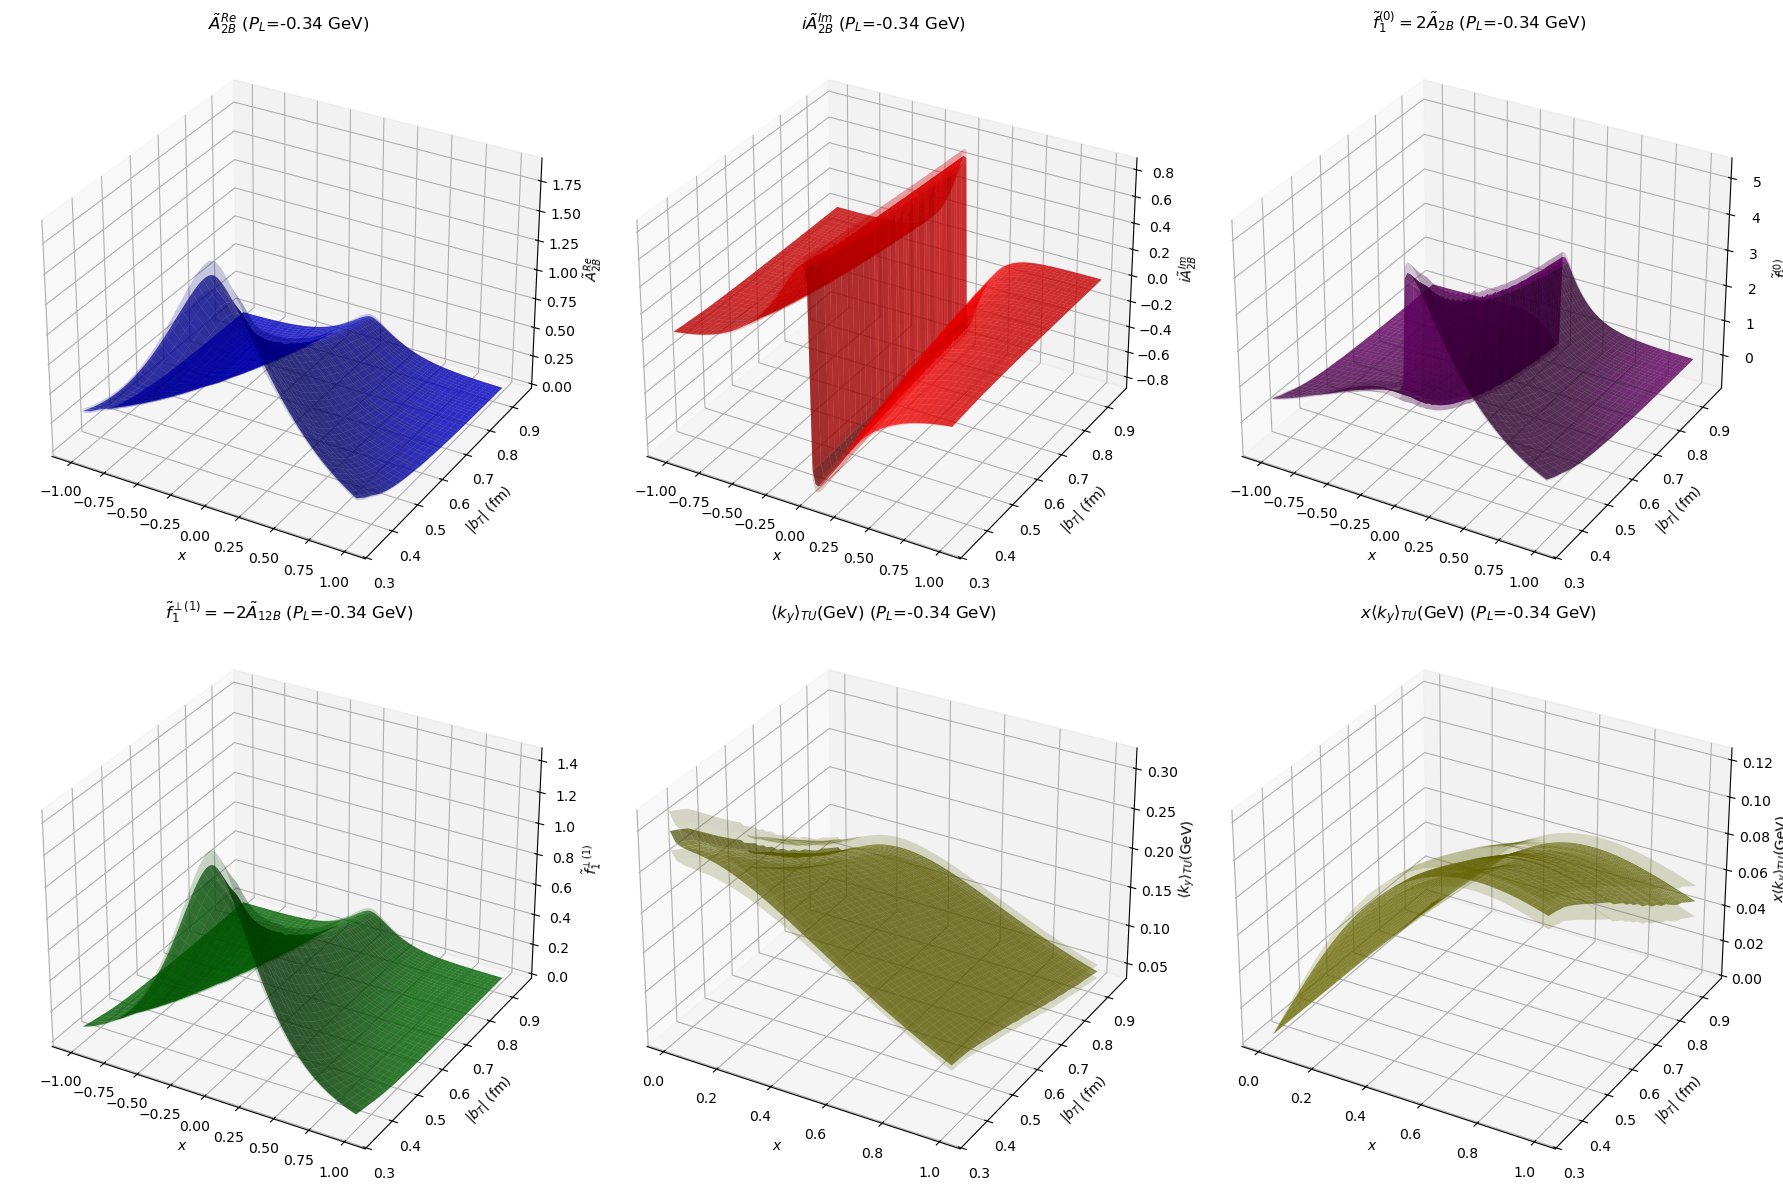

In [2]:
b2 = 9
PL = -1
bminfit = 3
etamin = 6
etamax = 10
#sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin3_eta610_PL-4.h5
fitted_params, chi2_dof_list = load_params_from_h5(f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")
plot_fourier_transforms_3D(fitted_params, chi2_dof_list, PL, bminfit, etamin, etamax)



### Simultaneous Fit with common f: 
 for PL=-2, $b_{min} \ge 3$, $\eta \in [6, 10]$

 $\chi^2/\text{DoF}$ = 1.197(85) (Global)

| Amplitude | Model Expression | Params List | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\text{Re}A_{2B}$ | $\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, k_1, k_2, j, f\}$ | $[3.9833(80), 0.166(35), 0.1020(46), 12.305(14), -36.1919(27), 2.061(20), 0.5357(66)]$ |
| $\text{Im}A_{2B}$ | $\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.368(12), 0.1346(69), 0.1305(67), 1.141(20), 0.5357(66)]$ |
| $\text{Re}A_{12B}$ | $\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.632(19), 0.0769(54), 0.0741(52), 2.0141(69), 0.5357(66)]$ |



Evaluating Fourier transforms and applying Jackknife for 3D Plotting...


Evaluating over b^2 grid:   0%|          | 0/40 [00:00<?, ?it/s]

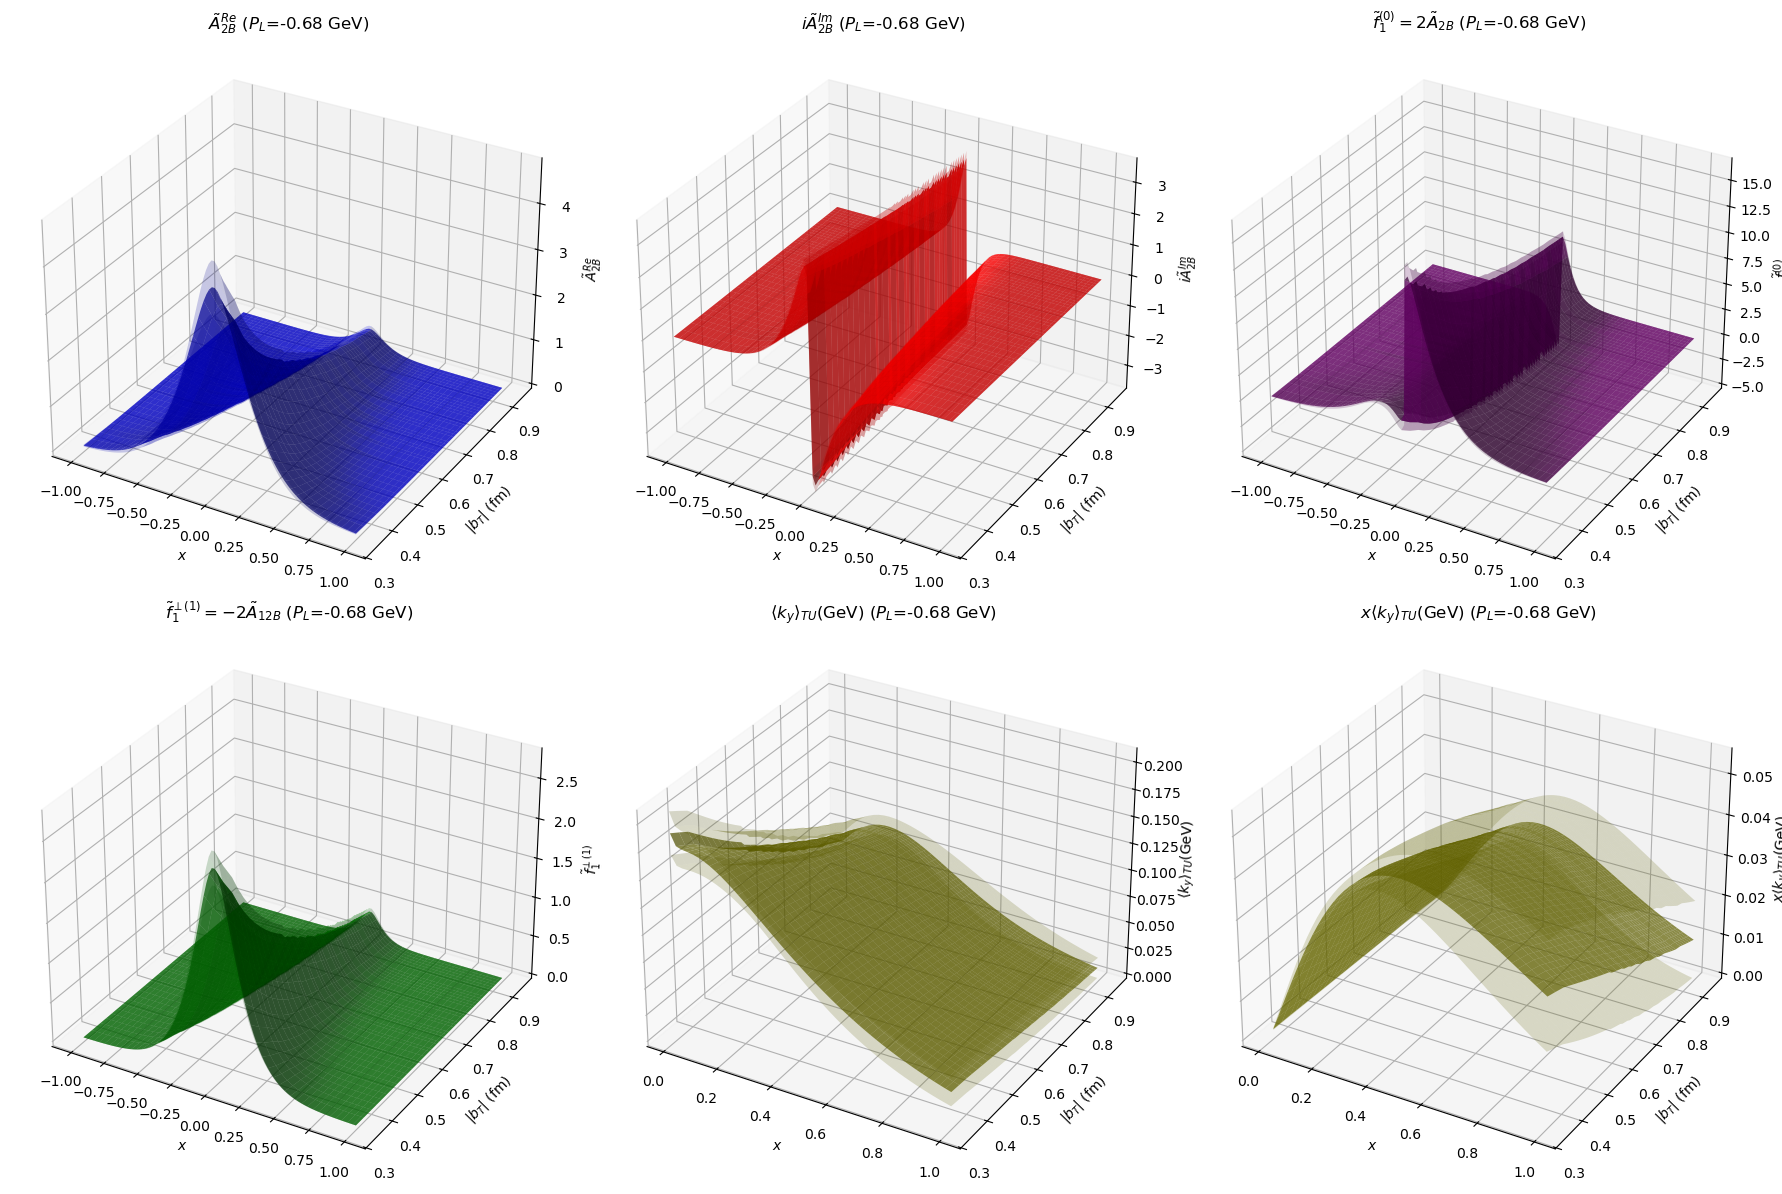

In [3]:
PL = -2
bminfit = 3
etamin = 6
etamax = 10
#sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin3_eta610_PL-4.h5
fitted_params, chi2_dof_list = load_params_from_h5(f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")
plot_fourier_transforms_3D(fitted_params, chi2_dof_list, PL, bminfit, etamin, etamax)



### Simultaneous Fit with common f: 
 for PL=-3, $b_{min} \ge 3$, $\eta \in [6, 10]$

 $\chi^2/\text{DoF}$ = 0.712(66) (Global)

| Amplitude | Model Expression | Params List | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\text{Re}A_{2B}$ | $\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, k_1, k_2, j, f\}$ | $[4.0061(31), 0.45(12), 0.136(11), 12.284(11), -36.1973(19), 2.085(10), 0.540(15)]$ |
| $\text{Im}A_{2B}$ | $\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.328(11), 0.163(15), 0.147(13), 1.057(15), 0.540(15)]$ |
| $\text{Re}A_{12B}$ | $\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.569(13), 0.100(17), 0.094(16), 1.9969(49), 0.540(15)]$ |



Evaluating Fourier transforms and applying Jackknife for 3D Plotting...


Evaluating over b^2 grid:   0%|          | 0/40 [00:00<?, ?it/s]

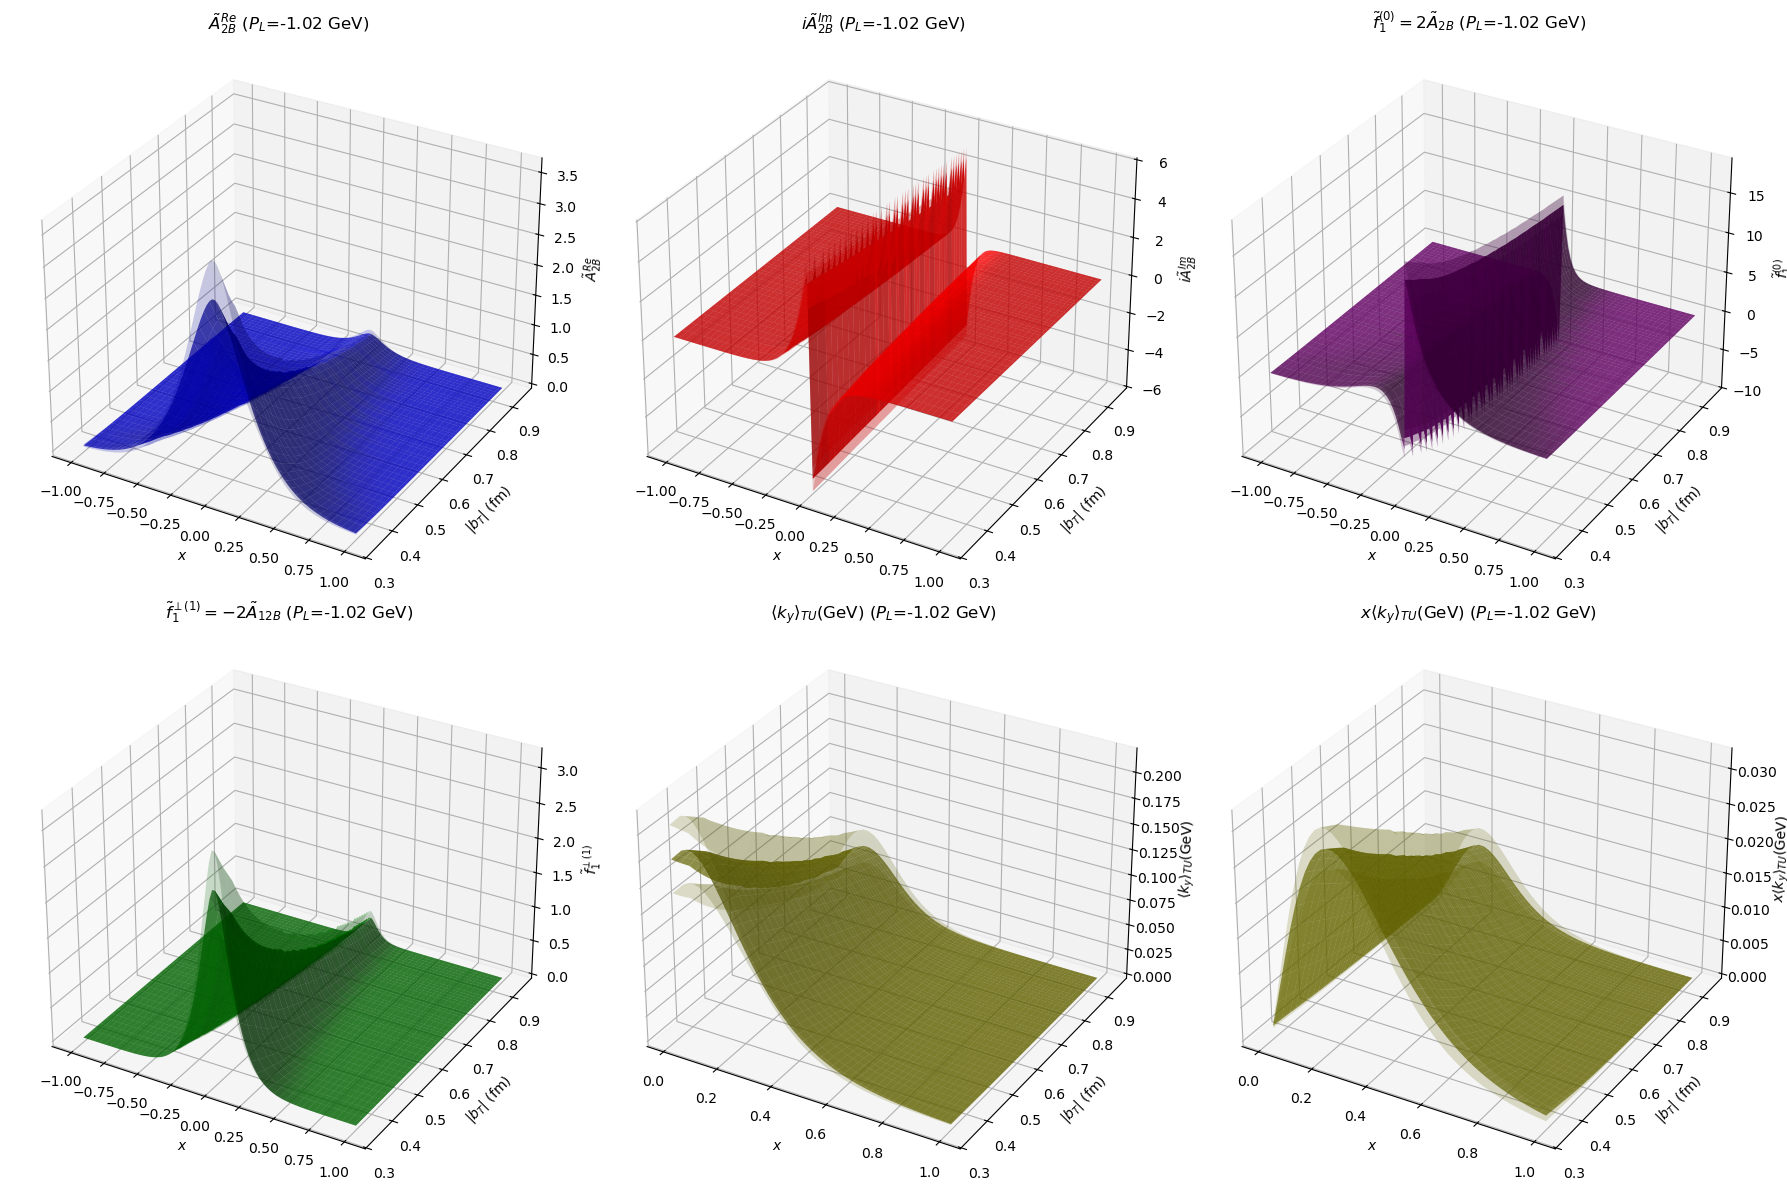

In [4]:
PL = -3
bminfit = 3
etamin = 6
etamax = 10
#sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin3_eta610_PL-4.h5
fitted_params, chi2_dof_list = load_params_from_h5(f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")
plot_fourier_transforms_3D(fitted_params, chi2_dof_list, PL, bminfit, etamin, etamax)



### Simultaneous Fit with common f: 
 for PL=-4, $b_{min} \ge 3$, $\eta \in [6, 10]$

 $\chi^2/\text{DoF}$ = 0.434(51) (Global)

| Amplitude | Model Expression | Params List | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\text{Re}A_{2B}$ | $\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, k_1, k_2, j, f\}$ | $[4.0086(15), 0.27(21), 0.122(13), 12.2751(58), -36.19925(89), 2.0654(56), 0.577(19)]$ |
| $\text{Im}A_{2B}$ | $\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.269(13), 0.264(47), 0.196(14), 1.0084(79), 0.577(19)]$ |
| $\text{Re}A_{12B}$ | $\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.5824(55), 0.116(19), 0.102(18), 2.0059(34), 0.577(19)]$ |



Evaluating Fourier transforms and applying Jackknife for 3D Plotting...


Evaluating over b^2 grid:   0%|          | 0/40 [00:00<?, ?it/s]

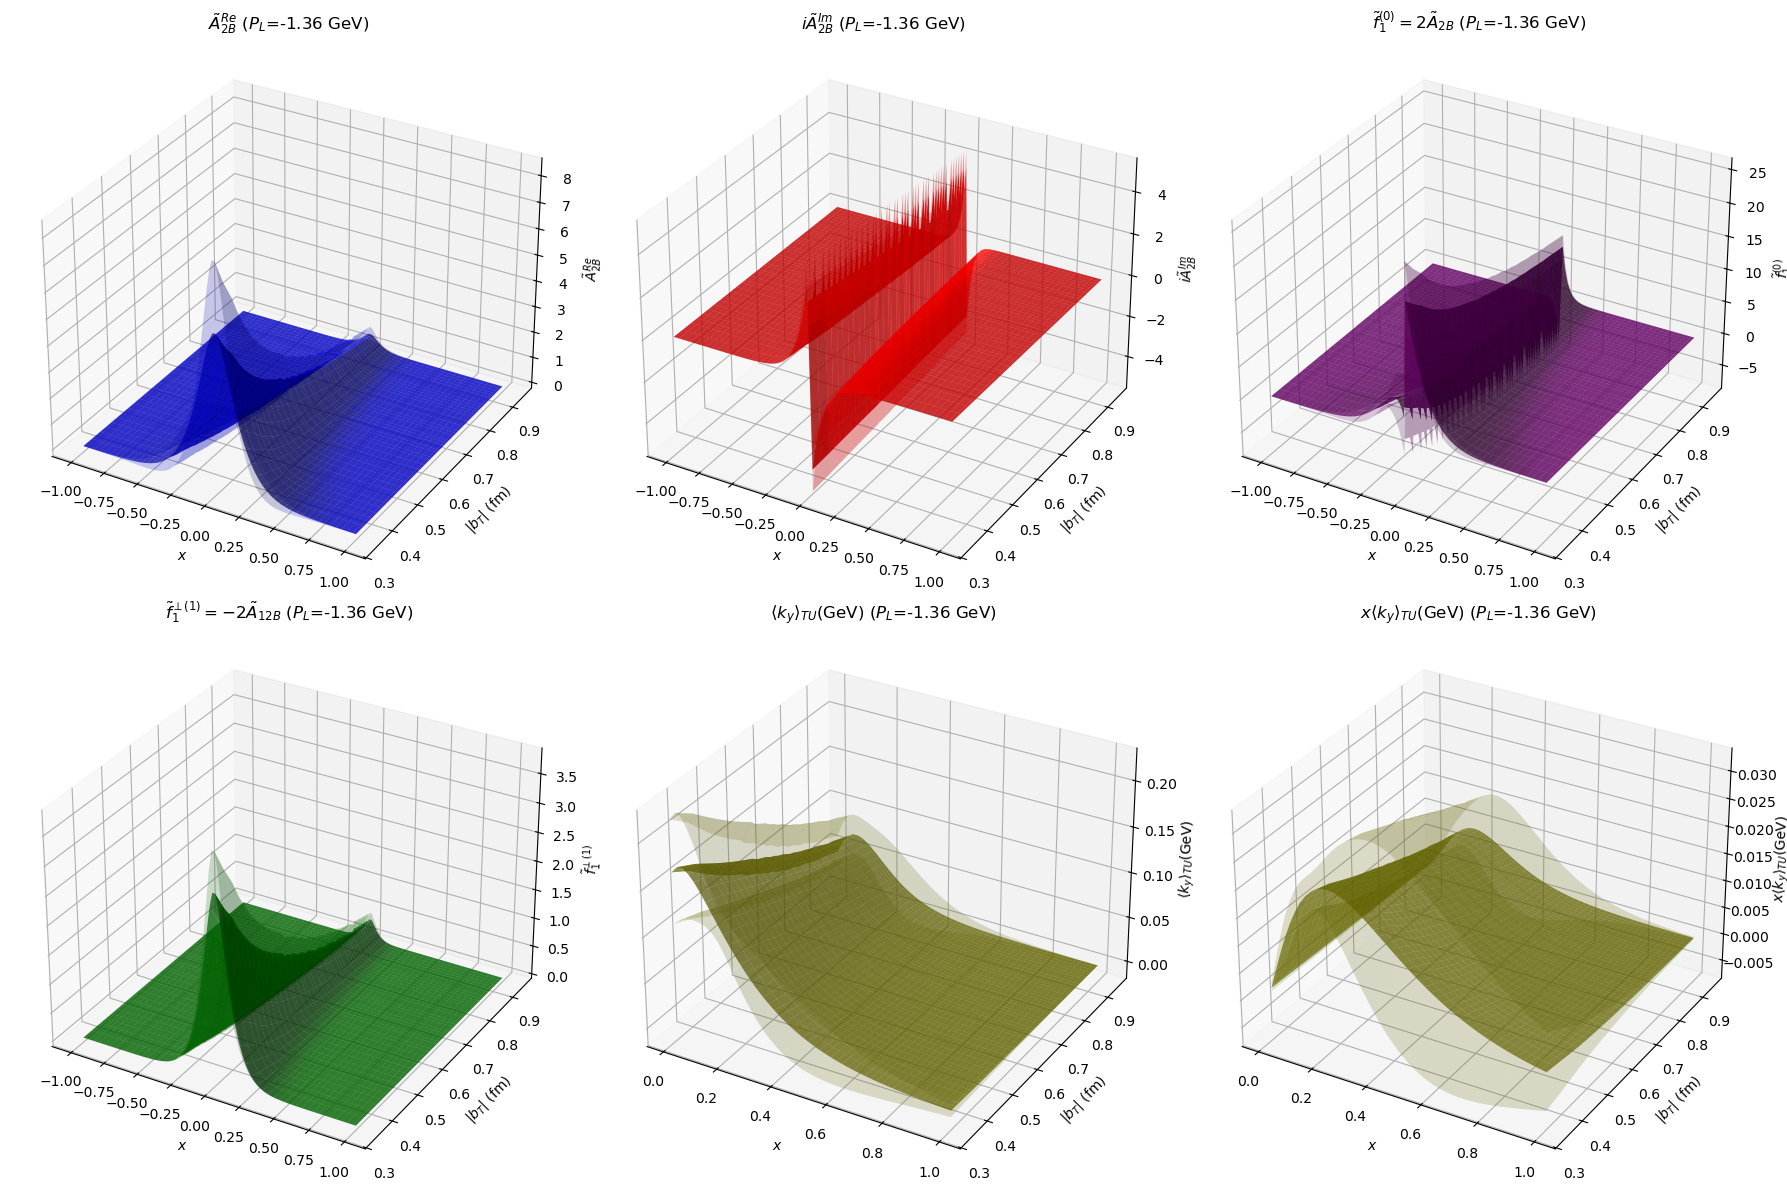

In [5]:
PL = -4
bminfit = 3
etamin = 6
etamax = 10
#sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin3_eta610_PL-4.h5
fitted_params, chi2_dof_list = load_params_from_h5(f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")
plot_fourier_transforms_3D(fitted_params, chi2_dof_list, PL, bminfit, etamin, etamax)



Evaluating discrete Fourier transforms over PL list for fixed b^2 = 9.0...


Evaluating PL slices:   0%|          | 0/4 [00:00<?, ?it/s]

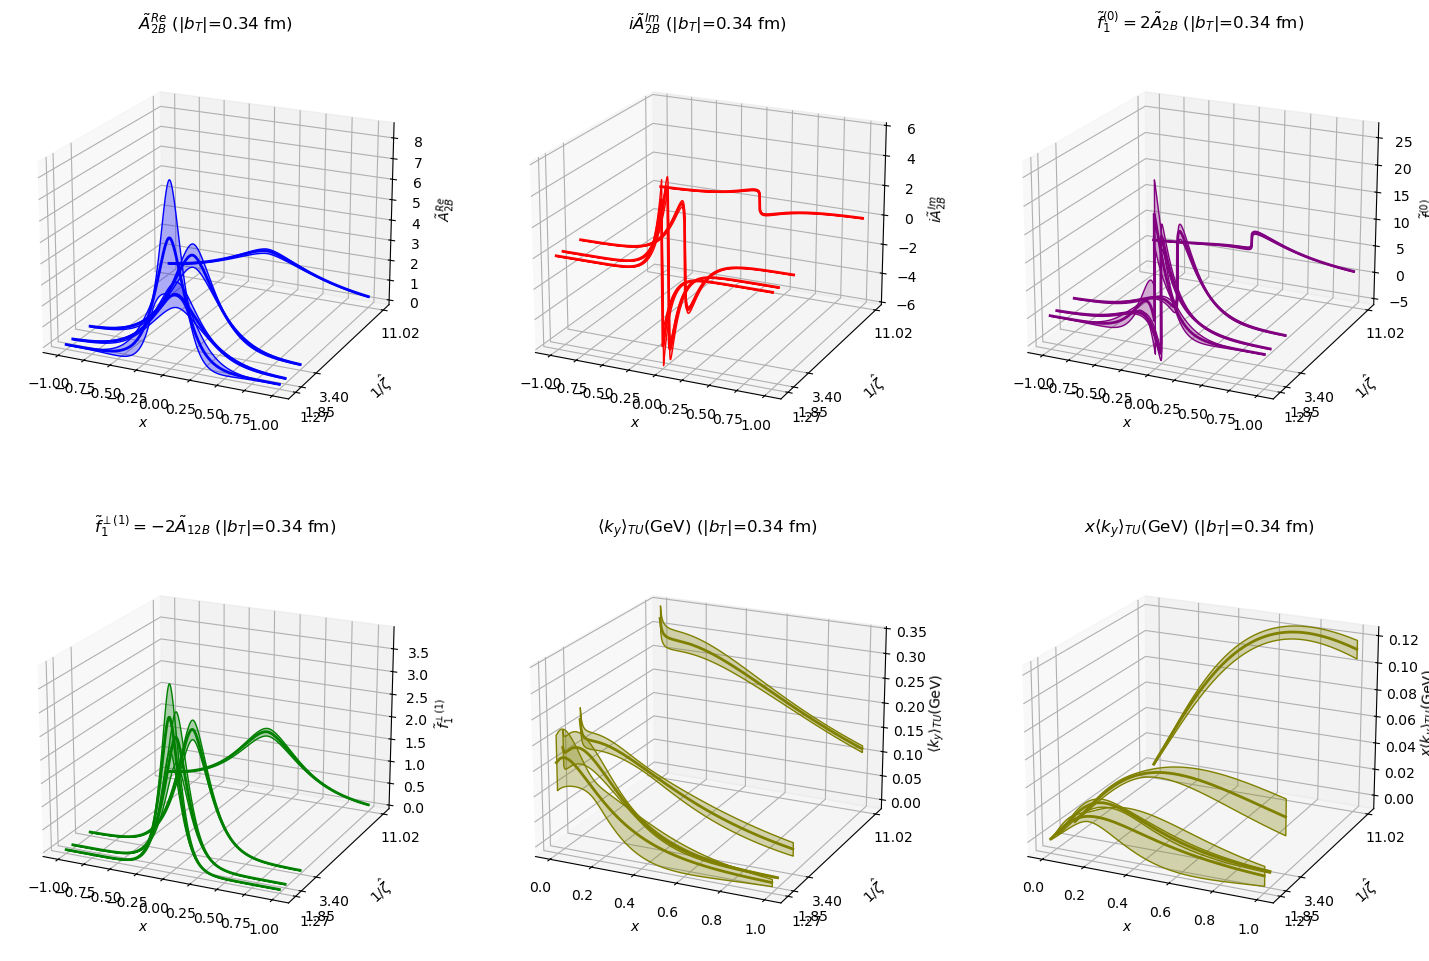

In [7]:
import h5py
import numpy as np
import math
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.special import kv, gamma

# ---------------------------------------------------------
# 1. Jackknife Statistics Helper
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        # Load the jackknifed parameter samples
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            fitted_params[key] = param_group[key][:]
            
        # Load the chi-square per dof array
        chi2_dof_list = f["chi2_dof"][:]
        
    return fitted_params, chi2_dof_list

# ---------------------------------------------------------
# 2. 3D Plotting Function (Distinct Slices for 1/PL)
# ---------------------------------------------------------
def plot_fourier_transforms_3D_PL_discrete(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=500):
    pl_to_zeta = {-4: 0.785756, -3: 0.539684, -2: 0.294367, -1: 0.090772}
    
    # 1. Setup X (x-values)
    x_vals = np.linspace(-1, 1, num_points_x)
    
    

    #P_L_GeV = np.round(PL * (197.32698 * 0.001 * 2 * np.pi / (lata * 32)), 2)
    
    # Calculate 1/PL and sort them
    inv_zeta_vals = np.array([1.0 / pl_to_zeta.get(pl) for pl in PL_list])
    sort_idx = np.argsort(inv_zeta_vals)
    inv_zeta_vals = inv_zeta_vals[sort_idx]
    sorted_PL_list = [PL_list[i] for i in sort_idx]

    # Initialize figure
    fig = plt.figure(figsize=(18, 12))
    ax1 = fig.add_subplot(231, projection='3d')
    ax2 = fig.add_subplot(232, projection='3d')
    ax3 = fig.add_subplot(233, projection='3d')
    ax4 = fig.add_subplot(234, projection='3d')
    ax5 = fig.add_subplot(235, projection='3d')
    ax6 = fig.add_subplot(236, projection='3d')
    
    axes = [ax1, ax2, ax3, ax4, ax5, ax6]

    # Helper function to plot a discrete 3D slice (line + vertical error band)
    def add_discrete_3d_band(ax, x, y_val, mean, err, color):
        # Plot the central mean line
        ax.plot(x, [y_val]*len(x), mean, color=color, linewidth=2)
        
        # Create a vertical polygon for the error band
        x_poly = np.concatenate([x, x[::-1]])
        y_poly = np.full_like(x_poly, y_val)
        z_poly = np.concatenate([mean - err, (mean + err)[::-1]])
        
        # Add polygon to axes
        verts = [list(zip(x_poly, y_poly, z_poly))]
        poly = Poly3DCollection(verts, color=color, alpha=0.3)
        ax.add_collection3d(poly)
        
        # Update limits manually since add_collection3d doesn't auto-scale Z
        ax.auto_scale_xyz(x, [y_val]*len(x), z_poly, had_data=True)

    print(f"\nEvaluating discrete Fourier transforms over PL list for fixed b^2 = {b2}...")
    lata = 0.11403
    # Loop over PL
    for i, pl in enumerate(tqdm(sorted_PL_list, desc="Evaluating PL slices")):
        #lata = 0.11403
        mass_filepath = "/pscratch/sd/h/hari_8/TMD_fit/h5data/MassN_Jackknife.h5"
        with h5py.File(mass_filepath, "r") as f:
            MassN_jk = f[f"PL_{pl}"][:] 
        massterm = MassN_jk * (197.32698 * 0.001 / lata)
        
        y_val = 1.0 / pl_to_zeta[pl]
        
        # Dynamically load the data for the current PL
        filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{pl}.h5"
        fitted_params, _ = load_params_from_h5(filename)
        
        # Extract parameters specifically scaled for this PL
        a_re = np.array(fitted_params['a_re'])
        c_re = np.array(fitted_params['c_re']) / (pl**2)
        j_re = np.array(fitted_params['j_re'])
        d_re = 1.0 + np.array(fitted_params['d_re']) * b2  

        a_im = np.array(fitted_params['a_im']) / pl
        c_im = np.array(fitted_params['c_im']) / (pl**2)
        j_im = np.array(fitted_params['j_im'])
        d_im = 1.0 + np.array(fitted_params['d_im']) * b2

        a_reA12B = -np.array(fitted_params['a_reA12B'])
        c_reA12B = np.array(fitted_params['c_reA12B']) / (pl**2)
        j_reA12B = np.array(fitted_params['j_reA12B'])
        d_reA12B = 1.0 + np.array(fitted_params['d_reA12B']) * b2
        
        # Initialize arrays for this specific slice
        re_m, re_e = np.zeros_like(x_vals), np.zeros_like(x_vals)
        im_m, im_e = np.zeros_like(x_vals), np.zeros_like(x_vals)
        full_m, full_e = np.zeros_like(x_vals), np.zeros_like(x_vals)
        reA12B_m, reA12B_e = np.zeros_like(x_vals), np.zeros_like(x_vals)
        siv_m, siv_e = np.zeros_like(x_vals), np.zeros_like(x_vals)
        xsiv_m, xsiv_e = np.zeros_like(x_vals), np.zeros_like(x_vals)
        
        # Evaluate for each x
        for j, x in enumerate(x_vals):
            abs_x = max(np.abs(x), 1e-12)
            safe_x = x if x != 0 else 1e-12

            # --- Evaluate Real Part ---
            cd_R = c_re / d_re
            term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
            term2_R = abs_x**(-0.5 + j_re)
            bessel_R = kv(0.5 - j_re, abs_x / np.sqrt(cd_R))
            re_evals = term1_R * term2_R * bessel_R
            re_m[j], re_e[j] = Jackknife(re_evals)

            # --- Evaluate Imaginary Part ---
            cd_I = c_im / d_im
            term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
            term2_I = safe_x * abs_x**(-1.5 + j_im)
            bessel_I = kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)
            im_evals = term1_I * term2_I * bessel_I
            im_m[j], im_e[j] = Jackknife(im_evals)

            # --- Full A2B ---
            full_m[j], full_e[j] = Jackknife(2*(re_evals - im_evals))

            # --- Evaluate ReA12B Part ---
            cd_RA12B = c_reA12B / d_reA12B
            term1_RA12B = (2**(1 - j_reA12B) * a_reA12B * cd_RA12B**(-0.25 - j_reA12B/2) * d_reA12B**(-j_reA12B)) / gamma(j_reA12B)
            term2_RA12B = abs_x**(-0.5 + j_reA12B)
            bessel_RA12B = kv(0.5 - j_reA12B, abs_x / np.sqrt(cd_RA12B))
            reA12B_evals = term1_RA12B * term2_RA12B * bessel_RA12B
            reA12B_m[j], reA12B_e[j] = Jackknife(-2*reA12B_evals)

            # --- Sivers Shift ---
            siv_evals = (-massterm * reA12B_evals) / (re_evals - im_evals)
            siv_m[j], siv_e[j] = Jackknife(siv_evals)
            xsiv_m[j], xsiv_e[j] = Jackknife(safe_x * siv_evals)

        # Draw the slices onto the subplots
        add_discrete_3d_band(ax1, x_vals, y_val, re_m, re_e, 'blue')
        add_discrete_3d_band(ax2, x_vals, y_val, im_m, im_e, 'red')
        add_discrete_3d_band(ax3, x_vals, y_val, full_m, full_e, 'purple')
        add_discrete_3d_band(ax4, x_vals, y_val, reA12B_m, reA12B_e, 'green')

        # Sivers shift plots (Masked for x >= 0)
        mask = x_vals >= 0
        x_pos = x_vals[mask]
        add_discrete_3d_band(ax5, x_pos, y_val, siv_m[mask], siv_e[mask], 'olive')
        add_discrete_3d_band(ax6, x_pos, y_val, xsiv_m[mask], xsiv_e[mask], 'olive')

    # ---------------------------------------------------------
    # 3. Apply Formatting & Labels to all subplots
    # ---------------------------------------------------------
    titles = [
        f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($|b_T|$={np.round(np.sqrt(b2)*lata, 2)} fm)',
        f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($|b_T|$={np.round(np.sqrt(b2)*lata, 2)} fm)',
        f'$\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$ ($|b_T|$={np.round(np.sqrt(b2)*lata, 2)} fm)',
        f'$\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$ ($|b_T|$={np.round(np.sqrt(b2)*lata, 2)} fm)',
        f'$\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ($|b_T|$={np.round(np.sqrt(b2)*lata, 2)} fm)',
        f'$x\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ($|b_T|$={np.round(np.sqrt(b2)*lata, 2)} fm)'
    ]
    
    zlabels = [
        '$\\tilde{A}_{2B}^{Re}$', '$i\\tilde{A}_{2B}^{Im}$', '$\\tilde{f}_{1}^{(0)}$',
        '$\\tilde{f}_{1}^{\\perp(1)}$', '$\\langle k_{y} \\rangle_{TU}$(GeV)', '$x\\langle k_{y} \\rangle_{TU}$(GeV)'
    ]

    for idx, ax in enumerate(axes):
        ax.set_title(titles[idx])
        ax.set_xlabel('$x$')
        ax.set_ylabel('$1/\\hat\\zeta$')
        ax.set_zlabel(zlabels[idx])
        
        # Enforce strict discrete ticks on the Y-axis so only exact 1/PL values appear
        ax.set_yticks(inv_zeta_vals)
        ax.set_yticklabels([f"{v:.2f}" for v in inv_zeta_vals])
        ax.view_init(elev=20, azim=-65)

    #plt.tight_layout()
    file_name = f"SimulFit_Distinct_1_over_PL_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()

# ---------------------------------------------------------

# ---------------------------------------------------------
bminfit = 3
etamin = 6
etamax = 10
PL_list = [-1, -2, -3, -4]

#num_points_x=500
# Execute the plot
plot_fourier_transforms_3D_PL_discrete(PL_list, bminfit, etamin, etamax, b2=9.0)


Evaluating discrete Fourier transforms over PL list for fixed b^2 = 9.0...


Evaluating PL slices:   0%|          | 0/3 [00:00<?, ?it/s]

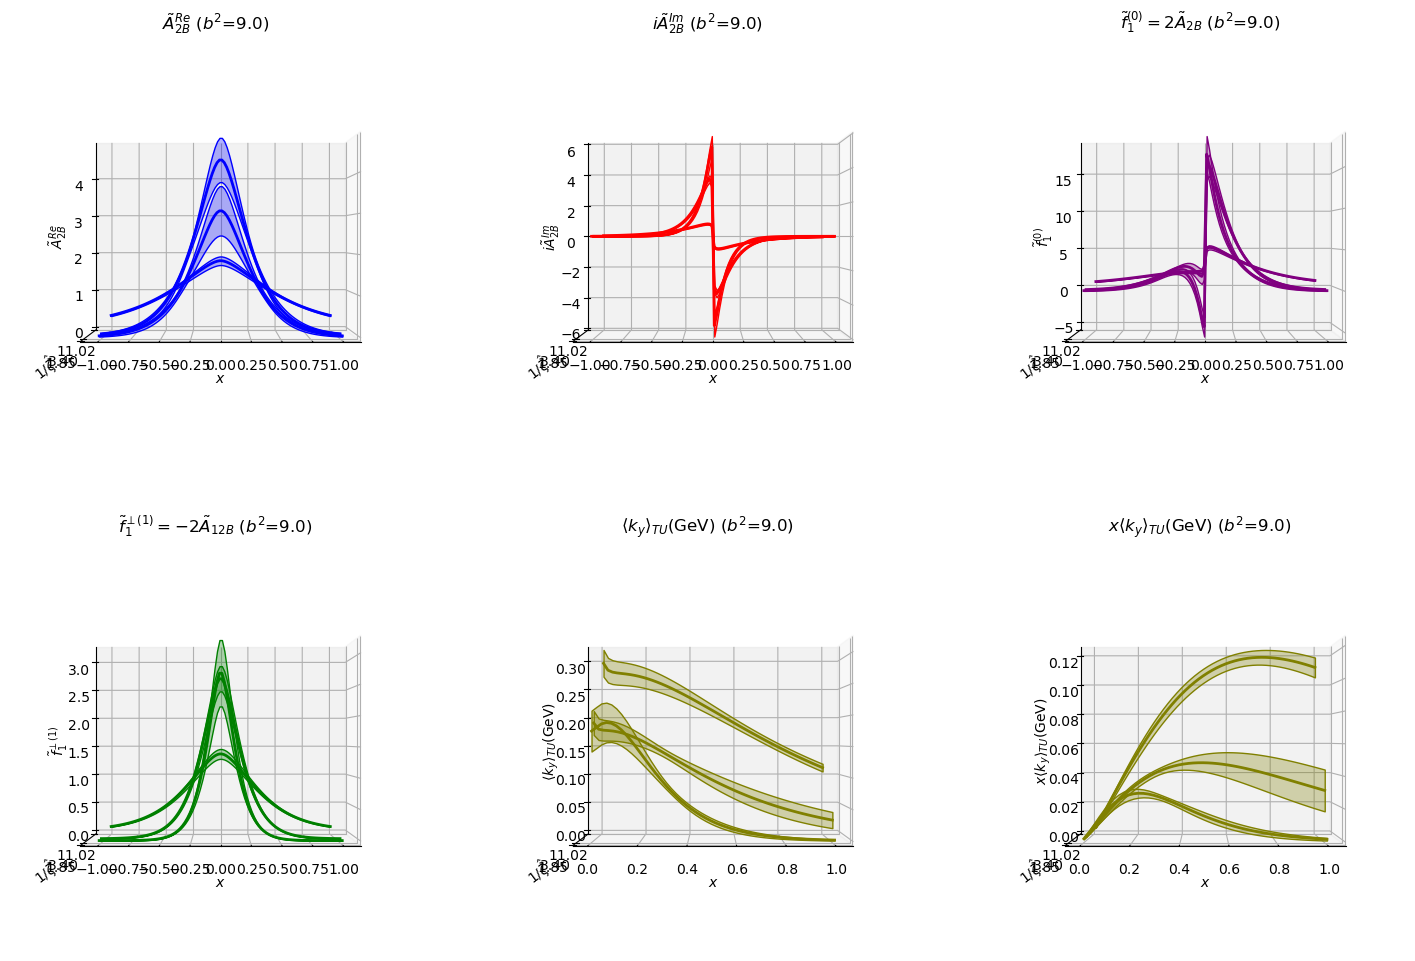

In [5]:
bminfit = 3
etamin = 6
etamax = 10
PL_list = [-1, -2, -3]

# Execute the plot
plot_fourier_transforms_3D_PL_discrete(PL_list, bminfit, etamin, etamax, b2=9.0)

In [21]:
pl_to_zeta = {-4: 0.785756, -3: 0.539684, -2: 0.294367, -1: 0.090772}

# Assuming pl is defined elsewhere, e.g., pl = -3
pl_to_zeta[-4]

0.785756

In [11]:
import h5py
import numpy as np
import math
import gvar as gv
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma

# ---------------------------------------------------------
# 1. Jackknife Statistics Helper (Exact from User)
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    # Fallback for 0 or negative error
    if err <= 0:
        return f"{mean}"
        
    # Switch to scientific if very small/big
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        # Calculate exponent of the mean
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
        
    else:
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1))  # -1 gives us 2 sig figs instead of 1
        
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"


def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        # Load the jackknifed parameter samples
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            fitted_params[key] = param_group[key][:]
            
        # Load the chi-square per dof array
        chi2_dof_list = f["chi2_dof"][:]
        
    return fitted_params, chi2_dof_list

# ---------------------------------------------------------
# 2. Extrapolation Routine using LSQFIT
# ---------------------------------------------------------
def fit_1_over_zeta_lsqfit(inv_zeta_vals, y_jk_samples):
    """
    Fits y = c0 + c1 * (1/zeta_hat) separately for every jackknife sample.
    inv_zeta_vals: 1D array of length N_PL
    y_jk_samples: 2D array of shape (N_PL, N_JK) containing the finite momentum ratio
    """
    N_PL, N_JK = y_jk_samples.shape

    # 1. Evaluate Jackknife Mean and Covariance
    mean_y = np.mean(y_jk_samples, axis=1)

    cov_y = np.cov(y_jk_samples, bias=True) * (N_JK - 1)
    '''
    cov_y = np.zeros((N_PL, N_PL))
    for i in range(N_PL):
        for j in range(N_PL):
            cov_y[i, j] = ((N_JK - 1) / N_JK) * np.sum(
                (y_jk_samples[i, :] - mean_y[i]) * (y_jk_samples[j, :] - mean_y[j])
            )
    '''

    # Create gvar for the central fit to get accurate chi2/dof
    try:
        y_gvar = gv.gvar(mean_y, cov_y)
    except Exception:
        # Fallback to diagonal errors if covariance matrix is numerically degenerate
        y_gvar = gv.gvar(mean_y, np.sqrt(np.diag(cov_y)))

    def fcn(x, p):
        return p['c0']  + p['c2'] * x**2

    # Loose prior
    prior = {'c0': gv.gvar(0, 5000000), 'c2': gv.gvar(0, 5000000)}


    # 2. Fit every individual jackknife sample
    c0_jk = []
    cov_y_eval = gv.evalcov(y_gvar)
    chi2_dof_list = []

    for k in range(N_JK):
        # We use the full ensemble covariance but shift the central values to the specific JK sample
        y_k_gvar = gv.gvar(y_jk_samples[:, k], cov_y_eval)
        fit_k = lsqfit.nonlinear_fit(data=(inv_zeta_vals, y_k_gvar), fcn=fcn, prior=prior)
        c0_jk.append(fit_k.pmean['c0'])
        chi2_dof_list.append(fit_k.chi2 / fit_k.dof)

    # Return the list of extrapolated c0 values and chi2 for external processing
    return c0_jk, chi2_dof_list

# ---------------------------------------------------------
# 3. Main Sivers Extrapolation & Plotting
# ---------------------------------------------------------
def extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=100):
    
    # Range of x from 0 to 1
    x_vals = np.linspace(0, 1, num_points_x)
    
    
    # Exact provided mapping for PL to zeta_hat
    pl_to_zeta = {
        -4: 0.785756,
        -3: 0.539684,
        -2: 0.294367,
        -1: 0.090772
    }
    
    # Calculate 1/zeta_hat and sort to ensure ascending arrays
    inv_zeta_vals = np.array([1.0 / pl_to_zeta[pl] for pl in PL_list])
    sort_idx = np.argsort(inv_zeta_vals)
    inv_zeta_vals = inv_zeta_vals[sort_idx]
    sorted_PL_list = [PL_list[i] for i in sort_idx]
    N_PL = len(sorted_PL_list)
    
    # Discover N_JK from the first file
    init_filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{sorted_PL_list[0]}.h5"
    init_params, _ = load_params_from_h5(init_filename)
    N_JK = len(init_params['a_re'])

    # Pre-allocate ratio arrays: shape (N_PL, num_points_x, N_JK)
    siv_finite_all = np.zeros((N_PL, num_points_x, N_JK))
    xsiv_finite_all = np.zeros((N_PL, num_points_x, N_JK))

    for i, pl in enumerate(sorted_PL_list):
        filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{pl}.h5"
        fitted_params, _ = load_params_from_h5(filename)
        
        # Scaling parameters
        a_re, c_re, j_re, d_re = fitted_params['a_re'], fitted_params['c_re'] / (pl**2), fitted_params['j_re'], 1.0 + fitted_params['d_re'] * b2
        a_im, c_im, j_im, d_im = fitted_params['a_im'] / pl, fitted_params['c_im'] / (pl**2), fitted_params['j_im'], 1.0 + fitted_params['d_im'] * b2
        a_reA12B, c_reA12B, j_reA12B, d_reA12B = -fitted_params['a_reA12B'], fitted_params['c_reA12B'] / (pl**2), fitted_params['j_reA12B'], 1.0 + fitted_params['d_reA12B'] * b2

        for j, x in enumerate(x_vals):
            abs_x = max(np.abs(x), 1e-12)
            safe_x = x if x != 0 else 1e-12

            # ReA2B
            cd_R = c_re / d_re
            term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
            re_evals = term1_R * (abs_x**(-0.5 + j_re)) * kv(0.5 - j_re, abs_x / np.sqrt(cd_R))

            # ImA2B
            cd_I = c_im / d_im
            term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
            im_evals = term1_I * (safe_x * abs_x**(-1.5 + j_im)) * kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)

            # ReA12B
            cd_RA12B = c_reA12B / d_reA12B
            term1_RA12B = (2**(1 - j_reA12B) * a_reA12B * cd_RA12B**(-0.25 - j_reA12B/2) * d_reA12B**(-j_reA12B)) / gamma(j_reA12B)
            reA12B_evals = term1_RA12B * (abs_x**(-0.5 + j_reA12B)) * kv(0.5 - j_reA12B, abs_x / np.sqrt(cd_RA12B))

            # Calculate the Sivers Shift exact array for this specific PL
            siv_evals = (-massterm * reA12B_evals) / (re_evals - im_evals)
            
            siv_finite_all[i, j, :] = siv_evals
            xsiv_finite_all[i, j, :] = safe_x * siv_evals

   
    print(f"{'x':<6} | {'Sivers shift (1/z=0 limit)':<25} | {'chi2/dof'}")
    print("-" * 55)

    siv_m, siv_e = np.zeros(num_points_x), np.zeros(num_points_x)
    xsiv_m, xsiv_e = np.zeros(num_points_x), np.zeros(num_points_x)

    for j, x in enumerate(tqdm(x_vals)):
        
        # Fit Sivers Ratio
        c0_jk_siv, chi2_siv = fit_1_over_zeta_lsqfit(inv_zeta_vals, siv_finite_all[:, j, :])
        # Use exact Jackknife function provided to get mean and error
        siv_m[j], siv_e[j] = Jackknife(c0_jk_siv)
        
        # Fit x*Sivers Ratio
        #c0_jk_xsiv, chi2_xsiv = fit_1_over_zeta_lsqfit(inv_zeta_vals, xsiv_finite_all[:, j, :])
        # Use exact Jackknife function provided to get mean and error
        xsiv_m[j], xsiv_e[j] = Jackknife(x*np.array(c0_jk_siv))

        #if j % 10 == 0 or j == len(x_vals)-1:
        print(f"{x:5.2f}  |  {fmt_err(siv_m[j], siv_e[j])}       |  {fmt_err(*Jackknife(chi2_siv))}")
        #print(f"{x:5.2f}  |  {fmt_err(siv_m,siv_e)}       |  {fmt_err(Jackknife(chi2_siv))}")

    # ---------------------------------------------------------
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Sivers Shift Plot
    axes[0].plot(x_vals, siv_m, color='olive', linewidth=2)
    axes[0].fill_between(x_vals, siv_m - siv_e, siv_m + siv_e, color='olive', alpha=0.3)
    axes[0].set_title(f'Sivers Shift $\\langle k_{{y}} \\rangle_{{TU}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}^2$]', fontsize=14)
    axes[0].set_xlabel('$x$', fontsize=12)
    axes[0].set_ylabel('$\\langle k_{y} \\rangle_{TU}$(GeV)', fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # x * Sivers Shift Plot
    axes[1].plot(x_vals, xsiv_m, color='darkorange', linewidth=2)
    axes[1].fill_between(x_vals, xsiv_m - xsiv_e, xsiv_m + xsiv_e, color='darkorange', alpha=0.3)
    axes[1].set_title(f'$x *$ Sivers Shift ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}^2$]', fontsize=14)
    axes[1].set_xlabel('$x$', fontsize=12)
    axes[1].set_ylabel('$x\\langle k_{y} \\rangle_{TU}$(GeV)', fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    file_name = f"Extrapolated_Sivers_1_over_zetahatsq_P234_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()



x      | Sivers shift (1/z=0 limit) | chi2/dof
-------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

 0.00  |  0.224(84)       |  1.9(16)
 0.02  |  0.175(42)       |  0.002(52)
 0.04  |  0.184(42)       |  0.01(13)
 0.06  |  0.188(41)       |  0.04(23)
 0.08  |  0.186(39)       |  0.10(37)
 0.10  |  0.177(35)       |  0.20(52)
 0.12  |  0.164(30)       |  0.36(69)
 0.14  |  0.149(25)       |  0.54(85)
 0.16  |  0.136(21)       |  0.66(94)
 0.18  |  0.129(18)       |  0.60(89)
 0.20  |  0.122(17)       |  0.44(77)
 0.22  |  0.114(15)       |  0.29(62)
 0.24  |  0.104(13)       |  0.18(48)
 0.27  |  0.093(11)       |  0.10(37)
 0.29  |  0.0820(87)       |  0.06(28)
 0.31  |  0.0710(73)       |  0.03(20)
 0.33  |  0.0605(64)       |  0.01(13)
 0.35  |  0.0508(59)       |  0.004(70)
 0.37  |  0.0419(57)       |  4(203)e-4
 0.39  |  0.0338(58)       |  6(294)e-4
 0.41  |  0.0266(60)       |  0.004(69)
 0.43  |  0.0202(61)       |  0.01(11)
 0.45  |  0.0146(63)       |  0.01(14)
 0.47  |  0.0097(64)       |  0.02(17)
 0.49  |  0.0054(65)       |  0.03(20)
 0.51  |  0.0018(65)       |  0.04(

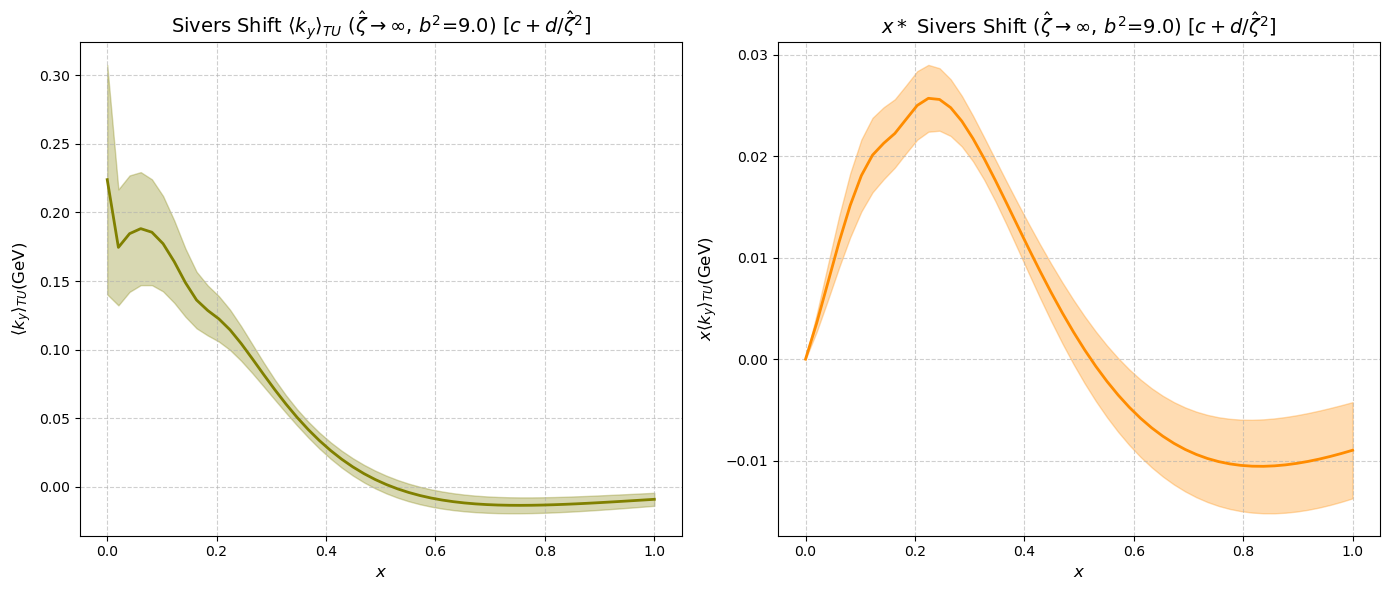

In [12]:
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-2, -3, -4]

    # Run the dedicated Sivers extrapolation
    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=50)

x      | Sivers shift (1/z=0 limit) | chi2/dof
-------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

 0.00  |  0.17(12)       |  1.8(15)
 0.02  |  0.171(62)       |  0.002(45)
 0.04  |  0.188(62)       |  0.01(14)
 0.06  |  0.193(60)       |  0.05(25)
 0.08  |  0.188(56)       |  0.11(38)
 0.10  |  0.176(50)       |  0.21(53)
 0.12  |  0.158(42)       |  0.34(68)
 0.14  |  0.138(35)       |  0.48(80)
 0.16  |  0.122(29)       |  0.55(86)
 0.18  |  0.112(26)       |  0.48(80)
 0.20  |  0.104(24)       |  0.33(67)
 0.22  |  0.093(21)       |  0.20(51)
 0.24  |  0.080(19)       |  0.10(37)
 0.27  |  0.065(16)       |  0.05(25)
 0.29  |  0.049(13)       |  0.02(15)
 0.31  |  0.034(12)       |  0.003(61)
 0.33  |  0.020(11)       |  3(183)e-4
 0.35  |  0.008(10)       |  0.005(82)
 0.37  |  -0.003(10)       |  0.01(14)
 0.39  |  -0.013(11)       |  0.03(19)
 0.41  |  -0.022(11)       |  0.04(24)
 0.43  |  -0.029(12)       |  0.06(28)
 0.45  |  -0.036(12)       |  0.08(32)
 0.47  |  -0.041(13)       |  0.10(36)
 0.49  |  -0.045(13)       |  0.11(39)
 0.51  |  -0.048(14)       |  0.13(42)
 0

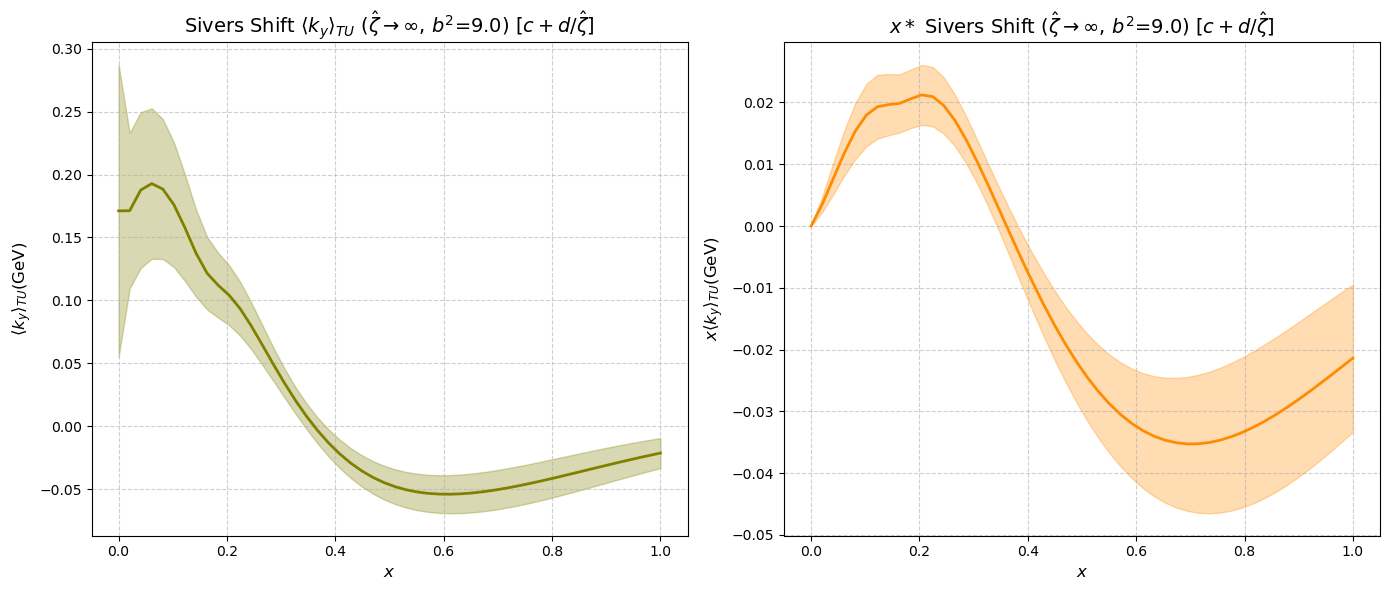

In [9]:
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-2, -3, -4]

    # Run the dedicated Sivers extrapolation
    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=50)

x      | Sivers shift (1/z=0 limit) | chi2/dof
-------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

 0.00  |  0.279(42)       |  1.6(13)
 0.02  |  0.169(19)       |  0.006(79)
 0.04  |  0.166(18)       |  0.06(25)
 0.06  |  0.166(17)       |  0.12(35)
 0.08  |  0.165(16)       |  0.17(41)
 0.10  |  0.162(16)       |  0.21(46)
 0.12  |  0.159(14)       |  0.28(53)
 0.14  |  0.154(13)       |  0.42(65)
 0.16  |  0.148(11)       |  0.61(78)
 0.18  |  0.144(10)       |  0.71(84)
 0.20  |  0.1410(93)       |  0.79(89)
 0.22  |  0.1369(84)       |  1.1(10)
 0.24  |  0.1311(75)       |  1.9(14)
 0.27  |  0.1232(66)       |  3.4(18)
 0.29  |  0.1131(58)       |  5.8(24)
 0.31  |  0.1013(51)       |  8.5(29)
 0.33  |  0.0892(46)       |  10.6(33)
 0.35  |  0.0781(43)       |  11.6(34)
 0.37  |  0.0685(42)       |  11.5(34)
 0.39  |  0.0601(42)       |  10.9(33)
 0.41  |  0.0526(43)       |  10.0(32)
 0.43  |  0.0458(44)       |  9.1(30)
 0.45  |  0.0396(45)       |  8.2(29)
 0.47  |  0.0340(46)       |  7.4(27)
 0.49  |  0.0289(46)       |  6.6(26)
 0.51  |  0.0244(45)       |  6.0(24)
 0.53 

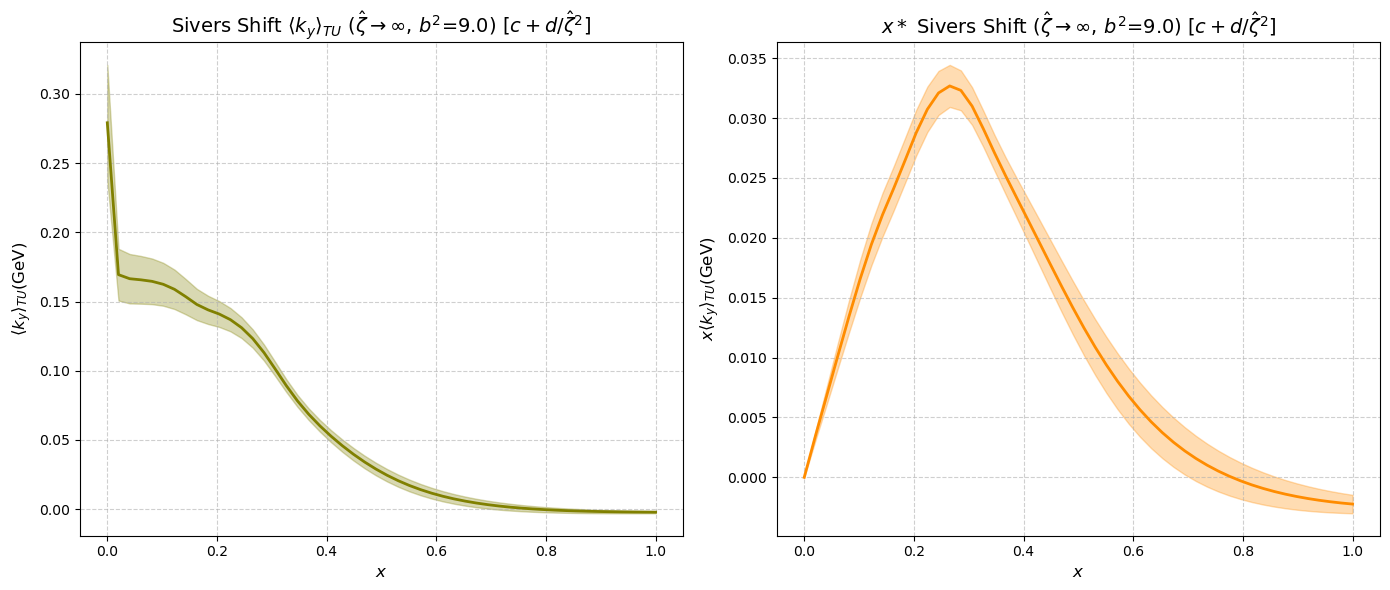

In [3]:
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-1, -2, -3, -4]

    # Run the dedicated Sivers extrapolation
    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=50)

x      | Sivers shift (1/z=0 limit) | chi2/dof
-------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

 0.00  |  0.244(51)       |  1.4(12)
 0.02  |  0.136(23)       |  0.09(31)
 0.04  |  0.134(22)       |  0.23(48)
 0.06  |  0.134(21)       |  0.32(56)
 0.08  |  0.133(20)       |  0.37(61)
 0.10  |  0.131(19)       |  0.40(63)
 0.12  |  0.127(17)       |  0.41(64)
 0.14  |  0.122(16)       |  0.42(65)
 0.16  |  0.116(14)       |  0.42(65)
 0.18  |  0.112(12)       |  0.36(60)
 0.20  |  0.108(11)       |  0.26(51)
 0.22  |  0.103(10)       |  0.22(46)
 0.24  |  0.0964(93)       |  0.35(59)
 0.27  |  0.0880(83)       |  0.81(90)
 0.29  |  0.0776(74)       |  1.7(13)
 0.31  |  0.0658(66)       |  2.8(17)
 0.33  |  0.0538(60)       |  3.7(19)
 0.35  |  0.0428(57)       |  4.3(21)
 0.37  |  0.0332(55)       |  4.5(21)
 0.39  |  0.0249(56)       |  4.3(21)
 0.41  |  0.0174(56)       |  4.1(20)
 0.43  |  0.0108(57)       |  3.8(19)
 0.45  |  0.0049(58)       |  3.4(19)
 0.47  |  -3(58)e-4       |  3.1(18)
 0.49  |  -0.0048(57)       |  2.8(17)
 0.51  |  -0.0088(56)       |  2.5(16)
 0.53  |  

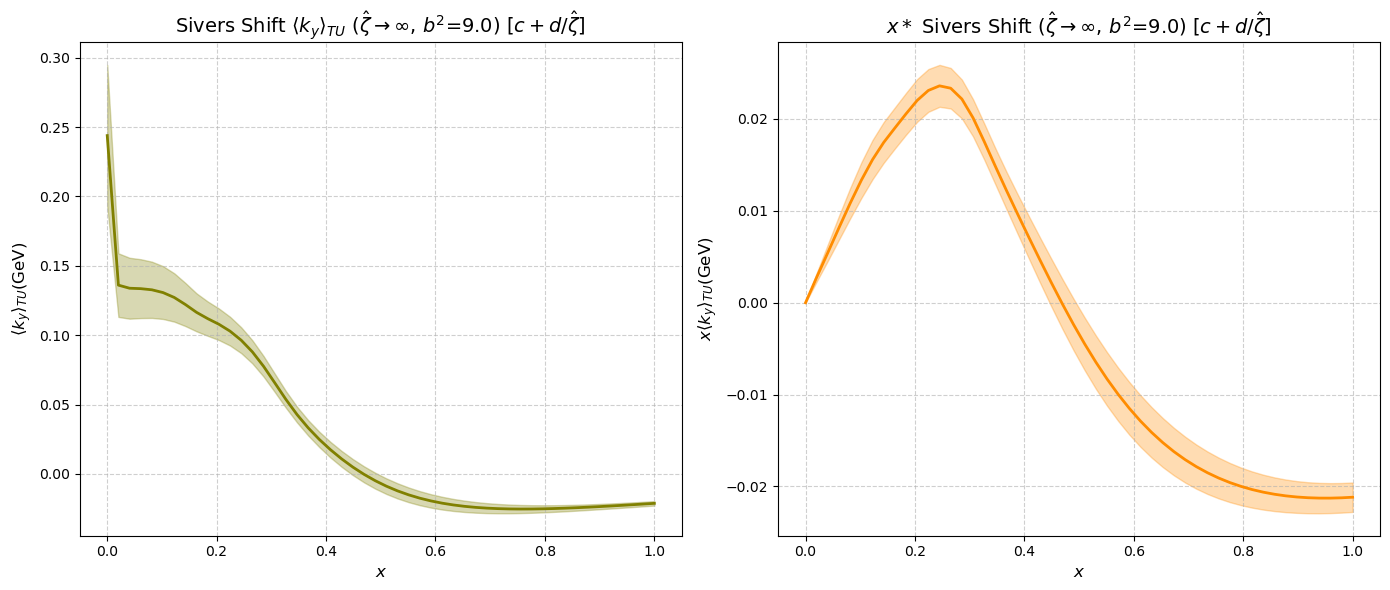

In [5]:
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-1, -2, -3, -4]

    # Run the dedicated Sivers extrapolation
    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=50)

In [ ]:
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-1, -2, -3, -4]

    # Run the dedicated Sivers extrapolation
    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=100)


[2] Performing Extrapolation to 1/zeta_hat -> 0 and Applying User Jackknife...
x      | Sivers shift (1/z=0 limit) | chi2/dof
-------------------------------------------------------


  0%|          | 0/100 [00:00<?, ?it/s]

 0.00  |  0.244(51)       |  1.4(12)
 0.10  |  0.131(19)       |  0.40(63)
 0.20  |  0.108(11)       |  0.27(52)


In [5]:
import h5py
import numpy as np
import math
import gvar as gv
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma

# ---------------------------------------------------------
# 1. Jackknife Statistics Helper (Exact from User)
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    # Fallback for 0 or negative error
    if err <= 0:
        return f"{mean}"
        
    # Switch to scientific if very small/big
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        # Calculate exponent of the mean
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
        
    else:
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1))  # -1 gives us 2 sig figs instead of 1
        
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"


def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        # Load the jackknifed parameter samples
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            fitted_params[key] = param_group[key][:]
            
        # Load the chi-square per dof array
        chi2_dof_list = f["chi2_dof"][:]
        
    return fitted_params, chi2_dof_list

# ---------------------------------------------------------
# 2. Extrapolation Routine using LSQFIT
# ---------------------------------------------------------
def fit_1_over_zeta_lsqfit(inv_zeta_vals, y_jk_samples):
    """
    Fits y = c0 + c1 * (1/zeta_hat) separately for every jackknife sample.
    inv_zeta_vals: 1D array of length N_PL
    y_jk_samples: 2D array of shape (N_PL, N_JK) containing the finite momentum ratio
    """
    N_PL, N_JK = y_jk_samples.shape

    # 1. Evaluate Jackknife Mean and Covariance
    mean_y = np.mean(y_jk_samples, axis=1)

    cov_y = np.cov(y_jk_samples, bias=True) * (N_JK - 1)
    '''
    cov_y = np.zeros((N_PL, N_PL))
    for i in range(N_PL):
        for j in range(N_PL):
            cov_y[i, j] = ((N_JK - 1) / N_JK) * np.sum(
                (y_jk_samples[i, :] - mean_y[i]) * (y_jk_samples[j, :] - mean_y[j])
            )
    '''

    # Create gvar for the central fit to get accurate chi2/dof
    try:
        y_gvar = gv.gvar(mean_y, cov_y)
    except Exception:
        # Fallback to diagonal errors if covariance matrix is numerically degenerate
        y_gvar = gv.gvar(mean_y, np.sqrt(np.diag(cov_y)))

    def fcn(x, p):
        return p['c0']  + p['c2'] * x

    # Loose prior
    prior = {'c0': gv.gvar(0, 5000000), 'c2': gv.gvar(0, 5000000)}


    # 2. Fit every individual jackknife sample
    c0_jk = []
    cov_y_eval = gv.evalcov(y_gvar)
    chi2_dof_list = []

    for k in range(N_JK):
        # We use the full ensemble covariance but shift the central values to the specific JK sample
        y_k_gvar = gv.gvar(y_jk_samples[:, k], cov_y_eval)
        fit_k = lsqfit.nonlinear_fit(data=(inv_zeta_vals, y_k_gvar), fcn=fcn, prior=prior)
        c0_jk.append(fit_k.pmean['c0'])
        chi2_dof_list.append(fit_k.chi2 / fit_k.dof)

    # Return the list of extrapolated c0 values and chi2 for external processing
    return c0_jk, chi2_dof_list

# ---------------------------------------------------------
# 3. Main Sivers Extrapolation & Plotting
# ---------------------------------------------------------
def extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=100):
    
    # Range of x from 0 to 1
    x_vals = np.linspace(0, 0.6, num_points_x)
    
    MassN = 0.6228
    lata = 0.11403
    massterm = MassN * (197 * 0.001 / lata)
    
    # Exact provided mapping for PL to zeta_hat
    pl_to_zeta = {
        -4: 0.785756,
        -3: 0.539684,
        -2: 0.294367,
        -1: 0.090772
    }
    
    # Calculate 1/zeta_hat and sort to ensure ascending arrays
    inv_zeta_vals = np.array([1.0 / pl_to_zeta[pl] for pl in PL_list])
    sort_idx = np.argsort(inv_zeta_vals)
    inv_zeta_vals = inv_zeta_vals[sort_idx]
    sorted_PL_list = [PL_list[i] for i in sort_idx]
    N_PL = len(sorted_PL_list)
    
    # Discover N_JK from the first file
    init_filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{sorted_PL_list[0]}.h5"
    init_params, _ = load_params_from_h5(init_filename)
    N_JK = len(init_params['a_re'])

    # Pre-allocate ratio arrays: shape (N_PL, num_points_x, N_JK)
    re_evals_finite_all = np.zeros((N_PL, num_points_x, N_JK))
    im_evals_finite_all = np.zeros((N_PL, num_points_x, N_JK))
    reA12B_evals_finite_all = np.zeros((N_PL, num_points_x, N_JK))

    for i, pl in enumerate(sorted_PL_list):
        filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{pl}.h5"
        fitted_params, _ = load_params_from_h5(filename)
        
        # Scaling parameters
        a_re, c_re, j_re, d_re = fitted_params['a_re'], fitted_params['c_re'] / (pl**2), fitted_params['j_re'], 1.0 + fitted_params['d_re'] * b2
        a_im, c_im, j_im, d_im = fitted_params['a_im'] / pl, fitted_params['c_im'] / (pl**2), fitted_params['j_im'], 1.0 + fitted_params['d_im'] * b2
        a_reA12B, c_reA12B, j_reA12B, d_reA12B = -fitted_params['a_reA12B'], fitted_params['c_reA12B'] / (pl**2), fitted_params['j_reA12B'], 1.0 + fitted_params['d_reA12B'] * b2

        for j, x in enumerate(x_vals):
            abs_x = max(np.abs(x), 1e-12)
            safe_x = x if x != 0 else 1e-12

            # ReA2B
            cd_R = c_re / d_re
            term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
            re_evals = term1_R * (abs_x**(-0.5 + j_re)) * kv(0.5 - j_re, abs_x / np.sqrt(cd_R))

            # ImA2B
            cd_I = c_im / d_im
            term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
            im_evals = term1_I * (safe_x * abs_x**(-1.5 + j_im)) * kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)

            # ReA12B
            cd_RA12B = c_reA12B / d_reA12B
            term1_RA12B = (2**(1 - j_reA12B) * a_reA12B * cd_RA12B**(-0.25 - j_reA12B/2) * d_reA12B**(-j_reA12B)) / gamma(j_reA12B)
            reA12B_evals = term1_RA12B * (abs_x**(-0.5 + j_reA12B)) * kv(0.5 - j_reA12B, abs_x / np.sqrt(cd_RA12B))

            # Calculate the Sivers Shift exact array for this specific PL
            #siv_evals = (-massterm * reA12B_evals) / (re_evals - im_evals)

            re_evals_finite_all[i, j, :] = re_evals
            im_evals_finite_all[i, j, :] = im_evals
            reA12B_evals_finite_all[i, j, :] = reA12B_evals
            #siv_finite_all[i, j, :] = siv_evals
            #xsiv_finite_all[i, j, :] = safe_x * siv_evals

   
    print(f"{'x':<6} | {'Sivers shift (1/z=0 limit)':<25} | {'ReA2B: chi2/dof'} | {'ImA2B: chi2/dof'} | {'ReA12B: chi2/dof'}")
    print("-" * 55)

    reA2B_m, reA2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    imA2B_m, imA2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    A2B_m, A2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    reA12B_m, reA12B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    
    siv_m, siv_e = np.zeros(num_points_x), np.zeros(num_points_x)
    xsiv_m, xsiv_e = np.zeros(num_points_x), np.zeros(num_points_x)

    for j, x in enumerate(tqdm(x_vals)):

        
        c0_jk_A2Bre, chi2_A2Bre = fit_1_over_zeta_lsqfit(inv_zeta_vals, re_evals_finite_all[:, j, :])
        reA2B_m[j], reA2B_e[j] = Jackknife(c0_jk_A2Bre)

        c0_jk_A2Bim, chi2_A2Bim = fit_1_over_zeta_lsqfit(inv_zeta_vals, im_evals_finite_all[:, j, :])
        imA2B_m[j], imA2B_e[j] = Jackknife(c0_jk_A2Bim)

        c0_jk_A12Bre, chi2_A12Bre = fit_1_over_zeta_lsqfit(inv_zeta_vals, reA12B_evals_finite_all[:, j, :])
        reA12B_m[j], reA12B_e[j] = Jackknife(-2*(np.array(c0_jk_A12Bre)))

        A2B_m[j], A2B_e[j] = Jackknife(2*(np.array(c0_jk_A2Bre) - np.array(c0_jk_A2Bim)))
        
        SivShift_j = (-massterm * np.array(c0_jk_A12Bre)) / (np.array(c0_jk_A2Bre) - np.array(c0_jk_A2Bim))
        siv_m[j], siv_e[j] = Jackknife(SivShift_j)
        
        xsiv_m[j], xsiv_e[j] = Jackknife(x*(SivShift_j))

        #if j % 10 == 0 or j == len(x_vals)-1:
        print(f"{x:5.2f}  |  {fmt_err(siv_m[j], siv_e[j])}       |  {fmt_err(*Jackknife(np.array(chi2_A2Bre)))}       |  {fmt_err(*Jackknife(np.array(chi2_A2Bim)))}       |  {fmt_err(*Jackknife(np.array(chi2_A12Bre)))}")
        #print(f"{x:5.2f}  |  {fmt_err(siv_m,siv_e)}       |  {fmt_err(Jackknife(chi2_siv))}")

    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(14, 8))

    # Real Plot
    ax1.plot(x_vals, reA2B_m, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, reA2B_m - reA2B_e, reA2B_m + reA2B_e, color='blue', alpha=0.3)
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}$]')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$\\tilde{{A}}_{{2B}}^{{Re}}$')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Imaginary Plot
    ax2.plot(x_vals, imA2B_m, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, imA2B_m - reA12B_e, imA2B_m + reA12B_e, color='red', alpha=0.3)
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}$]')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Full f1 Plot
    ax3.plot(x_vals, A2B_m, color='purple', label='A2B Mean')
    ax3.fill_between(x_vals, A2B_m - A2B_e, A2B_m + A2B_e, color='purple', alpha=0.3)
    ax3.set_title(f'$\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}$]')
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$\\tilde{{f}}_{{1}}^{{(0)}}$')
    ax3.grid(True, linestyle='--', alpha=0.6)

    # A12B Plot
    ax4.plot(x_vals, reA12B_m, color='green')
    ax4.fill_between(x_vals, reA12B_m - reA12B_e, reA12B_m + reA12B_e, color='green', alpha=0.3)
    ax4.set_title(f'$\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}$]')
    ax4.set_xlabel('$x$')
    ax4.set_ylabel('$\\tilde{{f}}_{{1}}^{{\\perp(1)}}$')
    ax4.grid(True, linestyle='--', alpha=0.6)

    # Sivers Shift Plot
    ax5.plot(x_vals, siv_m, color='olive', linewidth=2)
    ax5.fill_between(x_vals, siv_m - siv_e, siv_m + siv_e, color='olive', alpha=0.3)
    ax5.set_title(f'Sivers Shift $\\langle k_{{y}} \\rangle_{{TU}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}$]', fontsize=14)
    ax5.set_xlabel('$x$', fontsize=12)
    ax5.set_ylabel('$\\langle k_{y} \\rangle_{TU}$(GeV)', fontsize=12)
    ax5.grid(True, linestyle='--', alpha=0.6)

    # x * Sivers Shift Plot
    ax6.plot(x_vals, xsiv_m, color='darkorange', linewidth=2)
    ax6.fill_between(x_vals, xsiv_m - xsiv_e, xsiv_m + xsiv_e, color='darkorange', alpha=0.3)
    ax6.set_title(f'$x *$ Sivers Shift ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}$]', fontsize=14)
    ax6.set_xlabel('$x$', fontsize=12)
    ax6.set_ylabel('$x\\langle k_{y} \\rangle_{TU}$(GeV)', fontsize=12)
    ax6.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    file_name = f"Extrapolated_AmpLevel_P123_Sivers_1_over_zetahat_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()



x      | Sivers shift (1/z=0 limit) | ReA2B: chi2/dof | ImA2B: chi2/dof | ReA12B: chi2/dof
-------------------------------------------------------


  0%|          | 0/35 [00:00<?, ?it/s]

 0.00  |  0.72(45)       |  0.61(90)       |  0.68(95)       |  0.16(46)
 0.02  |  0.223(74)       |  0.64(92)       |  1.1(12)       |  0.15(44)
 0.04  |  0.259(90)       |  0.70(96)       |  1.6(15)       |  0.12(40)
 0.05  |  0.29(10)       |  0.8(10)       |  2.0(16)       |  0.09(34)
 0.07  |  0.30(12)       |  1.0(11)       |  2.4(18)       |  0.06(27)
 0.09  |  0.29(12)       |  1.2(13)       |  2.8(19)       |  0.03(20)
 0.11  |  0.26(11)       |  1.5(14)       |  3.1(20)       |  0.01(12)
 0.12  |  0.211(80)       |  2.0(16)       |  3.3(21)       |  0.001(41)
 0.14  |  0.153(55)       |  2.3(17)       |  3.5(21)       |  0.001(40)
 0.16  |  0.116(43)       |  1.9(16)       |  3.5(22)       |  0.01(11)
 0.18  |  0.096(42)       |  1.1(12)       |  3.4(21)       |  0.02(18)
 0.19  |  0.074(43)       |  0.47(79)       |  3.2(21)       |  0.04(24)
 0.21  |  0.041(40)       |  0.18(49)       |  2.8(19)       |  0.06(29)
 0.23  |  -8(3728)e-5       |  0.05(27)       |  2.4(18)     

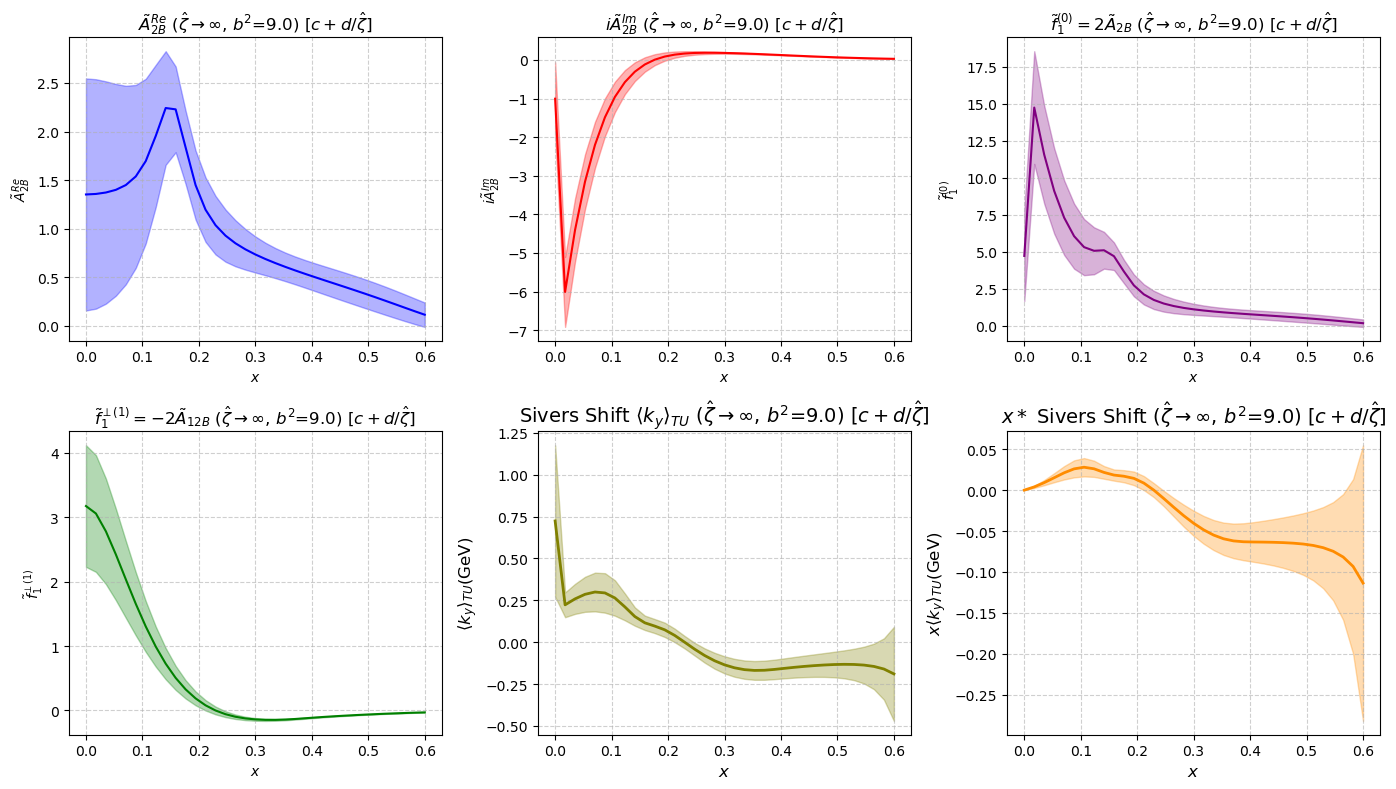

In [6]:
# ---------------------------------------------------------
# Example Execution Call
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [ -2, -3, -4]

    # Run the dedicated Sivers extrapolation
    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=35)

x      | Sivers shift (1/z=0 limit) | ReA2B: chi2/dof | ImA2B: chi2/dof | ReA12B: chi2/dof
-------------------------------------------------------


  0%|          | 0/35 [00:00<?, ?it/s]

 0.00  |  0.53(18)       |  0.54(85)       |  0.72(98)       |  0.18(49)
 0.02  |  0.204(47)       |  0.56(86)       |  0.8(11)       |  0.17(47)
 0.04  |  0.222(51)       |  0.61(90)       |  1.4(14)       |  0.13(42)
 0.05  |  0.233(53)       |  0.69(96)       |  2.0(16)       |  0.09(34)
 0.07  |  0.237(54)       |  0.8(10)       |  2.6(19)       |  0.04(24)
 0.09  |  0.233(52)       |  1.0(12)       |  3.2(21)       |  0.01(14)
 0.11  |  0.218(47)       |  1.3(13)       |  3.9(23)       |  3(175)e-4
 0.12  |  0.194(40)       |  1.7(15)       |  4.6(25)       |  0.01(12)
 0.14  |  0.164(31)       |  2.0(16)       |  5.2(26)       |  0.05(26)
 0.16  |  0.141(25)       |  1.6(15)       |  5.8(28)       |  0.13(42)
 0.18  |  0.131(22)       |  0.8(11)       |  6.2(29)       |  0.25(58)
 0.19  |  0.120(21)       |  0.31(65)       |  6.5(30)       |  0.43(76)
 0.21  |  0.106(19)       |  0.09(35)       |  6.7(30)       |  0.67(94)
 0.23  |  0.090(16)       |  0.02(15)       |  6.7(30)   

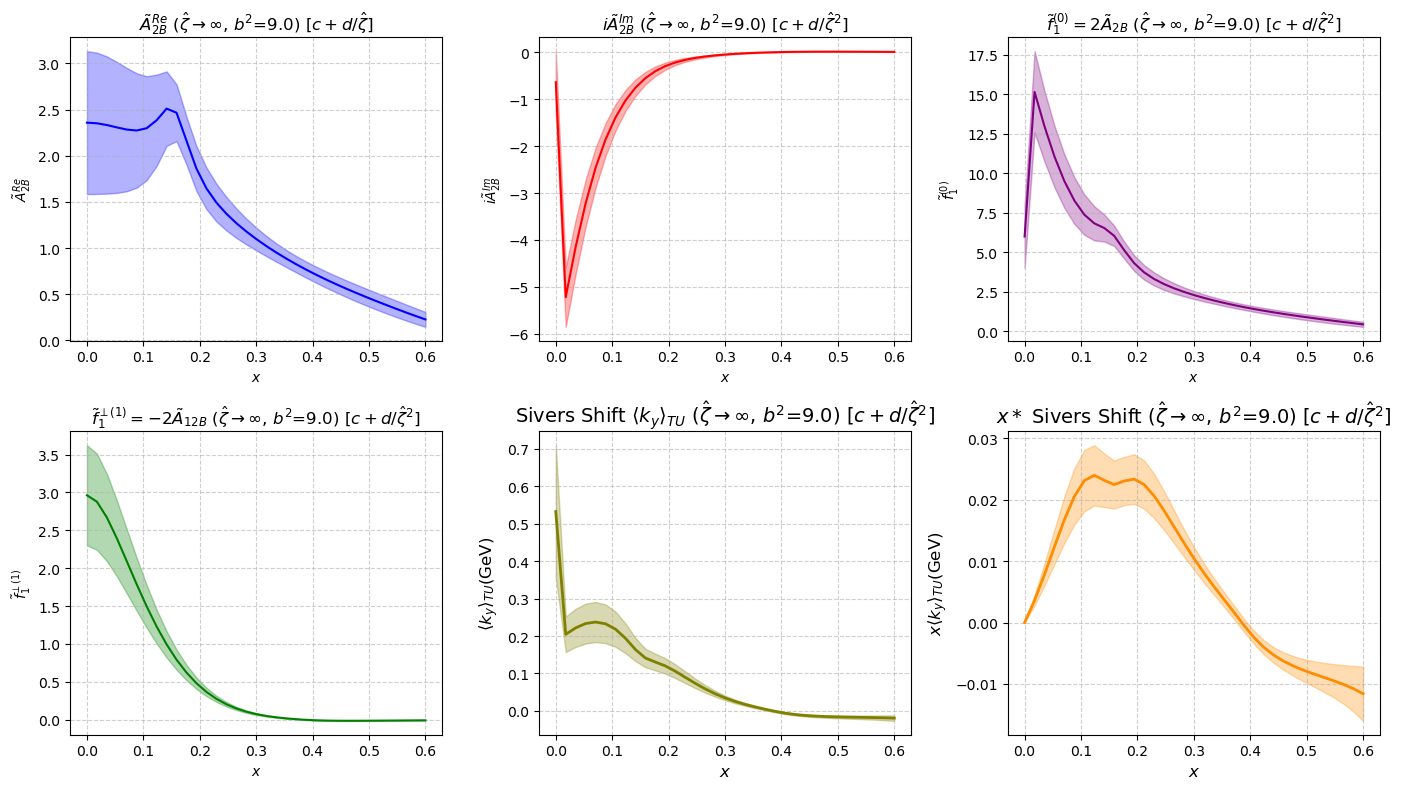

In [3]:
# ---------------------------------------------------------
# Example Execution Call
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [ -2, -3, -4]

    # Run the dedicated Sivers extrapolation
    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=35)

x      | Sivers shift (1/z=0 limit) | ReA2B: chi2/dof | ImA2B: chi2/dof | ReA12B: chi2/dof
-------------------------------------------------------


  0%|          | 0/35 [00:00<?, ?it/s]

 0.00  |  0.398(56)       |  1.9(14)       |  1.0(10)       |  0.16(40)
 0.21  |  0.1375(97)       |  4.3(21)       |  41.2(64)       |  17.8(42)
 0.41  |  0.0254(22)       |  2.3(15)       |  74.2(86)       |  144(12)
 0.62  |  -0.0058(15)       |  1.7(13)       |  86.7(93)       |  30.9(56)
 0.70  |  -0.0133(54)       |  2.1(15)       |  72.6(85)       |  11.4(34)


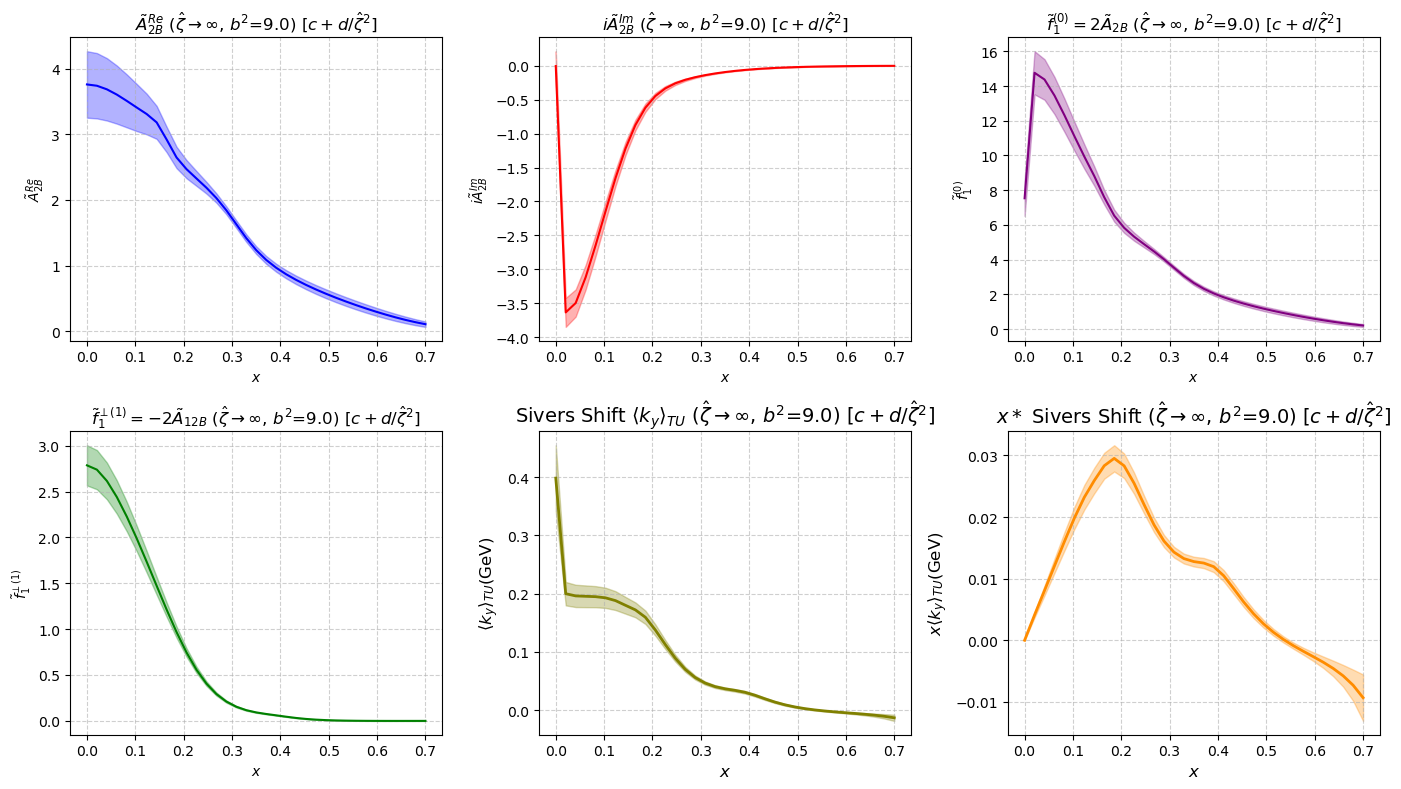

In [14]:
# ---------------------------------------------------------
# Example Execution Call
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-1, -2, -3, -4]

    # Run the dedicated Sivers extrapolation
    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=35)

x      | Sivers shift (1/z=0 limit) | ReA2B: chi2/dof | ImA2B: chi2/dof | ReA12B: chi2/dof
-------------------------------------------------------


  0%|          | 0/35 [00:00<?, ?it/s]

 0.00  |  0.381(53)       |  1.7(15)       |  0.62(91)       |  3(189)e-4
 0.02  |  0.195(20)       |  1.7(15)       |  2.4(18)       |  0.002(57)
 0.04  |  0.190(19)       |  1.8(16)       |  1.1(12)       |  0.02(16)
 0.05  |  0.188(18)       |  1.9(16)       |  0.30(63)       |  0.07(31)
 0.07  |  0.187(18)       |  2.0(16)       |  0.001(41)       |  0.20(51)
 0.09  |  0.186(17)       |  2.2(17)       |  0.26(59)       |  0.44(76)
 0.11  |  0.185(16)       |  2.4(18)       |  1.2(13)       |  0.9(11)
 0.12  |  0.182(16)       |  2.7(19)       |  2.9(20)       |  1.5(14)
 0.14  |  0.179(15)       |  3.0(20)       |  5.5(27)       |  2.6(19)
 0.16  |  0.174(13)       |  3.4(21)       |  9.0(35)       |  4.2(24)
 0.18  |  0.167(12)       |  3.9(23)       |  13.3(42)       |  6.5(29)
 0.19  |  0.159(11)       |  4.6(25)       |  18.4(50)       |  9.7(36)
 0.21  |  0.1482(96)       |  5.4(27)       |  24.1(57)       |  14.2(43)
 0.23  |  0.1355(83)       |  6.5(29)       |  30.1(63)    

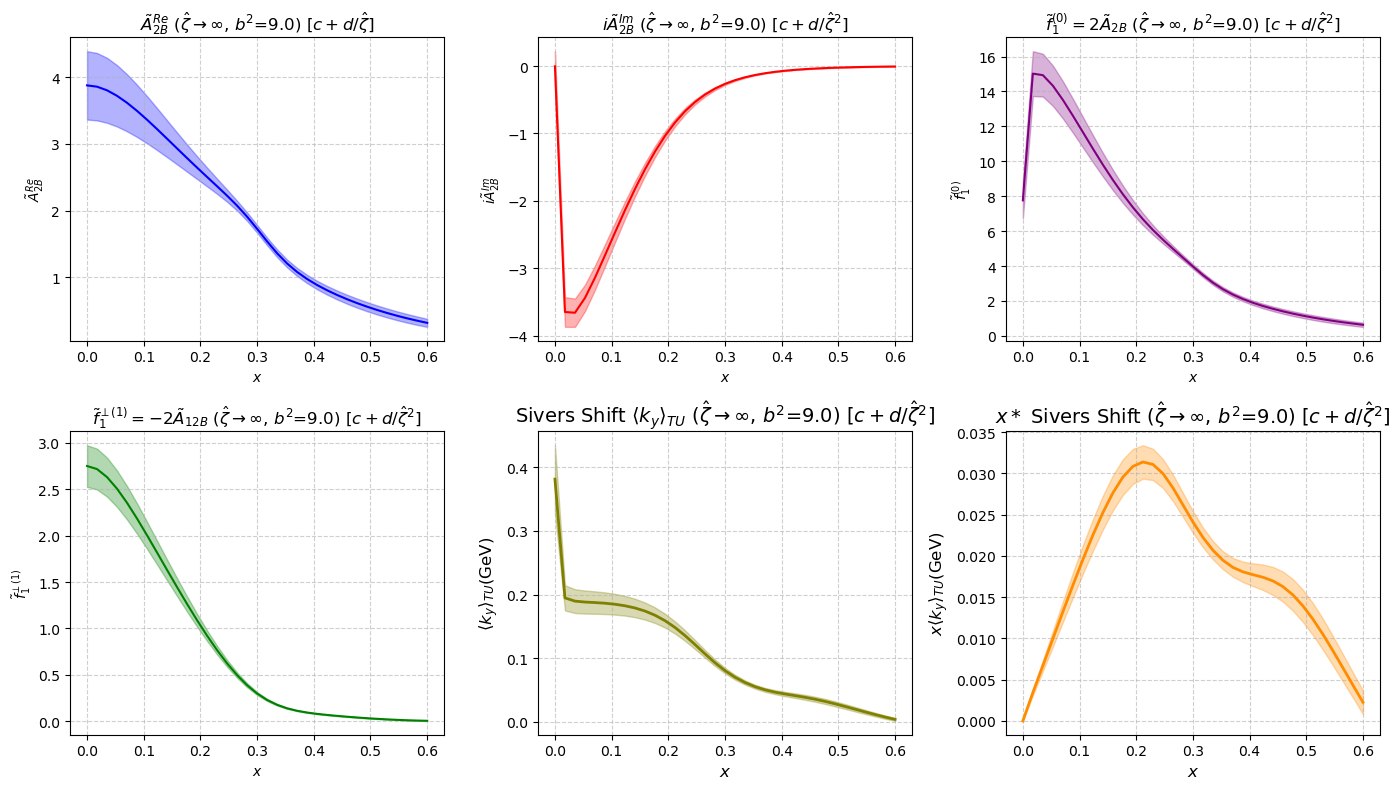

In [7]:
# ---------------------------------------------------------
# Example Execution Call
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-1, -2, -3]

    # Run the dedicated Sivers extrapolation
    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=35)

x      | Sivers shift (1/z=0 limit) | ReA2B: chi2/dof | ImA2B: chi2/dof | ReA12B: chi2/dof
-------------------------------------------------------


  0%|          | 0/30 [00:00<?, ?it/s]

 0.00  |  0.422(67)       |  2.3(15)       |  1.0(10)       |  0.12(35)
 0.21  |  0.118(10)       |  5.8(24)       |  41.3(64)       |  16.7(41)
 0.41  |  -0.0340(44)       |  1.9(14)       |  57.2(76)       |  44.5(67)
 0.60  |  -0.104(43)       |  1.2(11)       |  40.3(63)       |  16.5(41)


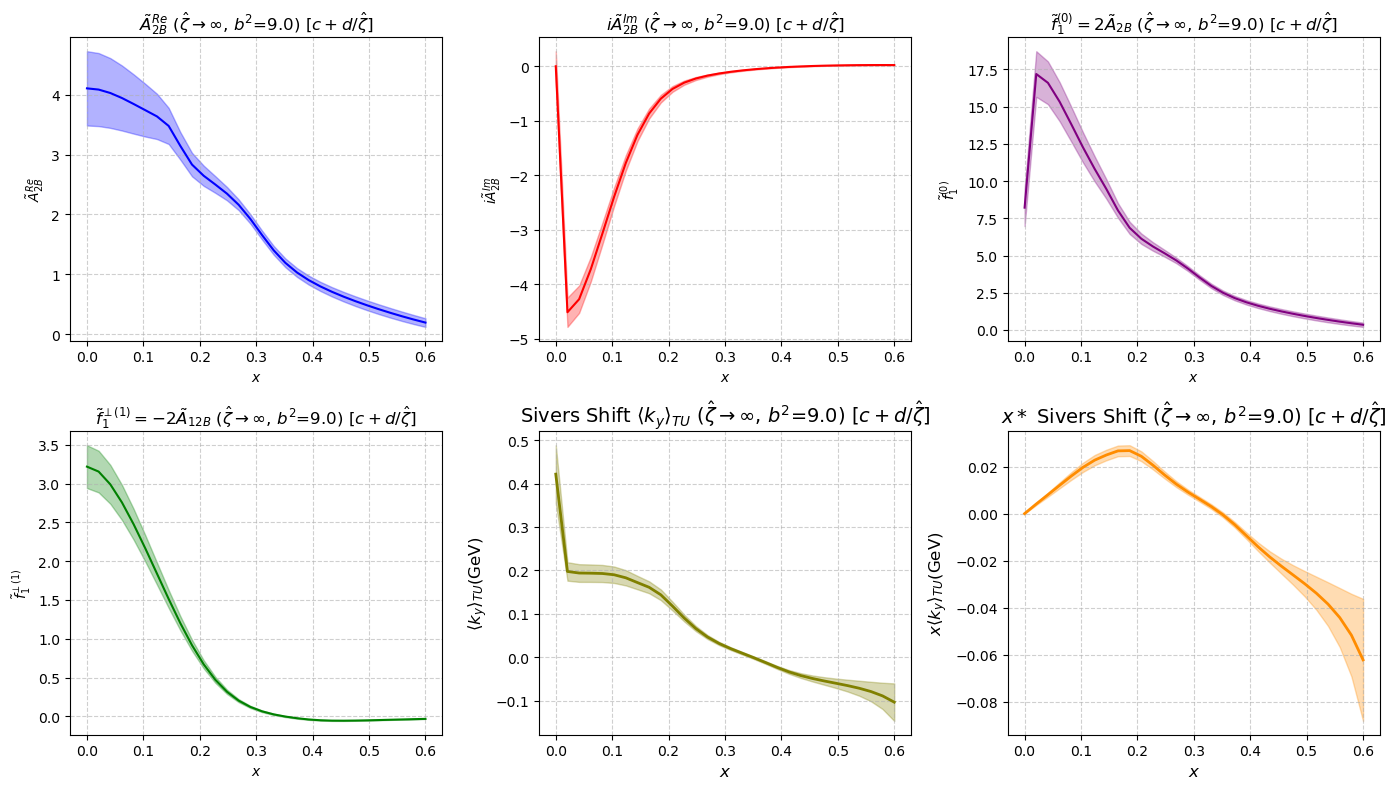

In [19]:
# ---------------------------------------------------------
# Example Execution Call
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-1, -2, -3, -4]

    # Run the dedicated Sivers extrapolation
    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=30)

x      | Sivers shift (1/z=0 limit) | ReA2B: chi2/dof | ImA2B: chi2/dof | ReA12B: chi2/dof
-------------------------------------------------------


  0%|          | 0/30 [00:00<?, ?it/s]

 0.00  |  0.403(62)       |  2.3(18)       |  0.62(91)       |  0.04(24)
 0.21  |  0.136(11)       |  6.8(30)       |  26.2(59)       |  12.7(41)
 0.41  |  -0.0201(47)       |  2.2(17)       |  70.0(97)       |  51.9(83)
 0.60  |  -0.145(55)       |  0.01(14)       |  45.2(78)       |  0.39(72)


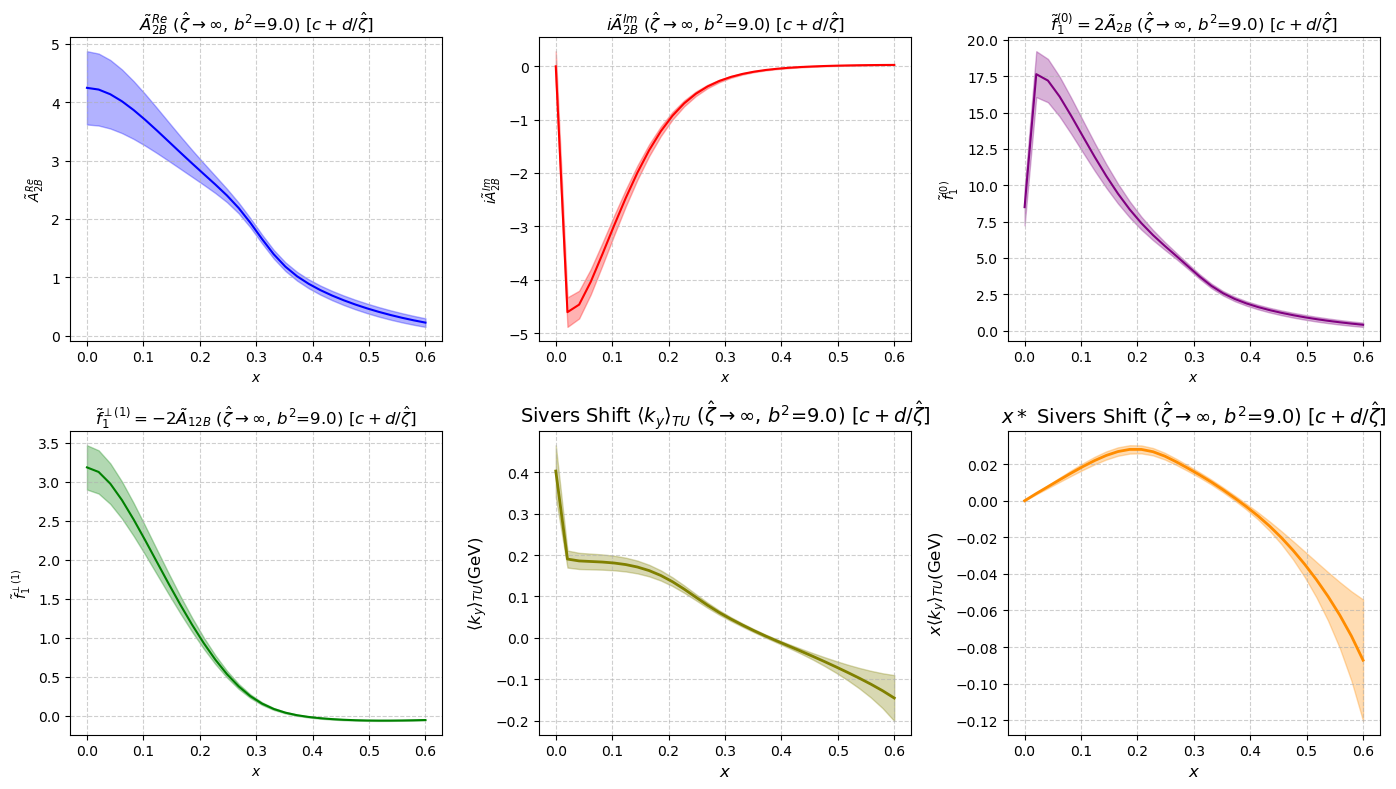

In [21]:
# ---------------------------------------------------------
# Example Execution Call
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-1, -2, -3]

    # Run the dedicated Sivers extrapolation
    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=30)

x      | Sivers shift (1/z=0 limit) | ReA2B: chi2/dof | ImA2B: chi2/dof | ReA12B: chi2/dof
-------------------------------------------------------


  0%|          | 0/35 [00:00<?, ?it/s]

 0.00  |  0.422(67)       |  2.3(15)       |  1.0(10)       |  0.12(35)
 0.21  |  0.119(10)       |  5.7(24)       |  41.1(64)       |  16.4(40)
 0.41  |  -0.0331(43)       |  2.0(14)       |  57.2(76)       |  45.3(67)
 0.62  |  -0.122(63)       |  1.3(11)       |  39.6(63)       |  20.3(45)
 0.70  |  -1(13905)       |  1.4(12)       |  51.5(72)       |  51.4(72)


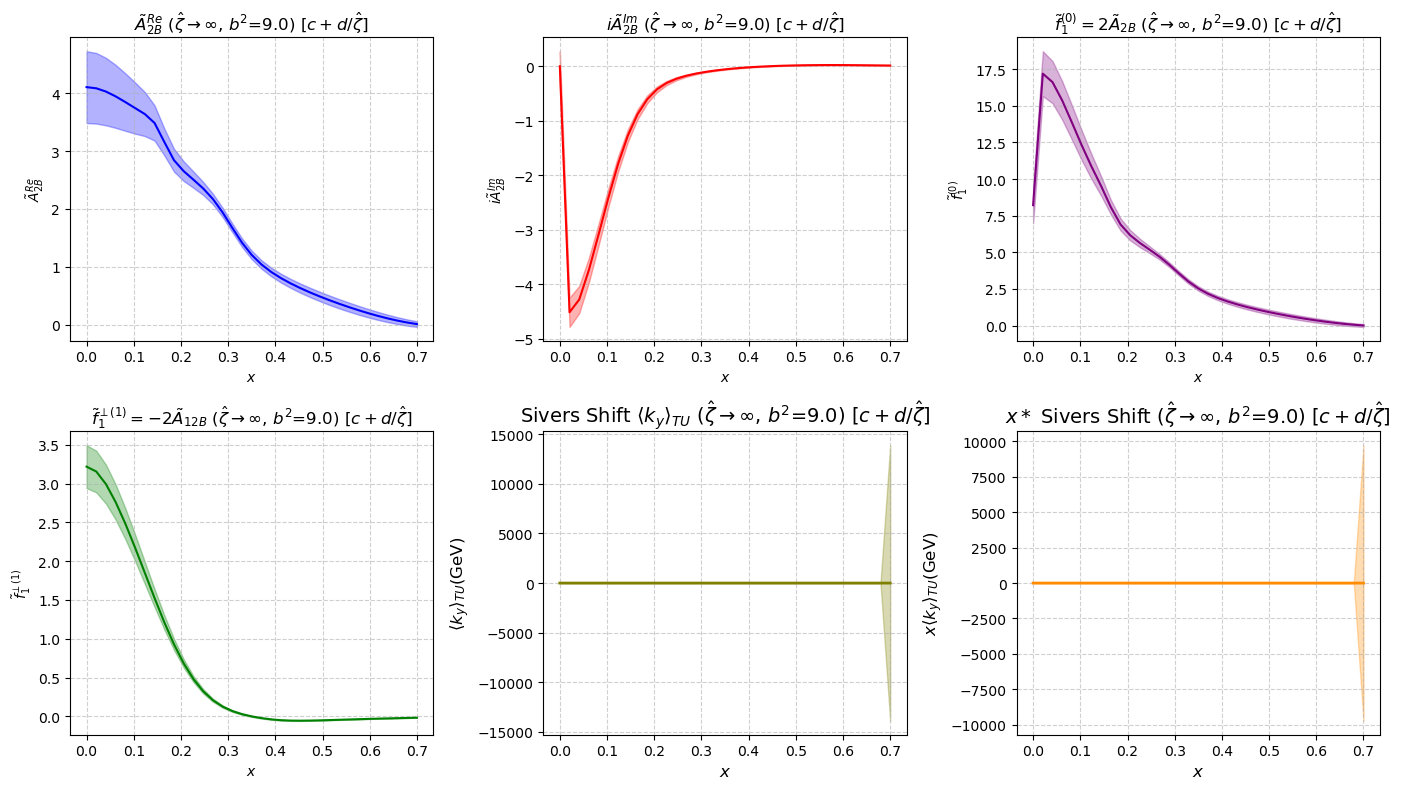

In [17]:
# ---------------------------------------------------------
# Example Execution Call
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-1, -2, -3, -4]

    # Run the dedicated Sivers extrapolation
    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=35)

x      | Sivers shift (1/z=0 limit) | ReA2B: chi2/dof | ImA2B: chi2/dof | ReA12B: chi2/dof
-------------------------------------------------------


  0%|          | 0/10 [00:00<?, ?it/s]

 0.00  |  0.398(56)       |  1.9(14)       |  1.0(10)       |  0.16(40)
 0.08  |  0.195(18)       |  2.2(15)       |  3.3(18)       |  0.22(46)
 0.16  |  0.175(13)       |  2.7(16)       |  24.2(49)       |  5.2(23)
 0.23  |  0.1043(70)       |  5.8(24)       |  48.0(69)       |  29.1(54)
 0.31  |  0.0455(27)       |  8.0(28)       |  60.5(78)       |  73.9(86)
 0.39  |  0.0310(23)       |  3.2(18)       |  71.1(84)       |  134(12)
 0.47  |  0.0105(16)       |  1.4(12)       |  81.2(90)       |  124(11)
 0.54  |  -6.1(91)e-4       |  1.3(12)       |  87.9(94)       |  67.7(82)
 0.62  |  -0.0061(16)       |  1.8(13)       |  86.3(93)       |  29.3(54)
 0.70  |  -0.0133(54)       |  2.1(15)       |  72.6(85)       |  11.4(34)


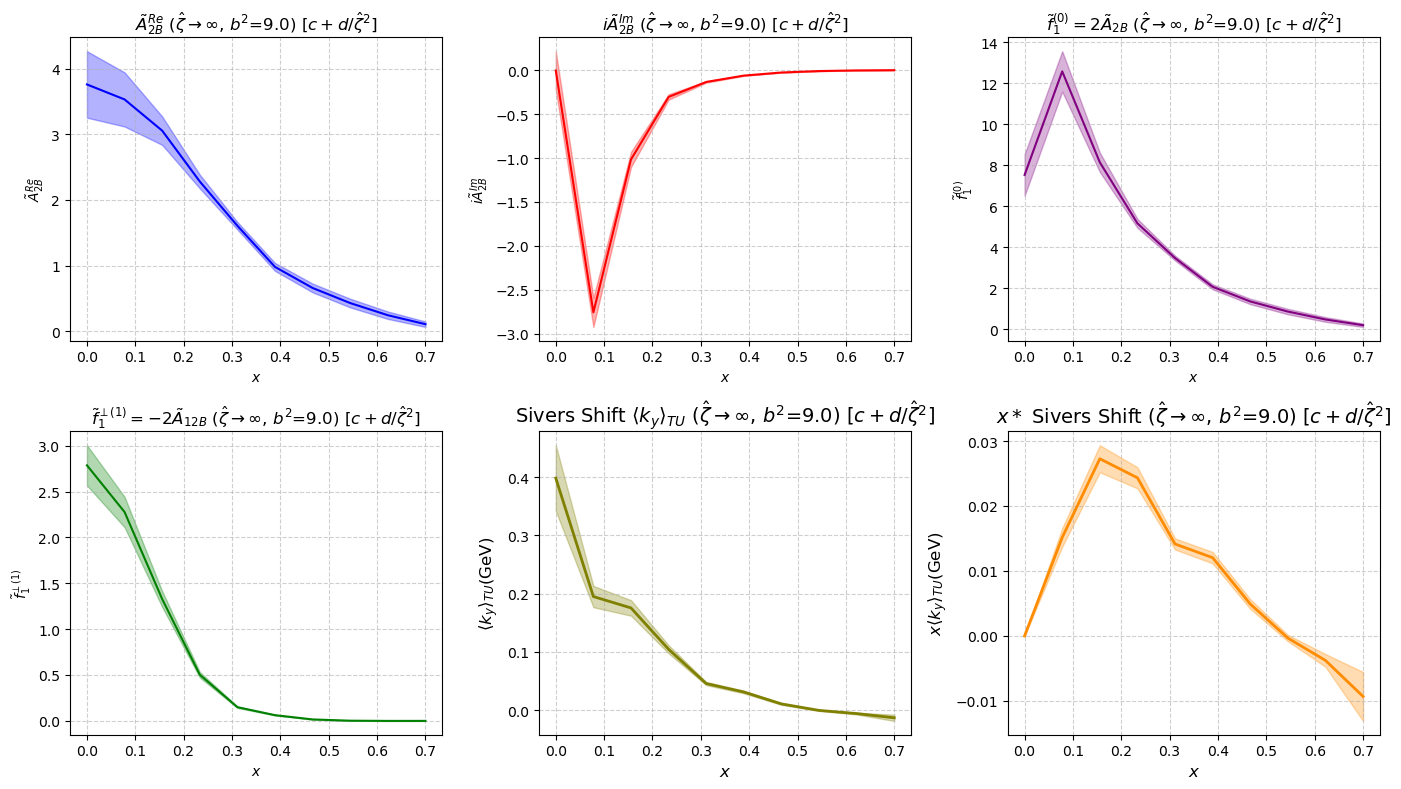

In [12]:
# ---------------------------------------------------------
# Example Execution Call
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-1, -2, -3, -4]

    # Run the dedicated Sivers extrapolation
    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=10)

x      | Sivers shift (1/z=0 limit) | chi2/dof
-------------------------------------------------------


  0%|          | 0/10 [00:00<?, ?it/s]

 0.00  |  0.422(67)       
 0.11  |  0.188(19)       
 0.22  |  0.0973(84)       
 0.33  |  0.0078(30)       
 0.44  |  -0.0457(62)       
 0.56  |  -0.078(22)       
 0.67  |  -0.28(36)       
 0.78  |  0.108(64)       
 0.89  |  0.0257(59)       
 1.00  |  0.0049(10)       


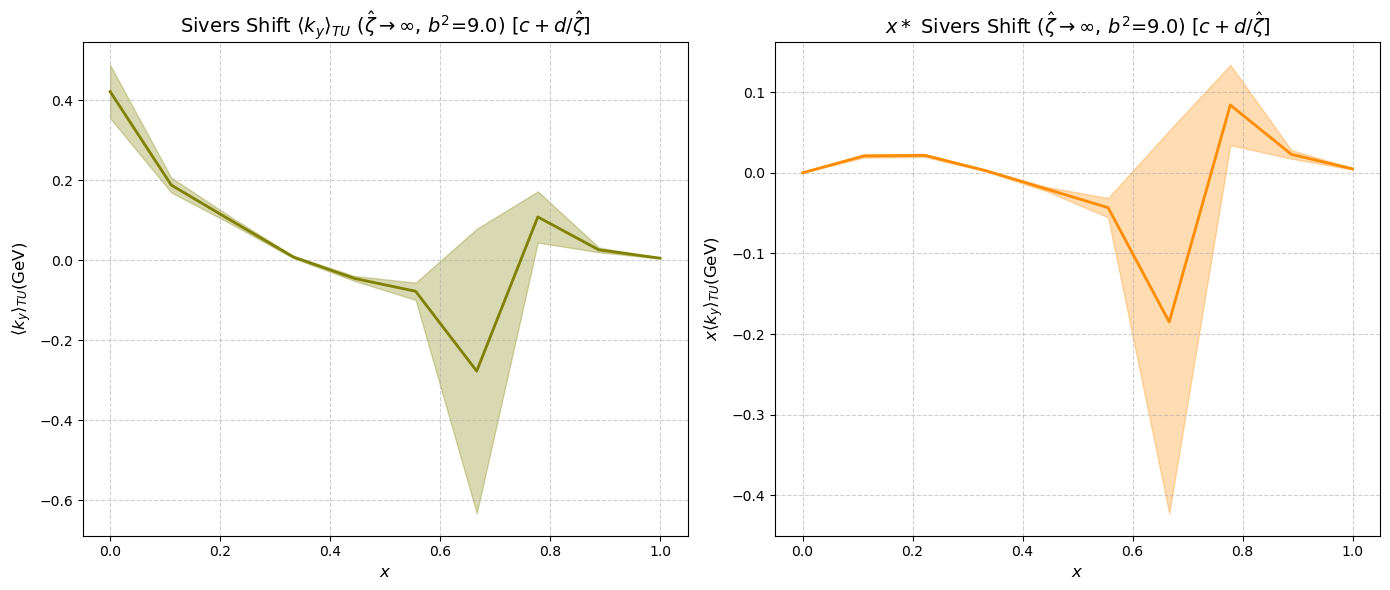

In [2]:
# ---------------------------------------------------------
# Example Execution Call
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-1, -2, -3, -4]

    # Run the dedicated Sivers extrapolation
    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=10)


[1] Loading Data and Computing Finite Momentum Sivers Ratio for b^2 = 9.0...


Evaluating PL sets:   0%|          | 0/4 [00:00<?, ?it/s]


[2] Performing Extrapolation to 1/zeta_hat -> 0 and Applying User Jackknife...
x      | Sivers (1/z=0 limit)      | chi2/dof
-------------------------------------------------------


Extrapolating 1/zeta_hat -> 0:   0%|          | 0/10 [00:00<?, ?it/s]

 0.00  |    0.1465 +/- 0.1327         |  1.29
 1.00  |   -0.0192 +/- 0.0156         |  0.45

[3] Generating Extrapolated Sivers Plots...


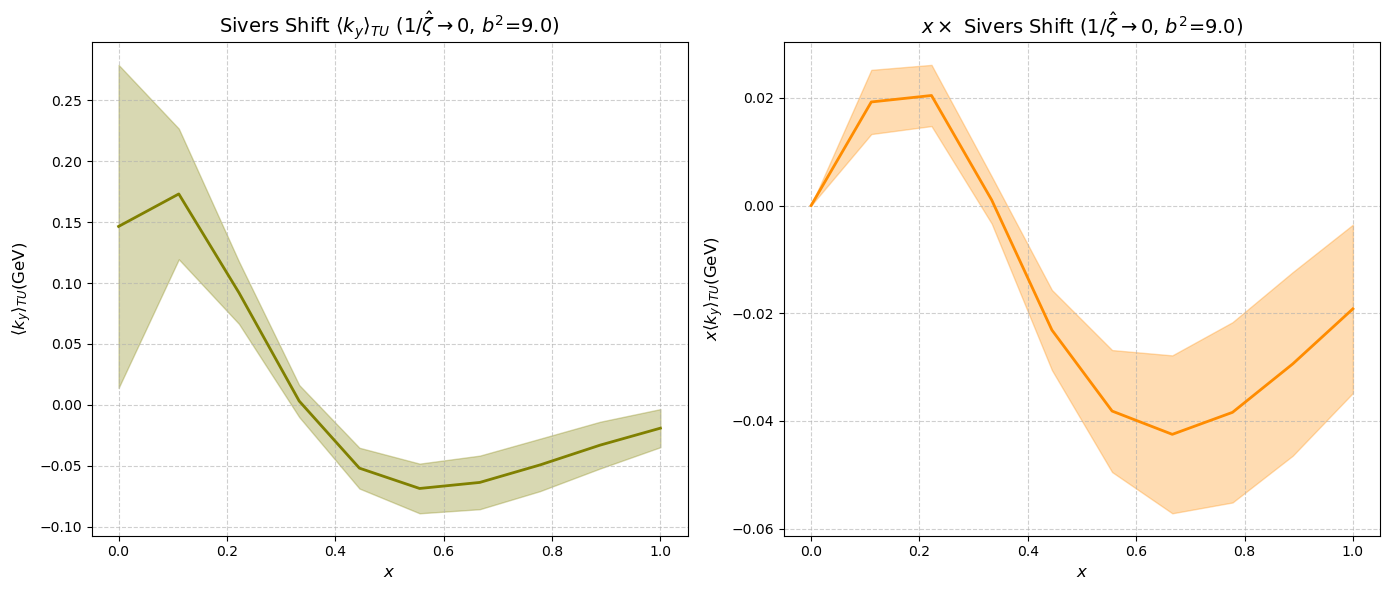

In [21]:
# ---------------------------------------------------------
# Example Execution Call
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-1, -2, -3, -4]

    # Run the dedicated Sivers extrapolation
    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=10)


[1] Loading Data and Computing Finite Momentum Sivers Ratio for b^2 = 9.0...


Evaluating PL sets:   0%|          | 0/4 [00:00<?, ?it/s]


[2] Performing Extrapolation to 1/zeta_hat -> 0 and Applying User Jackknife...
x      | Sivers (1/z=0 limit)      | chi2/dof
-------------------------------------------------------


Extrapolating 1/zeta_hat -> 0:   0%|          | 0/10 [00:00<?, ?it/s]

 0.00  |    0.2792 +/- 0.0418         |  1.57
 1.00  |   -0.0022 +/- 0.0008         |  0.74

[3] Generating Extrapolated Sivers Plots...


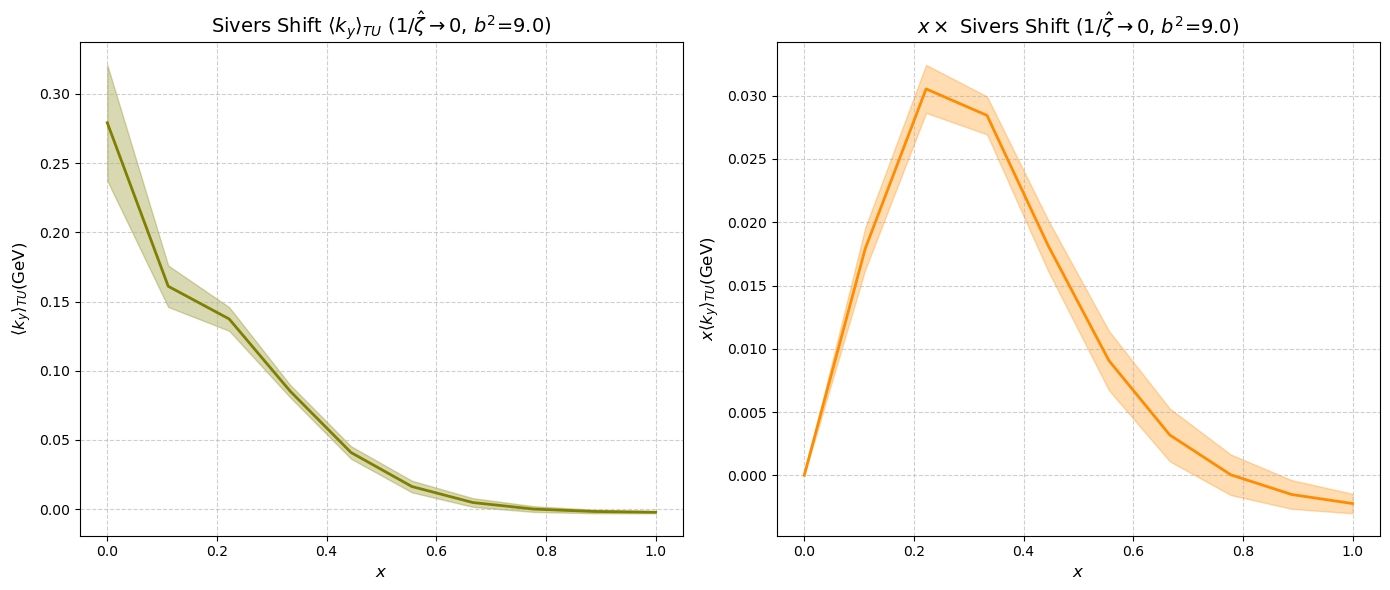

In [25]:
# ---------------------------------------------------------
# Example Execution Call
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-1, -2, -3, -4]

    # Run the dedicated Sivers extrapolation
    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=10)


[1] Loading Data and Computing Finite Momentum Sivers Ratio for b^2 = 9.0...


Evaluating PL sets:   0%|          | 0/4 [00:00<?, ?it/s]


[2] Performing Extrapolation to 1/zeta_hat -> 0 and Applying User Jackknife...
x      | Sivers (1/z=0 limit)      | chi2/dof
-------------------------------------------------------


Extrapolating 1/zeta_hat -> 0:   0%|          | 0/10 [00:00<?, ?it/s]

 0.00  |    0.2792 +/- 0.0418         |  1.57
 1.00  |   -0.0022 +/- 0.0008         |  0.74

[3] Generating Extrapolated Sivers Plots...


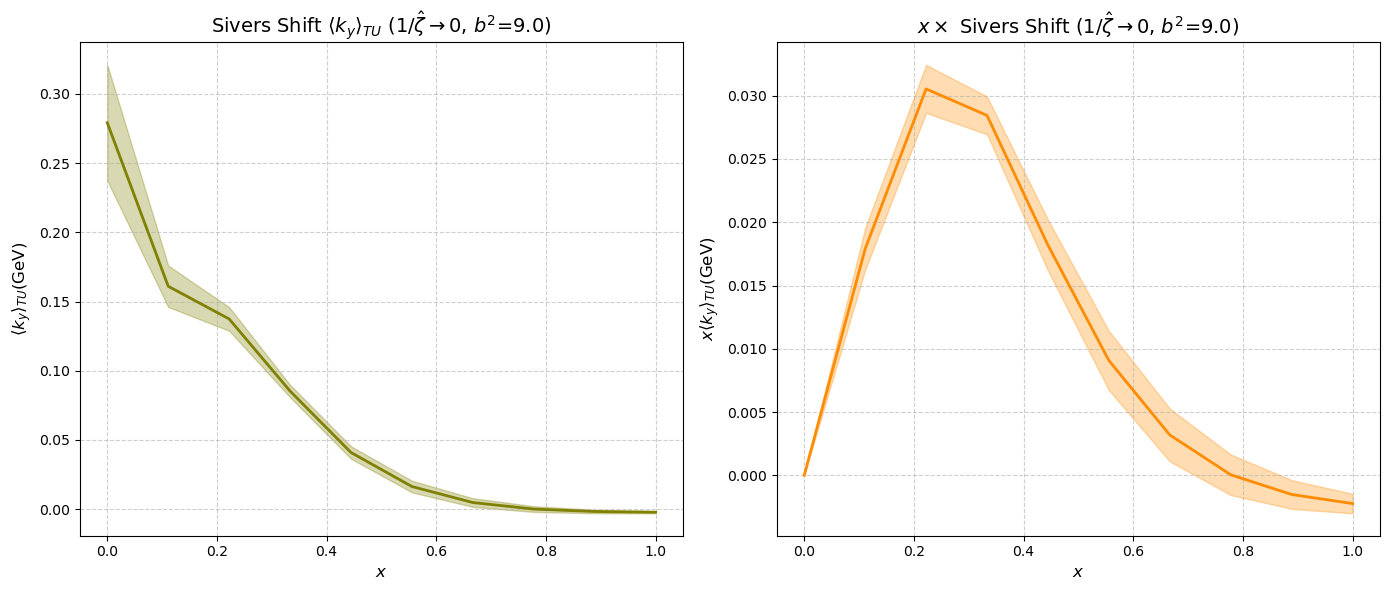

In [14]:
# ---------------------------------------------------------
# Example Execution Call
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-1, -2, -3, -4]

    # Run the dedicated Sivers extrapolation
    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=10)


[1] Loading Data and Computing Finite Momentum Sivers Ratio for b^2 = 9.0...


Evaluating PL sets:   0%|          | 0/3 [00:00<?, ?it/s]


[2] Performing Extrapolation to 1/zeta_hat -> 0 and Applying User Jackknife...
x      | Sivers (1/z=0 limit)      | chi2/dof
-------------------------------------------------------


Extrapolating 1/zeta_hat -> 0:   0%|          | 0/10 [00:00<?, ?it/s]

 0.00  |    0.2238 +/- 0.0836         |  1.89
 1.00  |   -0.0090 +/- 0.0047         |  0.30

[3] Generating Extrapolated Sivers Plots...


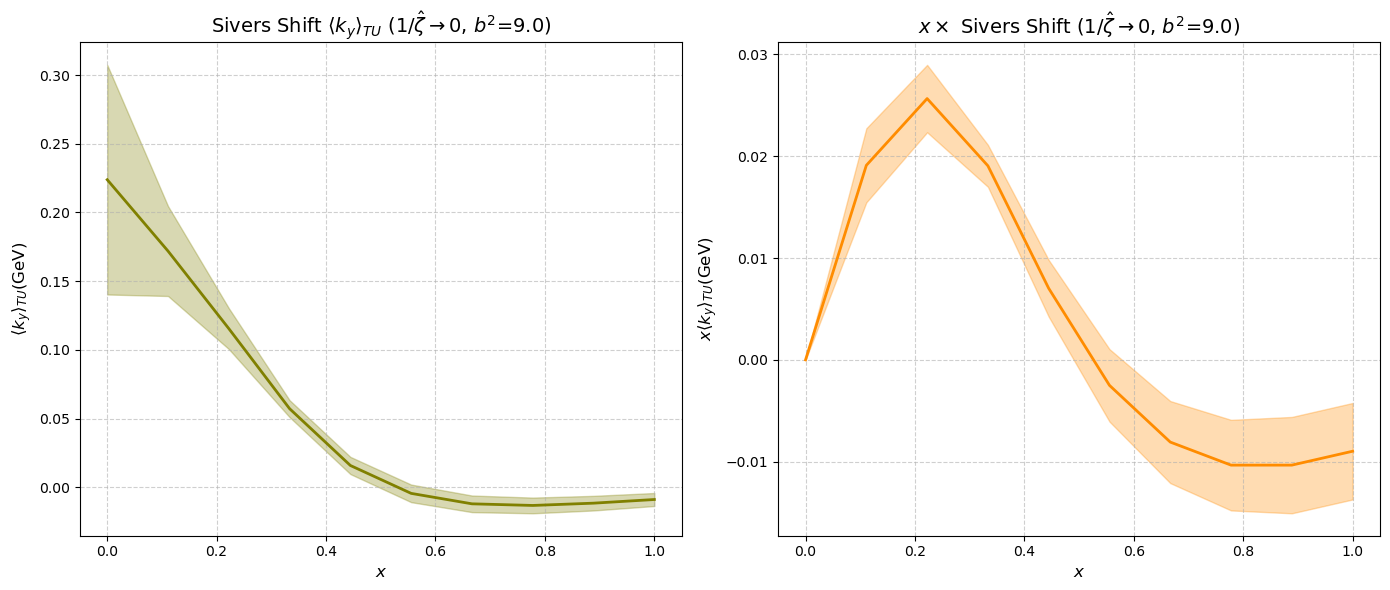

In [8]:
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-2, -3, -4]

    # Run the dedicated Sivers extrapolation
    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=10)


[1] Loading Data and Computing Finite Momentum Sivers Ratio for b^2 = 9.0...


Evaluating PL sets:   0%|          | 0/3 [00:00<?, ?it/s]


[2] Performing Extrapolation to 1/zeta_hat -> 0 and Applying User Jackknife...
x      | Sivers (1/z=0 limit)      | chi2/dof
-------------------------------------------------------


Extrapolating 1/zeta_hat -> 0:   0%|          | 0/10 [00:00<?, ?it/s]

 0.00  |    0.3207 +/- 0.0457         |  0.41
 1.00  |   -0.0022 +/- 0.0008         |  0.98

[3] Generating Extrapolated Sivers Plots...


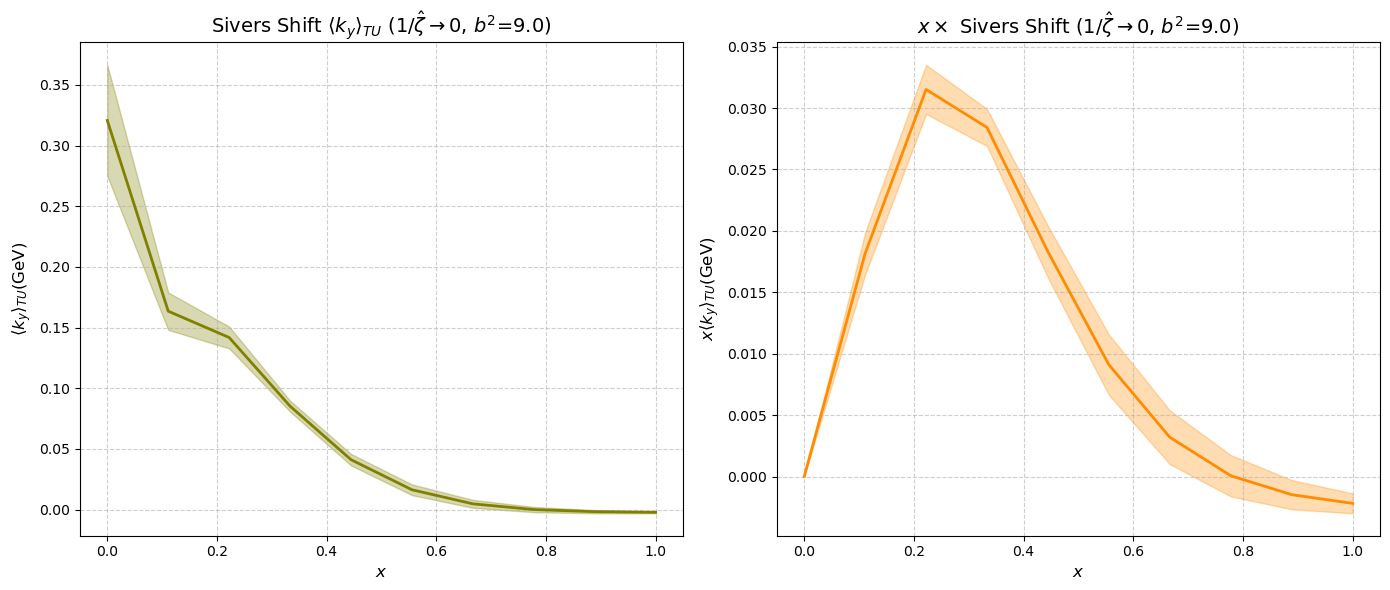

In [9]:
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-1, -2, -3]

    # Run the dedicated Sivers extrapolation
    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=10)


[1] Loading Data and Computing Finite Momentum Sivers Ratio for b^2 = 9.0...


Evaluating PL sets:   0%|          | 0/2 [00:00<?, ?it/s]


[2] Performing Extrapolation to 1/zeta_hat -> 0 and Applying User Jackknife...
x      | Sivers (1/z=0 limit)      | chi2/dof
-------------------------------------------------------


Extrapolating 1/zeta_hat -> 0:   0%|          | 0/10 [00:00<?, ?it/s]

 0.00  |    0.4532 +/- 0.1275         |  0.00
 1.00  |   -0.0110 +/- 0.0052         |  0.00

[3] Generating Extrapolated Sivers Plots...


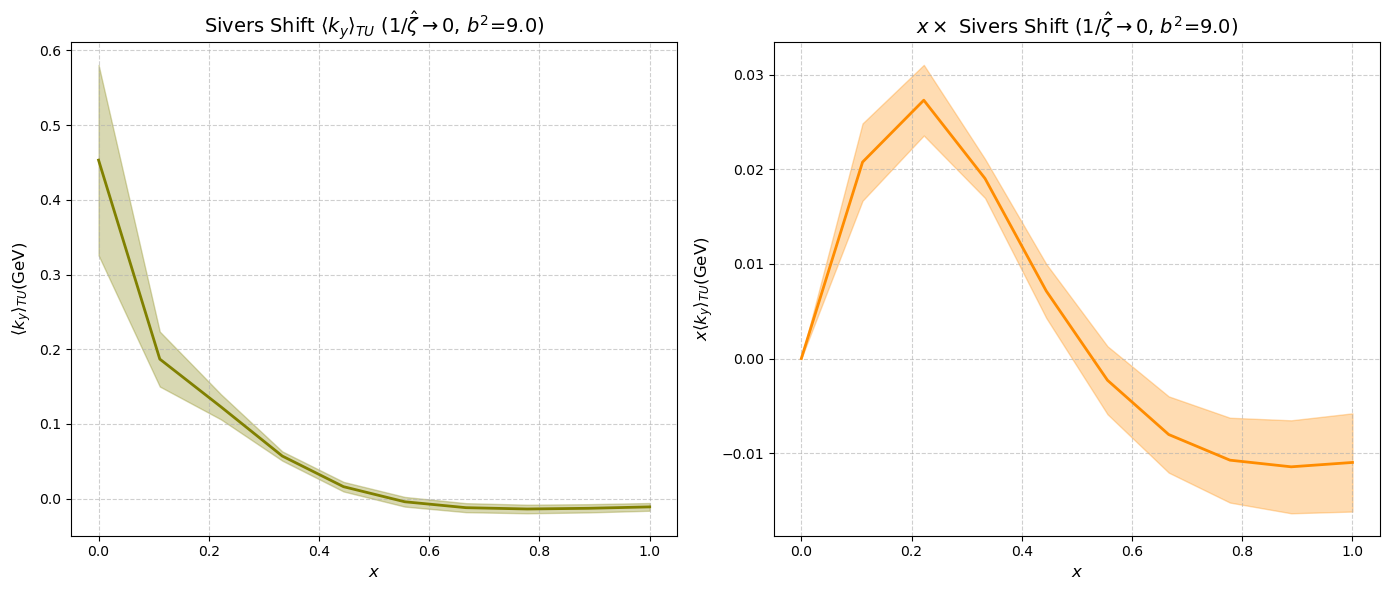

In [10]:
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-2, -3]

    # Run the dedicated Sivers extrapolation
    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=10)


[1] Loading HDF5 data and evaluating over x for fixed b^2 = 9.0...


Evaluating PL sets:   0%|          | 0/4 [00:00<?, ?it/s]


[2] Performing 1/PL -> 0 Linear Extrapolation (Jackknife by Jackknife)...
------------------------------------------------------------------------------------------
Observable | x     | c0 (1/PL=0 limit)    | c1 (Slope)           | chi2/dof
------------------------------------------------------------------------------------------


Extrapolating slices:   0%|          | 0/10 [00:00<?, ?it/s]

ReA2B      |  0.00 |   4.6511 +/- 0.8023   |   2.9236 +/- 0.7991   | 2.67
ImA2B      |  0.00 |  -0.0021 +/- 0.0091   |   0.0025 +/- 0.0109   | 1.03
ReA12B     |  0.00 |  -1.9511 +/- 0.1846   |  -1.2676 +/- 0.1789   | 0.15
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
ReA2B      |  1.00 |  -0.1062 +/- 0.0074   |  -0.4218 +/- 0.0225   | 3.96
ImA2B      |  1.00 |   0.0003 +/- 0.0000   |   0.0013 +/- 0.0002   | 138.32
ReA12B     |  1.00 |   0.0002 +/- 0.0000   |   0.0007 +/- 0.0002   | 163.21

[3] Calculating Extrapolated Observables and Derived Quantities...
[4] Generating plots...


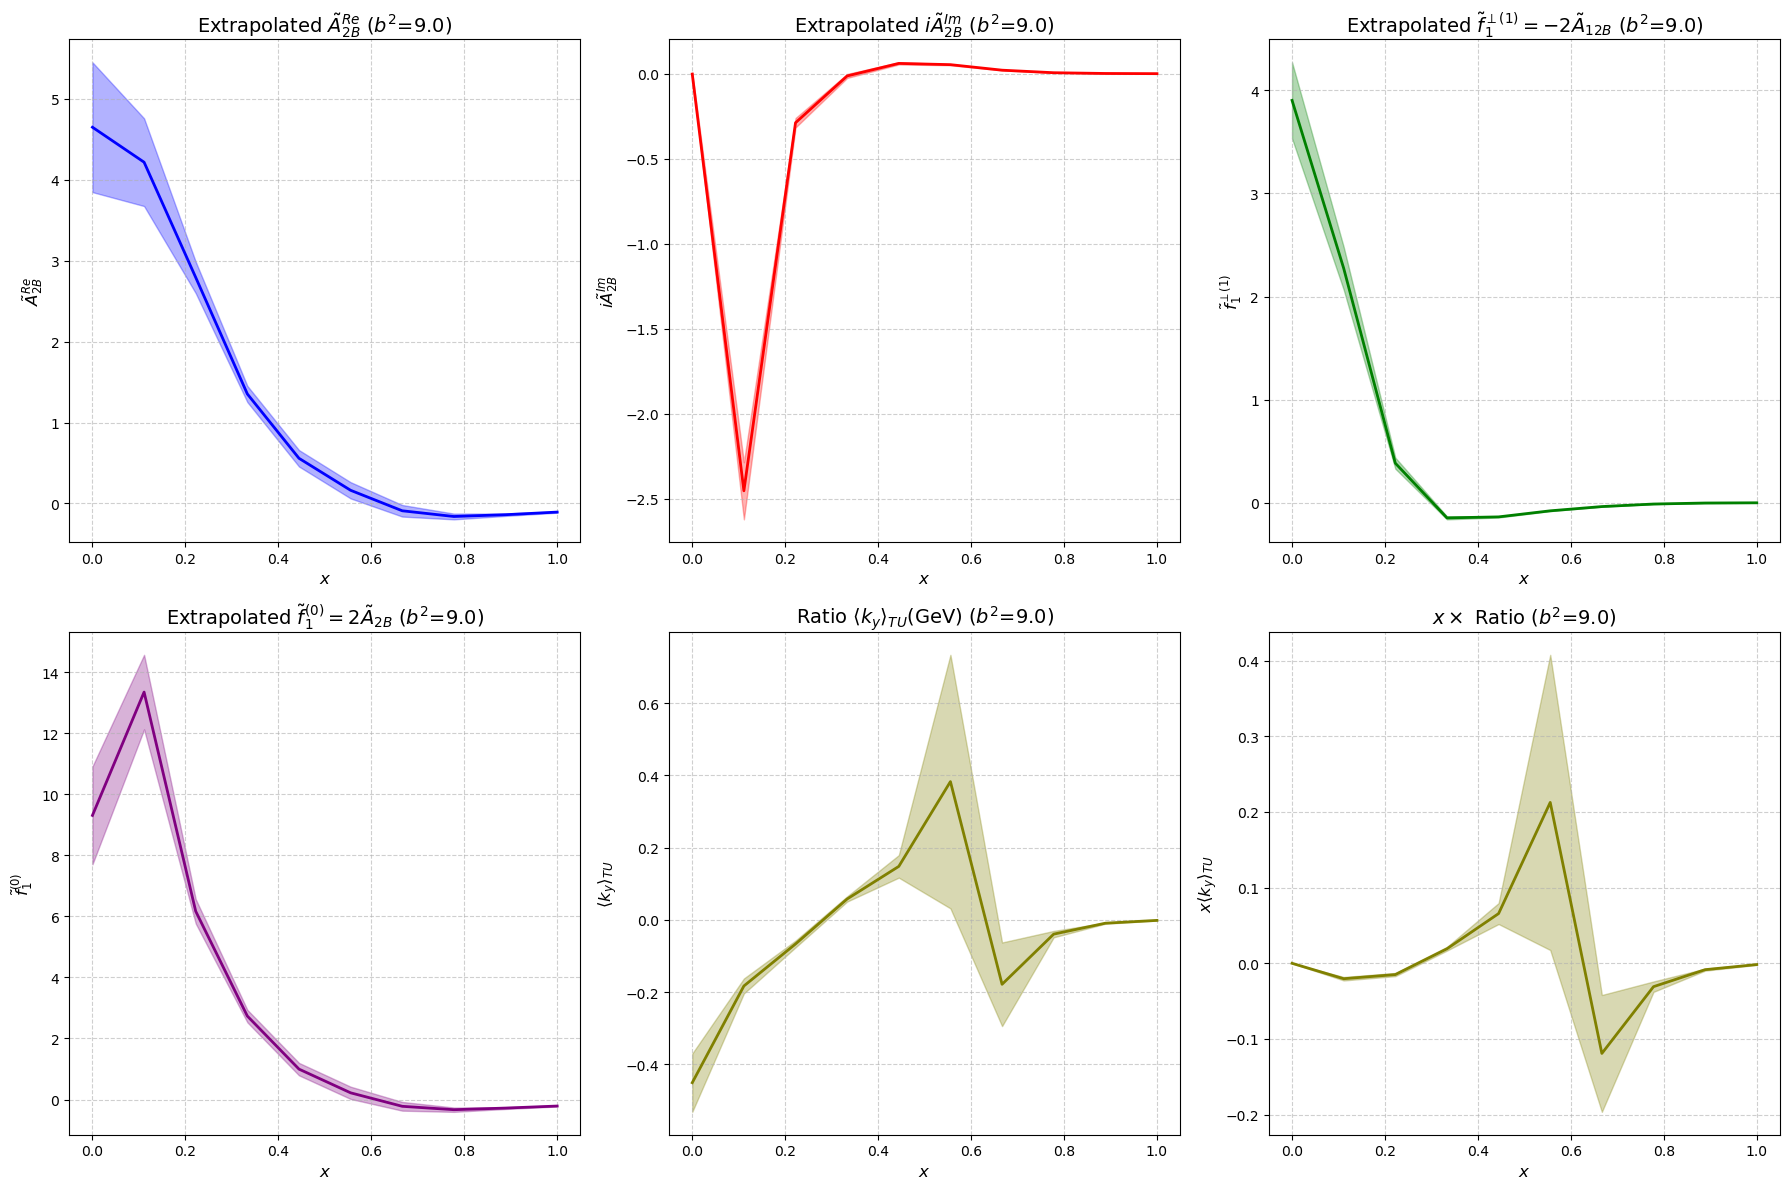

In [14]:
import h5py
import numpy as np
import math
import gvar as gv
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma

# ---------------------------------------------------------
# 1. Jackknife Statistics Helpers
# ---------------------------------------------------------
def calc_jk_stats(jk_array):
    """ Calculate mean and jackknife error of an array of samples. """
    N = len(jk_array)
    mean = np.mean(jk_array)
    err = np.sqrt(((N - 1) / N) * np.sum((jk_array - mean)**2))
    return mean, err

def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        # Load the jackknifed parameter samples
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            fitted_params[key] = param_group[key][:]
        # Load the chi-square per dof array
        chi2_dof_list = f["chi2_dof"][:]
    return fitted_params, chi2_dof_list

# ---------------------------------------------------------
# 2. Extrapolation Routine using LSQFIT
# ---------------------------------------------------------
def fit_1_over_PL_lsqfit(inv_PL_vals, y_jk_samples):
    """
    Fits y = c0 + c1 * (1/PL) separately for every jackknife sample.
    inv_PL_vals: 1D array of length N_PL
    y_jk_samples: 2D array of shape (N_PL, N_JK)
    """
    N_PL, N_JK = y_jk_samples.shape

    # 1. Evaluate Jackknife Mean and Covariance
    mean_y = np.mean(y_jk_samples, axis=1)
    cov_y = np.zeros((N_PL, N_PL))
    for i in range(N_PL):
        for j in range(N_PL):
            cov_y[i, j] = ((N_JK - 1) / N_JK) * np.sum(
                (y_jk_samples[i, :] - mean_y[i]) * (y_jk_samples[j, :] - mean_y[j])
            )

    # Create gvar for the central fit to get accurate chi2/dof
    try:
        y_gvar = gv.gvar(mean_y, cov_y)
    except Exception:
        # Fallback to diagonal errors if covariance matrix is numerically degenerate
        y_gvar = gv.gvar(mean_y, np.sqrt(np.diag(cov_y)))

    def fcn(x, p):
        return p['c0'] + p['c1'] * x

    # Loose prior so it behaves as an unconstrained standard fit
    prior = {'c0': gv.gvar(0, 1e5), 'c1': gv.gvar(0, 1e5)}

    # Fit the ensemble mean to extract chi2/dof
    fit_mean = lsqfit.nonlinear_fit(data=(inv_PL_vals, y_gvar), fcn=fcn, prior=prior)
    chi2_dof = fit_mean.chi2 / fit_mean.dof if fit_mean.dof > 0 else 0.0

    # 2. Fit every individual jackknife sample
    c0_jk = np.zeros(N_JK)
    c1_jk = np.zeros(N_JK)
    cov_y_eval = gv.evalcov(y_gvar)

    for k in range(N_JK):
        # We use the full ensemble covariance but shift the central values to the specific JK sample
        y_k_gvar = gv.gvar(y_jk_samples[:, k], cov_y_eval)
        fit_k = lsqfit.nonlinear_fit(data=(inv_PL_vals, y_k_gvar), fcn=fcn, prior=prior)
        c0_jk[k] = fit_k.pmean['c0']
        c1_jk[k] = fit_k.pmean['c1']

    # Calculate JK mean and error for fit parameters
    c0_mean, c0_err = calc_jk_stats(c0_jk)
    c1_mean, c1_err = calc_jk_stats(c1_jk)

    # Return the extrapolated sample array (c0_jk) to allow proper JK error propagation downstream
    return c0_jk, c0_mean, c0_err, c1_mean, c1_err, chi2_dof

# ---------------------------------------------------------
# 3. Main Logic
# ---------------------------------------------------------
def extrapolate_and_plot(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=10):
    
    x_vals = np.linspace(0, 1, num_points_x)
    MassN = 0.6228
    lata = 0.11403
    massterm = MassN * (197 * 0.001 / lata)
    
    # Calculate 1/PL and sort them
    inv_PL_vals = np.array([1.0 / pl for pl in PL_list])
    sort_idx = np.argsort(inv_PL_vals)
    inv_PL_vals = inv_PL_vals[sort_idx]
    sorted_PL_list = [PL_list[i] for i in sort_idx]
    N_PL = len(sorted_PL_list)

    print(f"\n[1] Loading HDF5 data and evaluating over x for fixed b^2 = {b2}...")
    
    # We need to discover N_JK from the first file
    init_filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{sorted_PL_list[0]}.h5"
    init_params, _ = load_params_from_h5(init_filename)
    N_JK = len(init_params['a_re'])

    # Pre-allocate evaluation arrays (N_PL, num_points_x, N_JK)
    re_all = np.zeros((N_PL, num_points_x, N_JK))
    im_all = np.zeros((N_PL, num_points_x, N_JK))
    reA12B_all = np.zeros((N_PL, num_points_x, N_JK))

    # Evaluate everything before fitting
    for i, pl in enumerate(tqdm(sorted_PL_list, desc="Evaluating PL sets")):
        filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{pl}.h5"
        fitted_params, _ = load_params_from_h5(filename)
        
        # Scaling parameters
        a_re, c_re, j_re, d_re = fitted_params['a_re'], fitted_params['c_re'] / (pl**2), fitted_params['j_re'], 1.0 + fitted_params['d_re'] * b2
        a_im, c_im, j_im, d_im = fitted_params['a_im'] / pl, fitted_params['c_im'] / (pl**2), fitted_params['j_im'], 1.0 + fitted_params['d_im'] * b2
        a_reA12B, c_reA12B, j_reA12B, d_reA12B = -fitted_params['a_reA12B'], fitted_params['c_reA12B'] / (pl**2), fitted_params['j_reA12B'], 1.0 + fitted_params['d_reA12B'] * b2

        for j, x in enumerate(x_vals):
            abs_x = max(np.abs(x), 1e-12)
            safe_x = x if x != 0 else 1e-12

            # ReA2B
            cd_R = c_re / d_re
            term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
            re_all[i, j, :] = term1_R * (abs_x**(-0.5 + j_re)) * kv(0.5 - j_re, abs_x / np.sqrt(cd_R))

            # ImA2B
            cd_I = c_im / d_im
            term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
            im_all[i, j, :] = term1_I * (safe_x * abs_x**(-1.5 + j_im)) * kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)

            # ReA12B
            cd_RA12B = c_reA12B / d_reA12B
            term1_RA12B = (2**(1 - j_reA12B) * a_reA12B * cd_RA12B**(-0.25 - j_reA12B/2) * d_reA12B**(-j_reA12B)) / gamma(j_reA12B)
            reA12B_all[i, j, :] = term1_RA12B * (abs_x**(-0.5 + j_reA12B)) * kv(0.5 - j_reA12B, abs_x / np.sqrt(cd_RA12B))

    # Pre-allocate Extrapolated Jackknife Arrays
    re_extrap_jk = np.zeros((num_points_x, N_JK))
    im_extrap_jk = np.zeros((num_points_x, N_JK))
    reA12B_extrap_jk = np.zeros((num_points_x, N_JK))

    print("\n[2] Performing 1/PL -> 0 Linear Extrapolation (Jackknife by Jackknife)...")
    print("------------------------------------------------------------------------------------------")
    print(f"{'Observable':<10} | {'x':<5} | {'c0 (1/PL=0 limit)':<20} | {'c1 (Slope)':<20} | {'chi2/dof':<8}")
    print("------------------------------------------------------------------------------------------")

    for j, x in enumerate(tqdm(x_vals, desc="Extrapolating slices")):
        # --- Fit ReA2B ---
        c0_jk_re, c0_m_re, c0_e_re, c1_m_re, c1_e_re, chi2_re = fit_1_over_PL_lsqfit(inv_PL_vals, re_all[:, j, :])
        re_extrap_jk[j, :] = c0_jk_re
        
        # --- Fit ImA2B ---
        c0_jk_im, c0_m_im, c0_e_im, c1_m_im, c1_e_im, chi2_im = fit_1_over_PL_lsqfit(inv_PL_vals, im_all[:, j, :])
        im_extrap_jk[j, :] = c0_jk_im

        # --- Fit ReA12B ---
        c0_jk_a12b, c0_m_a12b, c0_e_a12b, c1_m_a12b, c1_e_a12b, chi2_a12b = fit_1_over_PL_lsqfit(inv_PL_vals, reA12B_all[:, j, :])
        reA12B_extrap_jk[j, :] = c0_jk_a12b

        # Print subset of fits to terminal for verification
        if j % 20 == 0 or j == len(x_vals)-1:
            print(f"ReA2B      | {x:5.2f} | {c0_m_re:8.4f} +/- {c0_e_re:<8.4f} | {c1_m_re:8.4f} +/- {c1_e_re:<8.4f} | {chi2_re:.2f}")
            print(f"ImA2B      | {x:5.2f} | {c0_m_im:8.4f} +/- {c0_e_im:<8.4f} | {c1_m_im:8.4f} +/- {c1_e_im:<8.4f} | {chi2_im:.2f}")
            print(f"ReA12B     | {x:5.2f} | {c0_m_a12b:8.4f} +/- {c0_e_a12b:<8.4f} | {c1_m_a12b:8.4f} +/- {c1_e_a12b:<8.4f} | {chi2_a12b:.2f}")
            if j != len(x_vals)-1:
                print("- "*45)

    print("\n[3] Calculating Extrapolated Observables and Derived Quantities...")
    
    re_m, re_e = np.zeros(num_points_x), np.zeros(num_points_x)
    im_m, im_e = np.zeros(num_points_x), np.zeros(num_points_x)
    reA12B_m, reA12B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    full_m, full_e = np.zeros(num_points_x), np.zeros(num_points_x)
    siv_m, siv_e = np.zeros(num_points_x), np.zeros(num_points_x)
    xsiv_m, xsiv_e = np.zeros(num_points_x), np.zeros(num_points_x)

    for j, x in enumerate(x_vals):
        re_m[j], re_e[j] = calc_jk_stats(re_extrap_jk[j, :])
        im_m[j], im_e[j] = calc_jk_stats(im_extrap_jk[j, :])
        
        # Original definition includes a factor of -2 in A12B evaluation inside code
        reA12B_m[j], reA12B_e[j] = calc_jk_stats(-2 * reA12B_extrap_jk[j, :])

        # Full A2B
        full_jk = 2 * (re_extrap_jk[j, :] - im_extrap_jk[j, :])
        full_m[j], full_e[j] = calc_jk_stats(full_jk)

        # Ratio (Sivers)
        # Ratio based on user's exact prior implementation formulation
        siv_jk = (-massterm * (-2 * reA12B_extrap_jk[j, :])) / full_jk
        siv_m[j], siv_e[j] = calc_jk_stats(siv_jk)

        # x * Ratio
        xsiv_jk = x * siv_jk
        xsiv_m[j], xsiv_e[j] = calc_jk_stats(xsiv_jk)

    # ---------------------------------------------------------
    # 4. Final 2D Plotting
    # ---------------------------------------------------------
    print("[4] Generating plots...")
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    def plot_2d_band(ax, x, mean, err, color, title, ylabel):
        ax.plot(x, mean, color=color, linewidth=2)
        ax.fill_between(x, mean - err, mean + err, color=color, alpha=0.3)
        ax.set_title(title, fontsize=14)
        ax.set_xlabel('$x$', fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)

    plot_2d_band(axes[0], x_vals, re_m, re_e, 'blue', f'Extrapolated $\\tilde{{A}}_{{2B}}^{{Re}}$ ($b^2$={b2})', '$\\tilde{A}_{2B}^{Re}$')
    plot_2d_band(axes[1], x_vals, im_m, im_e, 'red', f'Extrapolated $i\\tilde{{A}}_{{2B}}^{{Im}}$ ($b^2$={b2})', '$i\\tilde{A}_{2B}^{Im}$')
    plot_2d_band(axes[2], x_vals, reA12B_m, reA12B_e, 'green', f'Extrapolated $\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$ ($b^2$={b2})', '$\\tilde{f}_{1}^{\\perp(1)}$')
    plot_2d_band(axes[3], x_vals, full_m, full_e, 'purple', f'Extrapolated $\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$ ($b^2$={b2})', '$\\tilde{f}_{1}^{(0)}$')

    # Apply x >= 0 mask for Sivers quantities
    mask = x_vals >= 0
    x_pos = x_vals[mask]
    
    plot_2d_band(axes[4], x_pos, siv_m[mask], siv_e[mask], 'olive', f'Ratio $\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ($b^2$={b2})', '$\\langle k_{y} \\rangle_{TU}$')
    plot_2d_band(axes[5], x_pos, xsiv_m[mask], xsiv_e[mask], 'olive', f'$x \\times$ Ratio ($b^2$={b2})', '$x\\langle k_{y} \\rangle_{TU}$')

    plt.tight_layout()
    file_name = f"Extrapolated_1_over_PL_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()

# ---------------------------------------------------------
# Example Execution Call
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-1, -2, -3, -4]

    extrapolate_and_plot(PL_list, bminfit, etamin, etamax, b2=9.0)


[1] Loading HDF5 data and evaluating over x for fixed b^2 = 9.0...


Evaluating PL sets:   0%|          | 0/4 [00:00<?, ?it/s]


[2] Performing 1/PL -> 0 Linear Extrapolation (Jackknife by Jackknife)...
------------------------------------------------------------------------------------------
Observable | x     | c0 (1/PL=0 limit)    | c1 (Slope)           | chi2/dof
------------------------------------------------------------------------------------------


Extrapolating slices:   0%|          | 0/10 [00:00<?, ?it/s]

ReA2B      |  0.00 |   3.9546 +/- 0.5782   |  -2.2220 +/- 0.5703   | 2.22
ImA2B      |  0.00 |  -0.0029 +/- 0.0062   |  -0.0017 +/- 0.0073   | 1.03
ReA12B     |  0.00 |  -1.5388 +/- 0.1286   |   0.8533 +/- 0.1203   | 0.12
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
ReA2B      |  1.00 |  -0.0224 +/- 0.0043   |   0.3427 +/- 0.0180   | 1.11
ImA2B      |  1.00 |   0.0002 +/- 0.0000   |  -0.0029 +/- 0.0003   | 126.91
ReA12B     |  1.00 |   0.0001 +/- 0.0000   |  -0.0021 +/- 0.0003   | 155.91

[3] Calculating Extrapolated Observables and Derived Quantities...
[4] Generating plots...


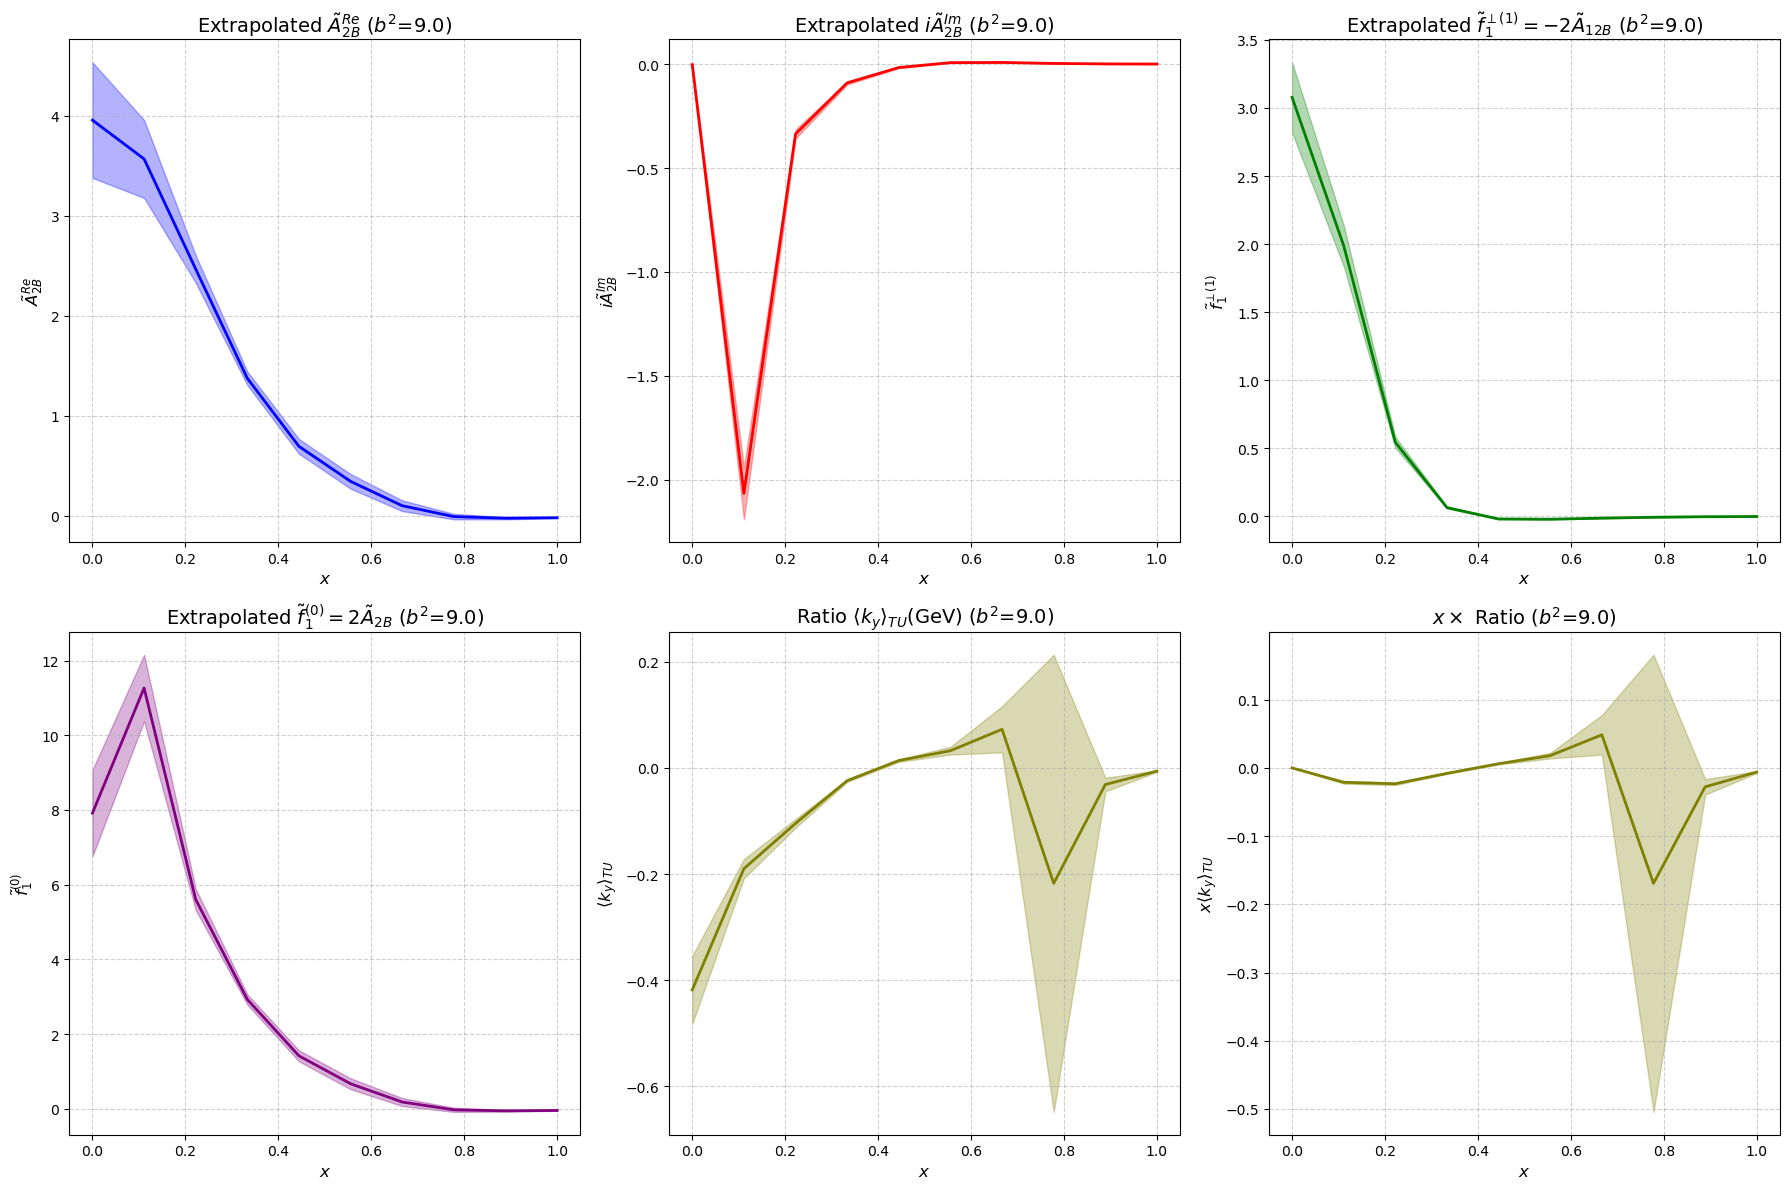

In [15]:
import h5py
import numpy as np
import math
import gvar as gv
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma

# ---------------------------------------------------------
# 1. Jackknife Statistics Helpers
# ---------------------------------------------------------
def calc_jk_stats(jk_array):
    """ Calculate mean and jackknife error of an array of samples. """
    N = len(jk_array)
    mean = np.mean(jk_array)
    err = np.sqrt(((N - 1) / N) * np.sum((jk_array - mean)**2))
    return mean, err

def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        # Load the jackknifed parameter samples
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            fitted_params[key] = param_group[key][:]
        # Load the chi-square per dof array
        chi2_dof_list = f["chi2_dof"][:]
    return fitted_params, chi2_dof_list

# ---------------------------------------------------------
# 2. Extrapolation Routine using LSQFIT
# ---------------------------------------------------------
def fit_1_over_PL_lsqfit(inv_PL_vals, y_jk_samples):
    """
    Fits y = c0 + c1 * (1/PL) separately for every jackknife sample.
    inv_PL_vals: 1D array of length N_PL
    y_jk_samples: 2D array of shape (N_PL, N_JK)
    """
    N_PL, N_JK = y_jk_samples.shape

    # 1. Evaluate Jackknife Mean and Covariance
    mean_y = np.mean(y_jk_samples, axis=1)
    cov_y = np.zeros((N_PL, N_PL))
    for i in range(N_PL):
        for j in range(N_PL):
            cov_y[i, j] = ((N_JK - 1) / N_JK) * np.sum(
                (y_jk_samples[i, :] - mean_y[i]) * (y_jk_samples[j, :] - mean_y[j])
            )

    # Create gvar for the central fit to get accurate chi2/dof
    try:
        y_gvar = gv.gvar(mean_y, cov_y)
    except Exception:
        # Fallback to diagonal errors if covariance matrix is numerically degenerate
        y_gvar = gv.gvar(mean_y, np.sqrt(np.diag(cov_y)))

    def fcn(x, p):
        return p['c0'] + p['c1'] * x**2

    # Loose prior so it behaves as an unconstrained standard fit
    prior = {'c0': gv.gvar(0, 1e5), 'c1': gv.gvar(0, 1e5)}

    # Fit the ensemble mean to extract chi2/dof
    fit_mean = lsqfit.nonlinear_fit(data=(inv_PL_vals, y_gvar), fcn=fcn, prior=prior)
    chi2_dof = fit_mean.chi2 / fit_mean.dof if fit_mean.dof > 0 else 0.0

    # 2. Fit every individual jackknife sample
    c0_jk = np.zeros(N_JK)
    c1_jk = np.zeros(N_JK)
    cov_y_eval = gv.evalcov(y_gvar)

    for k in range(N_JK):
        # We use the full ensemble covariance but shift the central values to the specific JK sample
        y_k_gvar = gv.gvar(y_jk_samples[:, k], cov_y_eval)
        fit_k = lsqfit.nonlinear_fit(data=(inv_PL_vals, y_k_gvar), fcn=fcn, prior=prior)
        c0_jk[k] = fit_k.pmean['c0']
        c1_jk[k] = fit_k.pmean['c1']

    # Calculate JK mean and error for fit parameters
    c0_mean, c0_err = calc_jk_stats(c0_jk)
    c1_mean, c1_err = calc_jk_stats(c1_jk)

    # Return the extrapolated sample array (c0_jk) to allow proper JK error propagation downstream
    return c0_jk, c0_mean, c0_err, c1_mean, c1_err, chi2_dof

# ---------------------------------------------------------
# 3. Main Logic
# ---------------------------------------------------------
def extrapolate_and_plot(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=10):
    
    x_vals = np.linspace(0, 1, num_points_x)
    MassN = 0.6228
    lata = 0.11403
    massterm = MassN * (197 * 0.001 / lata)
    
    # Calculate 1/PL and sort them
    inv_PL_vals = np.array([1.0 / pl for pl in PL_list])
    sort_idx = np.argsort(inv_PL_vals)
    inv_PL_vals = inv_PL_vals[sort_idx]
    sorted_PL_list = [PL_list[i] for i in sort_idx]
    N_PL = len(sorted_PL_list)

    print(f"\n[1] Loading HDF5 data and evaluating over x for fixed b^2 = {b2}...")
    
    # We need to discover N_JK from the first file
    init_filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{sorted_PL_list[0]}.h5"
    init_params, _ = load_params_from_h5(init_filename)
    N_JK = len(init_params['a_re'])

    # Pre-allocate evaluation arrays (N_PL, num_points_x, N_JK)
    re_all = np.zeros((N_PL, num_points_x, N_JK))
    im_all = np.zeros((N_PL, num_points_x, N_JK))
    reA12B_all = np.zeros((N_PL, num_points_x, N_JK))

    # Evaluate everything before fitting
    for i, pl in enumerate(tqdm(sorted_PL_list, desc="Evaluating PL sets")):
        filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{pl}.h5"
        fitted_params, _ = load_params_from_h5(filename)
        
        # Scaling parameters
        a_re, c_re, j_re, d_re = fitted_params['a_re'], fitted_params['c_re'] / (pl**2), fitted_params['j_re'], 1.0 + fitted_params['d_re'] * b2
        a_im, c_im, j_im, d_im = fitted_params['a_im'] / pl, fitted_params['c_im'] / (pl**2), fitted_params['j_im'], 1.0 + fitted_params['d_im'] * b2
        a_reA12B, c_reA12B, j_reA12B, d_reA12B = -fitted_params['a_reA12B'], fitted_params['c_reA12B'] / (pl**2), fitted_params['j_reA12B'], 1.0 + fitted_params['d_reA12B'] * b2

        for j, x in enumerate(x_vals):
            abs_x = max(np.abs(x), 1e-12)
            safe_x = x if x != 0 else 1e-12

            # ReA2B
            cd_R = c_re / d_re
            term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
            re_all[i, j, :] = term1_R * (abs_x**(-0.5 + j_re)) * kv(0.5 - j_re, abs_x / np.sqrt(cd_R))

            # ImA2B
            cd_I = c_im / d_im
            term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
            im_all[i, j, :] = term1_I * (safe_x * abs_x**(-1.5 + j_im)) * kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)

            # ReA12B
            cd_RA12B = c_reA12B / d_reA12B
            term1_RA12B = (2**(1 - j_reA12B) * a_reA12B * cd_RA12B**(-0.25 - j_reA12B/2) * d_reA12B**(-j_reA12B)) / gamma(j_reA12B)
            reA12B_all[i, j, :] = term1_RA12B * (abs_x**(-0.5 + j_reA12B)) * kv(0.5 - j_reA12B, abs_x / np.sqrt(cd_RA12B))

    # Pre-allocate Extrapolated Jackknife Arrays
    re_extrap_jk = np.zeros((num_points_x, N_JK))
    im_extrap_jk = np.zeros((num_points_x, N_JK))
    reA12B_extrap_jk = np.zeros((num_points_x, N_JK))

    print("\n[2] Performing 1/PL -> 0 Linear Extrapolation (Jackknife by Jackknife)...")
    print("------------------------------------------------------------------------------------------")
    print(f"{'Observable':<10} | {'x':<5} | {'c0 (1/PL=0 limit)':<20} | {'c1 (Slope)':<20} | {'chi2/dof':<8}")
    print("------------------------------------------------------------------------------------------")

    for j, x in enumerate(tqdm(x_vals, desc="Extrapolating slices")):
        # --- Fit ReA2B ---
        c0_jk_re, c0_m_re, c0_e_re, c1_m_re, c1_e_re, chi2_re = fit_1_over_PL_lsqfit(inv_PL_vals, re_all[:, j, :])
        re_extrap_jk[j, :] = c0_jk_re
        
        # --- Fit ImA2B ---
        c0_jk_im, c0_m_im, c0_e_im, c1_m_im, c1_e_im, chi2_im = fit_1_over_PL_lsqfit(inv_PL_vals, im_all[:, j, :])
        im_extrap_jk[j, :] = c0_jk_im

        # --- Fit ReA12B ---
        c0_jk_a12b, c0_m_a12b, c0_e_a12b, c1_m_a12b, c1_e_a12b, chi2_a12b = fit_1_over_PL_lsqfit(inv_PL_vals, reA12B_all[:, j, :])
        reA12B_extrap_jk[j, :] = c0_jk_a12b

        # Print subset of fits to terminal for verification
        if j % 20 == 0 or j == len(x_vals)-1:
            print(f"ReA2B      | {x:5.2f} | {c0_m_re:8.4f} +/- {c0_e_re:<8.4f} | {c1_m_re:8.4f} +/- {c1_e_re:<8.4f} | {chi2_re:.2f}")
            print(f"ImA2B      | {x:5.2f} | {c0_m_im:8.4f} +/- {c0_e_im:<8.4f} | {c1_m_im:8.4f} +/- {c1_e_im:<8.4f} | {chi2_im:.2f}")
            print(f"ReA12B     | {x:5.2f} | {c0_m_a12b:8.4f} +/- {c0_e_a12b:<8.4f} | {c1_m_a12b:8.4f} +/- {c1_e_a12b:<8.4f} | {chi2_a12b:.2f}")
            if j != len(x_vals)-1:
                print("- "*45)

    print("\n[3] Calculating Extrapolated Observables and Derived Quantities...")
    
    re_m, re_e = np.zeros(num_points_x), np.zeros(num_points_x)
    im_m, im_e = np.zeros(num_points_x), np.zeros(num_points_x)
    reA12B_m, reA12B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    full_m, full_e = np.zeros(num_points_x), np.zeros(num_points_x)
    siv_m, siv_e = np.zeros(num_points_x), np.zeros(num_points_x)
    xsiv_m, xsiv_e = np.zeros(num_points_x), np.zeros(num_points_x)

    for j, x in enumerate(x_vals):
        re_m[j], re_e[j] = calc_jk_stats(re_extrap_jk[j, :])
        im_m[j], im_e[j] = calc_jk_stats(im_extrap_jk[j, :])
        
        # Original definition includes a factor of -2 in A12B evaluation inside code
        reA12B_m[j], reA12B_e[j] = calc_jk_stats(-2 * reA12B_extrap_jk[j, :])

        # Full A2B
        full_jk = 2 * (re_extrap_jk[j, :] - im_extrap_jk[j, :])
        full_m[j], full_e[j] = calc_jk_stats(full_jk)

        # Ratio (Sivers)
        # Ratio based on user's exact prior implementation formulation
        siv_jk = (-massterm * (-2 * reA12B_extrap_jk[j, :])) / full_jk
        siv_m[j], siv_e[j] = calc_jk_stats(siv_jk)

        # x * Ratio
        xsiv_jk = x * siv_jk
        xsiv_m[j], xsiv_e[j] = calc_jk_stats(xsiv_jk)

    # ---------------------------------------------------------
    # 4. Final 2D Plotting
    # ---------------------------------------------------------
    print("[4] Generating plots...")
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    def plot_2d_band(ax, x, mean, err, color, title, ylabel):
        ax.plot(x, mean, color=color, linewidth=2)
        ax.fill_between(x, mean - err, mean + err, color=color, alpha=0.3)
        ax.set_title(title, fontsize=14)
        ax.set_xlabel('$x$', fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)

    plot_2d_band(axes[0], x_vals, re_m, re_e, 'blue', f'Extrapolated $\\tilde{{A}}_{{2B}}^{{Re}}$ ($b^2$={b2})', '$\\tilde{A}_{2B}^{Re}$')
    plot_2d_band(axes[1], x_vals, im_m, im_e, 'red', f'Extrapolated $i\\tilde{{A}}_{{2B}}^{{Im}}$ ($b^2$={b2})', '$i\\tilde{A}_{2B}^{Im}$')
    plot_2d_band(axes[2], x_vals, reA12B_m, reA12B_e, 'green', f'Extrapolated $\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$ ($b^2$={b2})', '$\\tilde{f}_{1}^{\\perp(1)}$')
    plot_2d_band(axes[3], x_vals, full_m, full_e, 'purple', f'Extrapolated $\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$ ($b^2$={b2})', '$\\tilde{f}_{1}^{(0)}$')

    # Apply x >= 0 mask for Sivers quantities
    mask = x_vals >= 0
    x_pos = x_vals[mask]
    
    plot_2d_band(axes[4], x_pos, siv_m[mask], siv_e[mask], 'olive', f'Ratio $\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ($b^2$={b2})', '$\\langle k_{y} \\rangle_{TU}$')
    plot_2d_band(axes[5], x_pos, xsiv_m[mask], xsiv_e[mask], 'olive', f'$x \\times$ Ratio ($b^2$={b2})', '$x\\langle k_{y} \\rangle_{TU}$')

    plt.tight_layout()
    file_name = f"Extrapolated_1_over_PL_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()

# ---------------------------------------------------------
# Example Execution Call
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-1, -2, -3, -4]

    extrapolate_and_plot(PL_list, bminfit, etamin, etamax, b2=9.0)


[1] Loading HDF5 data and evaluating over x for fixed b^2 = 9.0...


Evaluating PL sets:   0%|          | 0/4 [00:00<?, ?it/s]


[2] Performing 1/zeta^2 -> 0 Linear Extrapolation (Jackknife by Jackknife)...
---------------------------------------------------------------------------------------------
Observable | x     | c0 (1/zeta^2=0 limit)  | c1 (Slope)           | chi2/dof
---------------------------------------------------------------------------------------------


Extrapolating slices:   0%|          | 0/10 [00:00<?, ?it/s]

ReA2B      |  0.00 |    3.9177 +/- 0.5630   |  -2.3581 +/- 0.5986   | 2.14
ImA2B      |  0.00 |   -0.0030 +/- 0.0060   |  -0.0018 +/- 0.0075   | 1.03
ReA12B     |  0.00 |   -1.5061 +/- 0.1243   |   0.8858 +/- 0.1249   | 0.12
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
ReA2B      |  1.00 |   -0.0189 +/- 0.0042   |   0.3660 +/- 0.0192   | 0.85
ImA2B      |  1.00 |    0.0002 +/- 0.0000   |  -0.0038 +/- 0.0003   | 124.59
ReA12B     |  1.00 |    0.0001 +/- 0.0000   |  -0.0030 +/- 0.0004   | 152.90

[3] Calculating Extrapolated Observables and Derived Quantities...
[4] Generating plots...


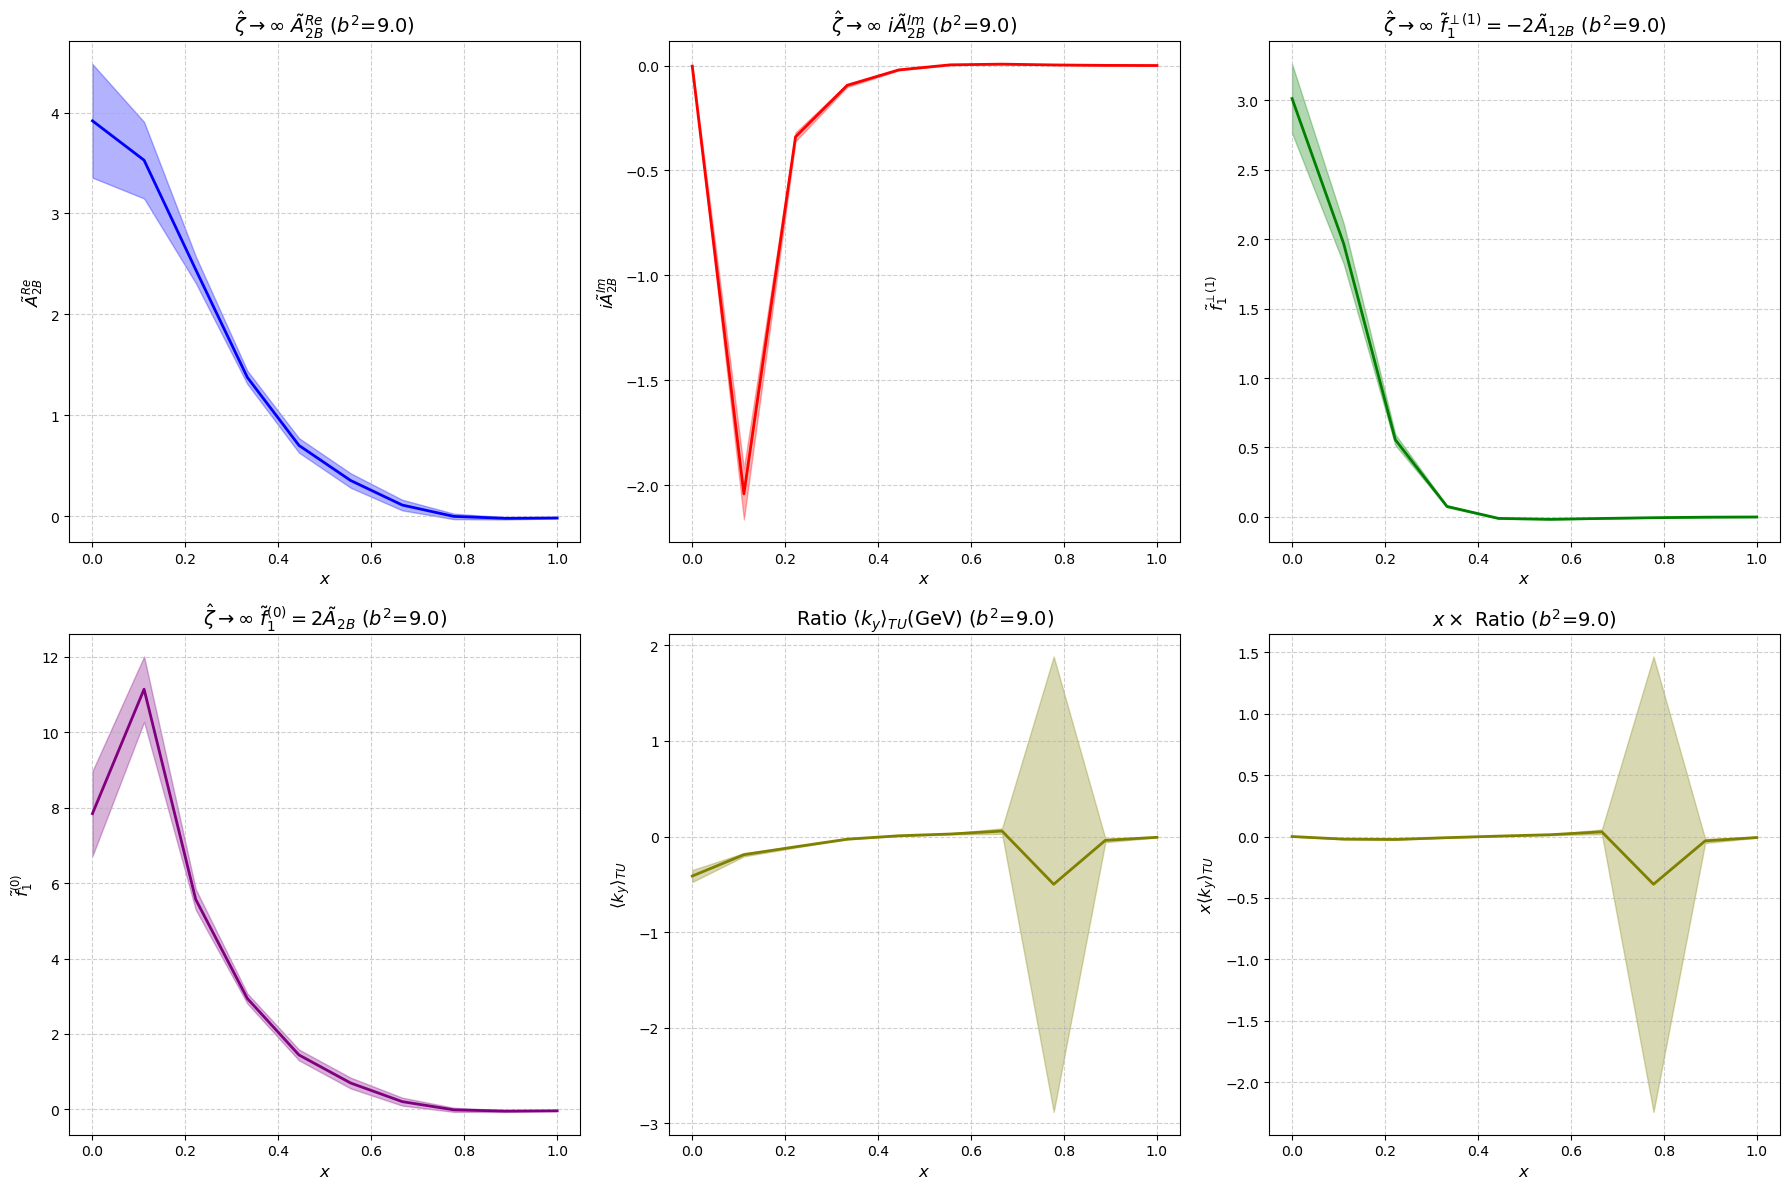

In [17]:
import h5py
import numpy as np
import math
import gvar as gv
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma

# ---------------------------------------------------------
# 1. Jackknife Statistics Helpers
# ---------------------------------------------------------
def calc_jk_stats(jk_array):
    """ Calculate mean and jackknife error of an array of samples. """
    N = len(jk_array)
    mean = np.mean(jk_array)
    err = np.sqrt(((N - 1) / N) * np.sum((jk_array - mean)**2))
    return mean, err

def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        # Load the jackknifed parameter samples
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            fitted_params[key] = param_group[key][:]
        # Load the chi-square per dof array
        chi2_dof_list = f["chi2_dof"][:]
    return fitted_params, chi2_dof_list

# ---------------------------------------------------------
# 2. Extrapolation Routine using LSQFIT
# ---------------------------------------------------------
def fit_1_over_zeta_sq_lsqfit(inv_zeta_sq_vals, y_jk_samples):
    """
    Fits y = c0 + c1 * (1/zeta^2) separately for every jackknife sample.
    inv_zeta_sq_vals: 1D array of length N_PL
    y_jk_samples: 2D array of shape (N_PL, N_JK)
    """
    N_PL, N_JK = y_jk_samples.shape

    # 1. Evaluate Jackknife Mean and Covariance
    mean_y = np.mean(y_jk_samples, axis=1)
    cov_y = np.zeros((N_PL, N_PL))
    for i in range(N_PL):
        for j in range(N_PL):
            cov_y[i, j] = ((N_JK - 1) / N_JK) * np.sum(
                (y_jk_samples[i, :] - mean_y[i]) * (y_jk_samples[j, :] - mean_y[j])
            )

    # Create gvar for the central fit to get accurate chi2/dof
    try:
        y_gvar = gv.gvar(mean_y, cov_y)
    except Exception:
        # Fallback to diagonal errors if covariance matrix is numerically degenerate
        y_gvar = gv.gvar(mean_y, np.sqrt(np.diag(cov_y)))

    # Linear fit in terms of the new variable (x here represents 1/zeta^2)
    def fcn(x, p):
        return p['c0'] + p['c1'] * x

    # Loose prior so it behaves as an unconstrained standard fit
    prior = {'c0': gv.gvar(0, 1e5), 'c1': gv.gvar(0, 1e5)}

    # Fit the ensemble mean to extract chi2/dof
    fit_mean = lsqfit.nonlinear_fit(data=(inv_zeta_sq_vals, y_gvar), fcn=fcn, prior=prior)
    chi2_dof = fit_mean.chi2 / fit_mean.dof if fit_mean.dof > 0 else 0.0

    # 2. Fit every individual jackknife sample
    c0_jk = np.zeros(N_JK)
    c1_jk = np.zeros(N_JK)
    cov_y_eval = gv.evalcov(y_gvar)

    for k in range(N_JK):
        # We use the full ensemble covariance but shift the central values to the specific JK sample
        y_k_gvar = gv.gvar(y_jk_samples[:, k], cov_y_eval)
        fit_k = lsqfit.nonlinear_fit(data=(inv_zeta_sq_vals, y_k_gvar), fcn=fcn, prior=prior)
        c0_jk[k] = fit_k.pmean['c0']
        c1_jk[k] = fit_k.pmean['c1']

    # Calculate JK mean and error for fit parameters
    c0_mean, c0_err = calc_jk_stats(c0_jk)
    c1_mean, c1_err = calc_jk_stats(c1_jk)

    # Return the extrapolated sample array (c0_jk) to allow proper JK error propagation downstream
    return c0_jk, c0_mean, c0_err, c1_mean, c1_err, chi2_dof

# ---------------------------------------------------------
# 3. Main Logic
# ---------------------------------------------------------
def extrapolate_and_plot(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=50):
    
    x_vals = np.linspace(0, 1, num_points_x)
    MassN = 0.6228
    lata = 0.11403
    massterm = MassN * (197 * 0.001 / lata)
    
    # ---------------------------------------------------------
    # NEW: Calculate 1/zeta^2 and sort them
    # Formula: 1/zeta^2 = (m_N / P_L)^4 + 2*(m_N / P_L)^2
    # ---------------------------------------------------------
    inv_zeta_sq_vals = np.array([ (MassN**4 / pl**4) + 2 * (MassN**2 / pl**2) for pl in PL_list ])
    
    # Sort arrays based on the new variable to keep everything aligned
    sort_idx = np.argsort(inv_zeta_sq_vals)
    inv_zeta_sq_vals = inv_zeta_sq_vals[sort_idx]
    sorted_PL_list = [PL_list[i] for i in sort_idx]
    N_PL = len(sorted_PL_list)

    print(f"\n[1] Loading HDF5 data and evaluating over x for fixed b^2 = {b2}...")
    
    # We need to discover N_JK from the first file
    init_filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{sorted_PL_list[0]}.h5"
    init_params, _ = load_params_from_h5(init_filename)
    N_JK = len(init_params['a_re'])

    # Pre-allocate evaluation arrays (N_PL, num_points_x, N_JK)
    re_all = np.zeros((N_PL, num_points_x, N_JK))
    im_all = np.zeros((N_PL, num_points_x, N_JK))
    reA12B_all = np.zeros((N_PL, num_points_x, N_JK))

    # Evaluate everything before fitting
    for i, pl in enumerate(tqdm(sorted_PL_list, desc="Evaluating PL sets")):
        filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{pl}.h5"
        fitted_params, _ = load_params_from_h5(filename)
        
        # Scaling parameters
        a_re, c_re, j_re, d_re = fitted_params['a_re'], fitted_params['c_re'] / (pl**2), fitted_params['j_re'], 1.0 + fitted_params['d_re'] * b2
        a_im, c_im, j_im, d_im = fitted_params['a_im'] / pl, fitted_params['c_im'] / (pl**2), fitted_params['j_im'], 1.0 + fitted_params['d_im'] * b2
        a_reA12B, c_reA12B, j_reA12B, d_reA12B = -fitted_params['a_reA12B'], fitted_params['c_reA12B'] / (pl**2), fitted_params['j_reA12B'], 1.0 + fitted_params['d_reA12B'] * b2

        for j, x in enumerate(x_vals):
            abs_x = max(np.abs(x), 1e-12)
            safe_x = x if x != 0 else 1e-12

            # ReA2B
            cd_R = c_re / d_re
            term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
            re_all[i, j, :] = term1_R * (abs_x**(-0.5 + j_re)) * kv(0.5 - j_re, abs_x / np.sqrt(cd_R))

            # ImA2B
            cd_I = c_im / d_im
            term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
            im_all[i, j, :] = term1_I * (safe_x * abs_x**(-1.5 + j_im)) * kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)

            # ReA12B
            cd_RA12B = c_reA12B / d_reA12B
            term1_RA12B = (2**(1 - j_reA12B) * a_reA12B * cd_RA12B**(-0.25 - j_reA12B/2) * d_reA12B**(-j_reA12B)) / gamma(j_reA12B)
            reA12B_all[i, j, :] = term1_RA12B * (abs_x**(-0.5 + j_reA12B)) * kv(0.5 - j_reA12B, abs_x / np.sqrt(cd_RA12B))

    # Pre-allocate Extrapolated Jackknife Arrays
    re_extrap_jk = np.zeros((num_points_x, N_JK))
    im_extrap_jk = np.zeros((num_points_x, N_JK))
    reA12B_extrap_jk = np.zeros((num_points_x, N_JK))

    print("\n[2] Performing 1/zeta^2 -> 0 Linear Extrapolation (Jackknife by Jackknife)...")
    print("---------------------------------------------------------------------------------------------")
    print(f"{'Observable':<10} | {'x':<5} | {'c0 (1/zeta^2=0 limit)':<22} | {'c1 (Slope)':<20} | {'chi2/dof':<8}")
    print("---------------------------------------------------------------------------------------------")

    for j, x in enumerate(tqdm(x_vals, desc="Extrapolating slices")):
        # --- Fit ReA2B ---
        c0_jk_re, c0_m_re, c0_e_re, c1_m_re, c1_e_re, chi2_re = fit_1_over_zeta_sq_lsqfit(inv_zeta_sq_vals, re_all[:, j, :])
        re_extrap_jk[j, :] = c0_jk_re
        
        # --- Fit ImA2B ---
        c0_jk_im, c0_m_im, c0_e_im, c1_m_im, c1_e_im, chi2_im = fit_1_over_zeta_sq_lsqfit(inv_zeta_sq_vals, im_all[:, j, :])
        im_extrap_jk[j, :] = c0_jk_im

        # --- Fit ReA12B ---
        c0_jk_a12b, c0_m_a12b, c0_e_a12b, c1_m_a12b, c1_e_a12b, chi2_a12b = fit_1_over_zeta_sq_lsqfit(inv_zeta_sq_vals, reA12B_all[:, j, :])
        reA12B_extrap_jk[j, :] = c0_jk_a12b

        # Print subset of fits to terminal for verification
        if j % 10 == 0 or j == len(x_vals)-1:
            print(f"ReA2B      | {x:5.2f} |  {c0_m_re:8.4f} +/- {c0_e_re:<8.4f} | {c1_m_re:8.4f} +/- {c1_e_re:<8.4f} | {chi2_re:.2f}")
            print(f"ImA2B      | {x:5.2f} |  {c0_m_im:8.4f} +/- {c0_e_im:<8.4f} | {c1_m_im:8.4f} +/- {c1_e_im:<8.4f} | {chi2_im:.2f}")
            print(f"ReA12B     | {x:5.2f} |  {c0_m_a12b:8.4f} +/- {c0_e_a12b:<8.4f} | {c1_m_a12b:8.4f} +/- {c1_e_a12b:<8.4f} | {chi2_a12b:.2f}")
            if j != len(x_vals)-1:
                print("- "*46)

    print("\n[3] Calculating Extrapolated Observables and Derived Quantities...")
    
    re_m, re_e = np.zeros(num_points_x), np.zeros(num_points_x)
    im_m, im_e = np.zeros(num_points_x), np.zeros(num_points_x)
    reA12B_m, reA12B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    full_m, full_e = np.zeros(num_points_x), np.zeros(num_points_x)
    siv_m, siv_e = np.zeros(num_points_x), np.zeros(num_points_x)
    xsiv_m, xsiv_e = np.zeros(num_points_x), np.zeros(num_points_x)

    for j, x in enumerate(x_vals):
        re_m[j], re_e[j] = calc_jk_stats(re_extrap_jk[j, :])
        im_m[j], im_e[j] = calc_jk_stats(im_extrap_jk[j, :])
        
        # Original definition includes a factor of -2 in A12B evaluation inside code
        reA12B_m[j], reA12B_e[j] = calc_jk_stats(-2 * reA12B_extrap_jk[j, :])

        # Full A2B
        full_jk = 2 * (re_extrap_jk[j, :] - im_extrap_jk[j, :])
        full_m[j], full_e[j] = calc_jk_stats(full_jk)

        # Ratio (Sivers)
        # Ratio based on user's exact prior implementation formulation
        siv_jk = (-massterm * (-2 * reA12B_extrap_jk[j, :])) / full_jk
        siv_m[j], siv_e[j] = calc_jk_stats(siv_jk)

        # x * Ratio
        xsiv_jk = x * siv_jk
        xsiv_m[j], xsiv_e[j] = calc_jk_stats(xsiv_jk)

    # ---------------------------------------------------------
    # 4. Final 2D Plotting
    # ---------------------------------------------------------
    print("[4] Generating plots...")
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    def plot_2d_band(ax, x, mean, err, color, title, ylabel):
        ax.plot(x, mean, color=color, linewidth=2)
        ax.fill_between(x, mean - err, mean + err, color=color, alpha=0.3)
        ax.set_title(title, fontsize=14)
        ax.set_xlabel('$x$', fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)

    plot_2d_band(axes[0], x_vals, re_m, re_e, 'blue', f'$\\hat{{\\zeta}} \\to \\infty$ $\\tilde{{A}}_{{2B}}^{{Re}}$ ($b^2$={b2})', '$\\tilde{A}_{2B}^{Re}$')
    plot_2d_band(axes[1], x_vals, im_m, im_e, 'red', f'$\\hat{{\\zeta}} \\to \\infty$ $i\\tilde{{A}}_{{2B}}^{{Im}}$ ($b^2$={b2})', '$i\\tilde{A}_{2B}^{Im}$')
    plot_2d_band(axes[2], x_vals, reA12B_m, reA12B_e, 'green', f'$\\hat{{\\zeta}} \\to \\infty$ $\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$ ($b^2$={b2})', '$\\tilde{f}_{1}^{\\perp(1)}$')
    plot_2d_band(axes[3], x_vals, full_m, full_e, 'purple', f'$\\hat{{\\zeta}} \\to \\infty$ $\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$ ($b^2$={b2})', '$\\tilde{f}_{1}^{(0)}$')

    plot_2d_band(axes[4], x_vals, siv_m, siv_e, 'olive', f'Ratio $\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ($b^2$={b2})', '$\\langle k_{y} \\rangle_{TU}$')
    plot_2d_band(axes[5], x_vals, xsiv_m, xsiv_e, 'olive', f'$x \\times$ Ratio ($b^2$={b2})', '$x\\langle k_{y} \\rangle_{TU}$')

    plt.tight_layout()
    file_name = f"Extrapolated_zeta_limit_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()

# ---------------------------------------------------------
# Example Execution Call
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-1, -2, -3, -4]

    extrapolate_and_plot(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=10)